
# Taller: Árboles de Decisión (Clasificación y Regresión) + Optimización de Hiperparámetros
Objetivo: entender la formulación matemática de los árboles de decisión, cómo los hiperparámetros afectan el modelo, y practicar la optimización con GridSearchCV, RandomizedSearchCV y búsqueda bayesiana (Optuna).
Datasets:
- Clasificación principal: load_digits (similar a MNIST pero 8×8, rápido para clase).
- Regresión principal: load_diabetes.
- Ejercicio final: load_breast_cancer (clasificación) o load_diabetes (regresión).
Estructura:
1. Fundamentos matemáticos (impureza, ganancia, división, poda).
2. Árboles para clasificación (criterios Gini/Entropía/Log Loss).
3. Árboles para regresión (MSE/MAE).
4. Hiperparámetros y su efecto.
5. Validación cruzada: tipos y usos.
6. Optimización de hiperparámetros: Grid, Random, Bayesiana (Optuna).
7. Visualización y evaluación.
8. Ejercicio final guiado.



# Formulación Matemática del Árbol de Decisión
##

Un árbol de decisión divide el espacio de características con umbrales (por ejemplo, `alcohol ≤ 12.8`)
para crear reglas if-then. En cada nodo interno decide qué variable y qué umbral usar para que las hojas
resultantes estén lo más "puras" posible (clasificación) o tengan baja variabilidad (regresión).

---

## 1) Impureza en Clasificación

Sea un nodo $t$ con $K$ clases y proporciones $p_k(t)$ (donde $\sum_k p_k(t)=1$).

### a) Índice de Gini

$$G(t) = \sum_{k=1}^{K} p_k(t) \left[1-p_k(t)\right] = 1 - \sum_{k=1}^{K} p_k(t)^2$$

**Intuición:** Mide la probabilidad de error si etiquetamos al azar según la distribución del nodo.
Cuanto más concentrada esté una clase (por ejemplo, $p=\{1,0,0\}$), más pequeño es $G(t)$ (idealmente 0).

**Mini-ejemplo (3 clases):** Si $p=\{0.7, 0.2, 0.1\}$:
$$G = 1 - (0.7^2 + 0.2^2 + 0.1^2) = 1 - (0.49 + 0.04 + 0.01) = 0.46$$

---

### b) Entropía

$$H(t) = -\sum_{k=1}^{K} p_k(t) \log p_k(t)$$

*donde el log puede ser base 2 o $e$. La base sólo cambia la escala, no la decisión.*

**Intuición:** Mide la incertidumbre. Es 0 cuando el nodo es puro (toda la masa en una clase)
y máximo cuando todas las clases son equiprobables. Penaliza más las distribuciones "casi uniformes".

**Mini-ejemplo:** Con $p=\{0.7, 0.2, 0.1\}$ y $\log_2$:
$$H = -(0.7\log_2 0.7 + 0.2\log_2 0.2 + 0.1\log_2 0.1) \approx 1.156 \text{ bits}$$

---

### c) Log Loss (`'log_loss'` en scikit-learn)

Es la pérdida logística promedio en el nodo. Para nodos muy puros se acerca a 0 y, al igual que
la entropía, penaliza con fuerza las predicciones demasiado confiadas cuando están erradas.

---

## ¿Cuál usar?

- **Gini:** rápido y robusto; muy usado por defecto.
- **Entropía:** similar, pero a veces produce umbrales ligeramente distintos; puede distinguir mejor clases raras.
- **Log Loss:** coherente con modelos probabilísticos; útil si nos importa mucho la calibración de probabilidades.

💡 **Regla práctica:** Las diferencias reales entre Gini y Entropía suelen ser pequeñas;
prueba ambos si tienes clases desbalanceadas o muchas clases.

---

## 2) Impureza en Regresión

### a) Error Cuadrático Medio (MSE)

$$\text{MSE}(t) = \frac{1}{|t|} \sum_{i \in t} (y_i - \bar{y}_t)^2$$

**Intuición:** Mide la varianza de los valores en el nodo alrededor de su media. Un nodo puro
tiene MSE ≈ 0 (todos los $y_i$ son iguales).

**Mini-ejemplo:** Si $y = \{2, 3, 4\}$ en el nodo, $\bar{y} = 3$:
$$\text{MSE} = \frac{1}{3}[(2-3)^2 + (3-3)^2 + (4-3)^2] = \frac{2}{3} \approx 0.67$$

### b) Error Absoluto Medio (MAE)

$$\text{MAE}(t) = \frac{1}{|t|} \sum_{i \in t} |y_i - \text{mediana}_t|$$

**Intuición:** Mide el error promedio en valor absoluto respecto a la mediana. Es más robusto
a outliers que MSE.

---

## 3) Criterio de División

Para una división $t \to \{t_L, t_R\}$ (izquierda y derecha):

$$\Delta I = I(t) - \frac{|t_L|}{|t|} I(t_L) - \frac{|t_R|}{|t|} I(t_R)$$

Se escoge la variable y umbral que **maximiza** $\Delta I$ (la reducción de impureza).

**Intuición:** Queremos la mayor ganancia de información posible. Un buen split divide
el nodo en dos subnodos más puros que el original.

---

## 4) Función Objetivo Global (CART con Poda por Complejidad)

$$\text{Coste}_\alpha(T) = \sum_{t \in \text{hojas}(T)} I(t) + \alpha \cdot |\text{hojas}(T)|$$

donde $\alpha \geq 0$.

- Mayor $\alpha$ ⇒ árboles más simples (poda de coste-complejidad, parámetro `ccp_alpha` en scikit-learn).
- $\alpha = 0$ ⇒ árbol sin poda (puede sobreajustar).

---

## 5) Predicción en Hoja

- **Clasificación:** clase mayoritaria (o probabilidades por frecuencia de clases en la hoja).
- **Regresión:** media (si usamos MSE) o mediana (si usamos MAE) de los valores en la hoja.


"""
# 2) Hiperparámetros Clave y su Efecto
##

Piensa en un árbol como un juego de "20 preguntas" que parte el espacio con umbrales.
Estos "perillas" controlan cuánto y cómo parte.

---

## `max_depth` (Profundidad Máxima)

**Qué hace:** Controla cuántos niveles puede crecer el árbol (cuántas preguntas en cadena).


**Si es muy alto:** El árbol memoriza casos raros ⇒ sobreajuste (varianza alta).


**Si es muy bajo:** El árbol es muy general ⇒ subajuste (sesgo alto).


**Úsalo para:** Limitar complejidad de forma directa.

**Regla práctica:** Empieza con 5–12 (datasets medianos).

**Mini-ejemplo (clasificación Wine):** Con `max_depth=3`, el árbol hace como máximo 3 preguntas
anidadas ("¿alcohol > 12.8? → ¿ácido < 2.5? → ¿sulfatos > 0.8?"). Con `max_depth=20`, puede hacer
muchas más preguntas, creando hojas especializadas que solo aciertan en el conjunto de entrenamiento.

---

## `min_samples_split` (Muestras Mínimas para Intentar Dividir)

**Qué hace:** Impide que el árbol se divida si el nodo es muy pequeño.

**Si lo subes:** Evitas divisiones "por ruido" ⇒ menos varianza, más sesgo.

**Síntoma de que falta subir:** Hojas con poquitas muestras y rendimiento de test inestable.

**Valores típicos:** 2, 5, 10, 20.

**Mini-ejemplo:** Con `min_samples_split=2`, si llegas a un nodo con 3 ejemplos, el árbol intenta
dividirlo (si encuentra un buen umbral). Con `min_samples_split=10`, ese nodo de 3 ejemplos se
convierte en hoja directamente, sin intentar más divisiones.

---

## `min_samples_leaf` (Muestras Mínimas por Hoja)

**Qué hace:** Obliga a que cada hoja tenga al menos n ejemplos.

**Efecto:** Suaviza reglas y mejora probabilidades (menos hojas "1-ejemplo = 100%").

**Cuándo subirlo:** Datos ruidosos, probabilidades mal calibradas, clases desbalanceadas.

**Valores típicos:** 1–10 (según tamaño del dataset).

**Mini-ejemplo:** Con `min_samples_leaf=1`, una hoja puede tener 1 solo ejemplo (el árbol asigna
probabilidad 1.0 a esa clase). Con `min_samples_leaf=5`, todas las hojas tienen mínimo 5 ejemplos,
por lo que las probabilidades son más estables (ej. "2 de 5 = 40%", no "1 de 1 = 100%").

---

## `max_leaf_nodes` (Máximo Número de Hojas)

**Qué hace:** Pone un tope al número total de reglas finales.

**Efecto:** Controla la complejidad global (similar a `max_depth`, pero por hojas).

**Úsalo cuando:** Quieres un modelo compacto y fácil de explicar.

**Mini-ejemplo:** Con `max_leaf_nodes=10`, el árbol puede tener como máximo 10 hojas (10 reglas
finales). Es más restrictivo que `max_depth` en términos de interpretabilidad.

---

## `max_features` (Número de Variables por Split)

**Qué hace:** En cada nodo, solo mira un subconjunto de variables para buscar el mejor umbral.

**Efecto:** Introduce aleatoriedad útil para bajar varianza (muy usado en Random Forest).

**Cuándo cambiarlo:** Si tienes muchas variables o ves que el árbol usa siempre las mismas.

**Valores comunes:** `None` (todas), `"sqrt"` (raíz de p), `"log2"`, o un entero.

**Mini-ejemplo:** Con 10 variables y `max_features="sqrt"`, cada nodo solo considera
√10 ≈ 3 variables al azar. Esto fuerza al árbol a explorar diferentes características en lugar
de depender siempre de las "top 3" más obvias.

---

## `criterion` (Función de Impureza/Pérdida)

### Clasificación: `"gini"`, `"entropy"`, `"log_loss"`

**Gini:** Rápido y robusto (buena default).

**Entropía / Log Loss:** Similar, a veces mejor con clases raras; probabilidades más "informativas".

### Regresión: `"squared_error"` (MSE), `"absolute_error"` (MAE)

**MSE:** Sensible a outliers; aprende medias.

**MAE:** Robusto a outliers; aprende medianas.

**Mini-ejemplo:** En regresión de precios con algunos outliers, MSE se ve "arrastrado" a que
el árbol intente predecir mejor esos casos extremos (sobreajuste). MAE los trata como casos
más, sin penalización adicional.

---

## `ccp_alpha` (Poda por Coste-Complejidad)

**Qué hace:** Añade una penalización por número de hojas: $\text{Coste} = \text{Impureza} + \alpha \cdot \#\text{hojas}$.

**Efecto:** Valores más altos ⇒ árbol más pequeño (más sesgo, menos varianza).

**Cómo usarlo bien:** Explorar con `cost_complexity_pruning_path` + validación cruzada.

**Mini-ejemplo:** Con `ccp_alpha=0`, el árbol crece sin límite (máxima complejidad).
Con `ccp_alpha=0.05`, cada hoja adicional "cuesta" 0.05 en la función objetivo,
por lo que el árbol se "poda" automáticamente a una complejidad más razonable.

---

## `splitter` (`"best"` vs `"random"`)

**Qué hace:** `"best"` explora todos los umbrales posibles; `"random"` prueba algunos al azar.

**Efecto:** `"random"` puede bajar varianza y acelerar entrenamiento, a costa de algo de rendimiento medio.

**Útil en:** Datasets grandes con muchas variables/umbrales.

**Mini-ejemplo:** Con 1000 muestras y 50 variables, `splitter="best"` puede ser lento.
Con `splitter="random"`, el árbol prueba solo 10–20 umbrales por variable y nodo,
lo que es mucho más rápido y a veces produce árboles incluso mejores (menos sobreajuste).

---

## Tabla de Síntomas y Ajustes

| Síntoma | Qué tocar | Movimiento típico | Por qué |
|---------|-----------|-------------------|---------|
| Train muy alto, Test bajo (sobreajuste) | `max_depth`, `min_samples_leaf`, `min_samples_split`, `ccp_alpha` | Bajar `max_depth`; subir `min_*`; subir `ccp_alpha` | Menos complejidad ⇒ baja varianza |
| Train y Test bajos (subajuste) | `max_depth`, `max_leaf_nodes`, `criterion` | Subir `max_depth` / `max_leaf_nodes`; probar otro `criterion` | Más capacidad o pérdida más adecuada |
| Probabilidades "extremas" en hojas | `min_samples_leaf`, `ccp_alpha` | Subir `min_samples_leaf` o `ccp_alpha` | Suaviza y estabiliza hojas |
| Muchas features, mismas se repiten | `max_features` | Bajar `max_features` (ej. `"sqrt"`) | Fuerza a explorar otras variables |
| Outliers en regresión | `criterion` | Usar `"absolute_error"` | Menos sensibilidad a valores extremos |

"""

In [1]:
#3) Configuración base (importaciones y utilidades)


import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import load_digits, load_diabetes, load_wine
from sklearn.model_selection import (train_test_split, StratifiedKFold,
                                     GridSearchCV, RandomizedSearchCV, cross_val_score)
from sklearn.tree import DecisionTreeClassifier, DecisionTreeRegressor, plot_tree
from sklearn.metrics import (accuracy_score, f1_score, ConfusionMatrixDisplay,
                            mean_squared_error, mean_absolute_error, r2_score)
from scipy.stats import randint, uniform

import warnings
warnings.filterwarnings("ignore", category=UserWarning)

SECCIÓN 1: FUNDAMENTOS MATEMÁTICOS

📚 ¿CÓMO FUNCIONA UN ÁRBOL DE DECISIÓN?

Imagina que tienes que clasificar frutas. Un árbol pregunta:

    ┌─ ¿Es roja? ──┐
    Sí            No
    │              │
    ¿Es grande?    ¿Es alargada?
    │              │
  Manzana      ¿Plátano o Limón?

Matemáticamente, el árbol:
1. En cada NODO decide: ¿qué pregunta hacer? (ej: "¿peso > 150g?")
2. Elige la pregunta que mejor SEPARE las clases
3. Repite hasta que los grupos sean "puros" (o se cumpla un criterio de parada)

🎯 CRITERIOS DE IMPUREZA (¿qué tan "mezclado" está un nodo?)

Para CLASIFICACIÓN:
──────────────────

1️⃣ ÍNDICE DE GINI
   Fórmula: G(t) = 1 - Σ p_k²
   Donde p_k = proporción de la clase k en el nodo

   📊 Ejemplo 1 - Nodo PURO [100% clase A, 0% clase B, 0% clase C]
      G = 1 - (1.0² + 0² + 0²) = 0.000
      → Impureza = 0 (perfecto, todas son clase A)

   📊 Ejemplo 2 - Nodo IMPURO [70% clase A, 20% clase B, 10% clase C]
      G = 1 - (0.7² + 0.2² + 0.1²) = 0.460
      → Mayor im

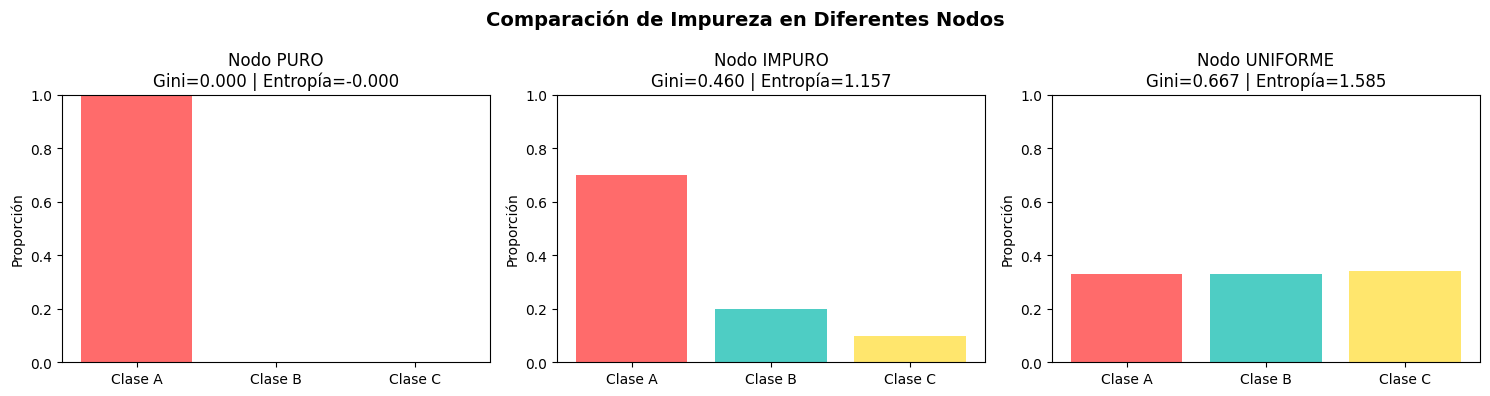



💡 ¿CUÁL USAR?
   • GINI: Más rápido, bueno por defecto
   • ENTROPÍA: Similar, puede distinguir mejor clases raras
   • En la práctica: las diferencias son pequeñas

────────────────────────────────────────────────────────────────────────────────

Para REGRESIÓN:
──────────────

3️⃣ MSE (Mean Squared Error)
   Fórmula: MSE = (1/n) Σ(y_i - ȳ)²
   Mide la varianza alrededor de la media

   📊 Ejemplo: valores en nodo = [ 2  3  4 10]
      Media = 4.75
      MSE = 9.69
      → Sensible a outliers (el 10 afecta mucho)

4️⃣ MAE (Mean Absolute Error)
   Fórmula: MAE = (1/n) Σ|y_i - mediana|
   Más robusto a outliers

   📊 Mismo ejemplo con MAE:
      Mediana = 3.50
      MAE = 2.25
      → Menos afectado por el outlier


In [2]:
# ============================================================================
# SECCIÓN 1: FUNDAMENTOS MATEMÁTICOS DE ÁRBOLES DE DECISIÓN
# ============================================================================
print("="*80)
print("SECCIÓN 1: FUNDAMENTOS MATEMÁTICOS")
print("="*80)

print("""
📚 ¿CÓMO FUNCIONA UN ÁRBOL DE DECISIÓN?

Imagina que tienes que clasificar frutas. Un árbol pregunta:

    ┌─ ¿Es roja? ──┐
    Sí            No
    │              │
    ¿Es grande?    ¿Es alargada?
    │              │
  Manzana      ¿Plátano o Limón?

Matemáticamente, el árbol:
1. En cada NODO decide: ¿qué pregunta hacer? (ej: "¿peso > 150g?")
2. Elige la pregunta que mejor SEPARE las clases
3. Repite hasta que los grupos sean "puros" (o se cumpla un criterio de parada)

🎯 CRITERIOS DE IMPUREZA (¿qué tan "mezclado" está un nodo?)

Para CLASIFICACIÓN:
──────────────────
""")

# Ejemplo práctico de Gini
print("1️⃣ ÍNDICE DE GINI")
print("   Fórmula: G(t) = 1 - Σ p_k²")
print("   Donde p_k = proporción de la clase k en el nodo\n")

# Caso 1: Nodo puro
p_pure = np.array([1.0, 0.0, 0.0])
gini_pure = 1 - np.sum(p_pure**2)
print(f"   📊 Ejemplo 1 - Nodo PURO [100% clase A, 0% clase B, 0% clase C]")
print(f"      G = 1 - (1.0² + 0² + 0²) = {gini_pure:.3f}")
print(f"      → Impureza = 0 (perfecto, todas son clase A)")

# Caso 2: Nodo impuro
p_mixed = np.array([0.7, 0.2, 0.1])
gini_mixed = 1 - np.sum(p_mixed**2)
print(f"\n   📊 Ejemplo 2 - Nodo IMPURO [70% clase A, 20% clase B, 10% clase C]")
print(f"      G = 1 - (0.7² + 0.2² + 0.1²) = {gini_mixed:.3f}")
print(f"      → Mayor impureza (las clases están mezcladas)")

# Caso 3: Máxima impureza
p_uniform = np.array([0.33, 0.33, 0.34])
gini_uniform = 1 - np.sum(p_uniform**2)
print(f"\n   📊 Ejemplo 3 - Nodo MÁXIMAMENTE IMPURO [33%, 33%, 34%]")
print(f"      G = 1 - (0.33² + 0.33² + 0.34²) = {gini_uniform:.3f}")
print(f"      → Máxima confusión (distribución casi uniforme)")

print("\n\n2️⃣ ENTROPÍA")
print("   Fórmula: H(t) = -Σ p_k log₂(p_k)")
print("   Mide la 'sorpresa' o incertidumbre\n")

# Cálculo de entropía
def entropy(p):
    p_filtered = p[p > 0]  # Evitar log(0)
    return -np.sum(p_filtered * np.log2(p_filtered))

entropy_pure = entropy(p_pure)
entropy_mixed = entropy(p_mixed)
entropy_uniform = entropy(p_uniform)

print(f"   📊 Nodo PURO: H = {entropy_pure:.3f} bits")
print(f"   📊 Nodo IMPURO: H = {entropy_mixed:.3f} bits")
print(f"   📊 Nodo UNIFORME: H = {entropy_uniform:.3f} bits")
print(f"   → A mayor entropía, mayor incertidumbre")

# Visualización comparativa
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
scenarios = [
    ("Nodo PURO", p_pure, gini_pure, entropy_pure),
    ("Nodo IMPURO", p_mixed, gini_mixed, entropy_mixed),
    ("Nodo UNIFORME", p_uniform, gini_uniform, entropy_uniform)
]

for ax, (title, probs, g, h) in zip(axes, scenarios):
    ax.bar(['Clase A', 'Clase B', 'Clase C'], probs, color=['#FF6B6B', '#4ECDC4', '#FFE66D'])
    ax.set_ylim(0, 1)
    ax.set_title(f"{title}\nGini={g:.3f} | Entropía={h:.3f}")
    ax.set_ylabel('Proporción')

plt.suptitle("Comparación de Impureza en Diferentes Nodos", fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

print("\n\n💡 ¿CUÁL USAR?")
print("   • GINI: Más rápido, bueno por defecto")
print("   • ENTROPÍA: Similar, puede distinguir mejor clases raras")
print("   • En la práctica: las diferencias son pequeñas\n")

# Para regresión
print("─"*80)
print("\nPara REGRESIÓN:")
print("──────────────")
print("\n3️⃣ MSE (Mean Squared Error)")
print("   Fórmula: MSE = (1/n) Σ(y_i - ȳ)²")
print("   Mide la varianza alrededor de la media\n")

y_values = np.array([2, 3, 4, 10])
y_mean = y_values.mean()
mse = np.mean((y_values - y_mean)**2)

print(f"   📊 Ejemplo: valores en nodo = {y_values}")
print(f"      Media = {y_mean:.2f}")
print(f"      MSE = {mse:.2f}")
print(f"      → Sensible a outliers (el 10 afecta mucho)")

print("\n4️⃣ MAE (Mean Absolute Error)")
print("   Fórmula: MAE = (1/n) Σ|y_i - mediana|")
print("   Más robusto a outliers\n")

y_median = np.median(y_values)
mae = np.mean(np.abs(y_values - y_median))
print(f"   📊 Mismo ejemplo con MAE:")
print(f"      Mediana = {y_median:.2f}")
print(f"      MAE = {mae:.2f}")
print(f"      → Menos afectado por el outlier")

#clasificación



SECCIÓN 2: CLASIFICACIÓN - Reconocimiento de Dígitos (8x8)

📊 Dataset DIGITS:
   • 1797 imágenes de dígitos (0-9)
   • 64 características (píxeles 8x8)
   • 10 clases


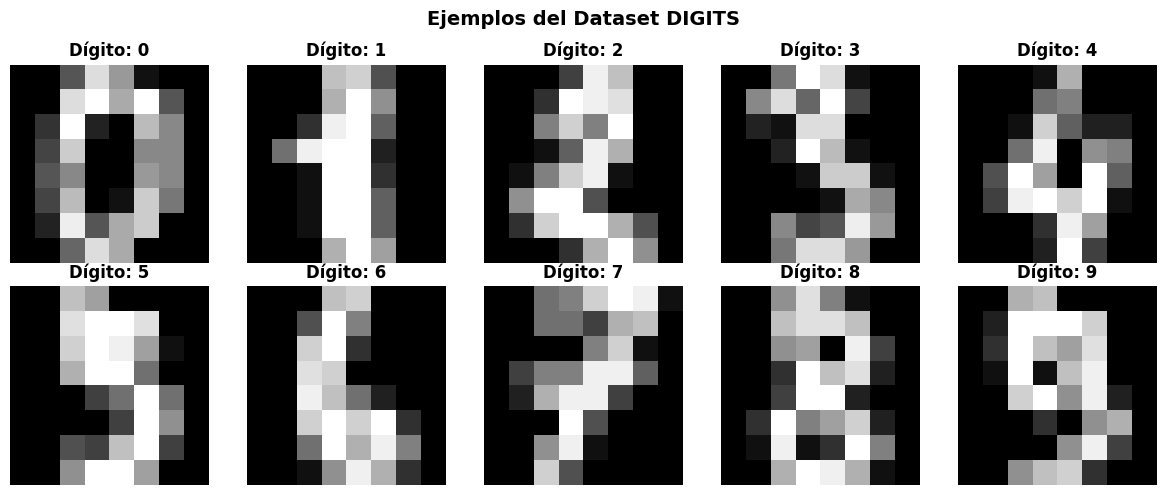


🔀 División estratificada 75/25:
   💡 Mantiene la proporción de cada clase en train y test
   ✓ Train: 1347 muestras
   ✓ Test: 450 muestras

🌳 Entrenando Árbol Base (max_depth=10)...

   📊 RESULTADOS INICIALES:
   • Accuracy: 0.8356 (83.6% de aciertos)
   • F1-macro: 0.8356
   • Hojas: 116
   • Profundidad: 10



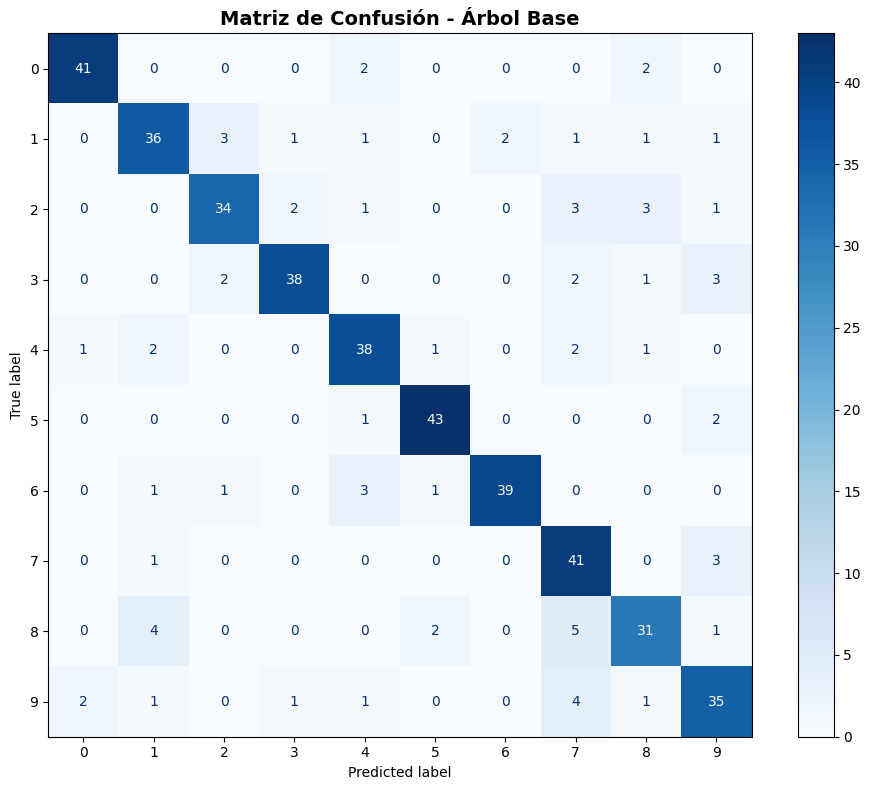

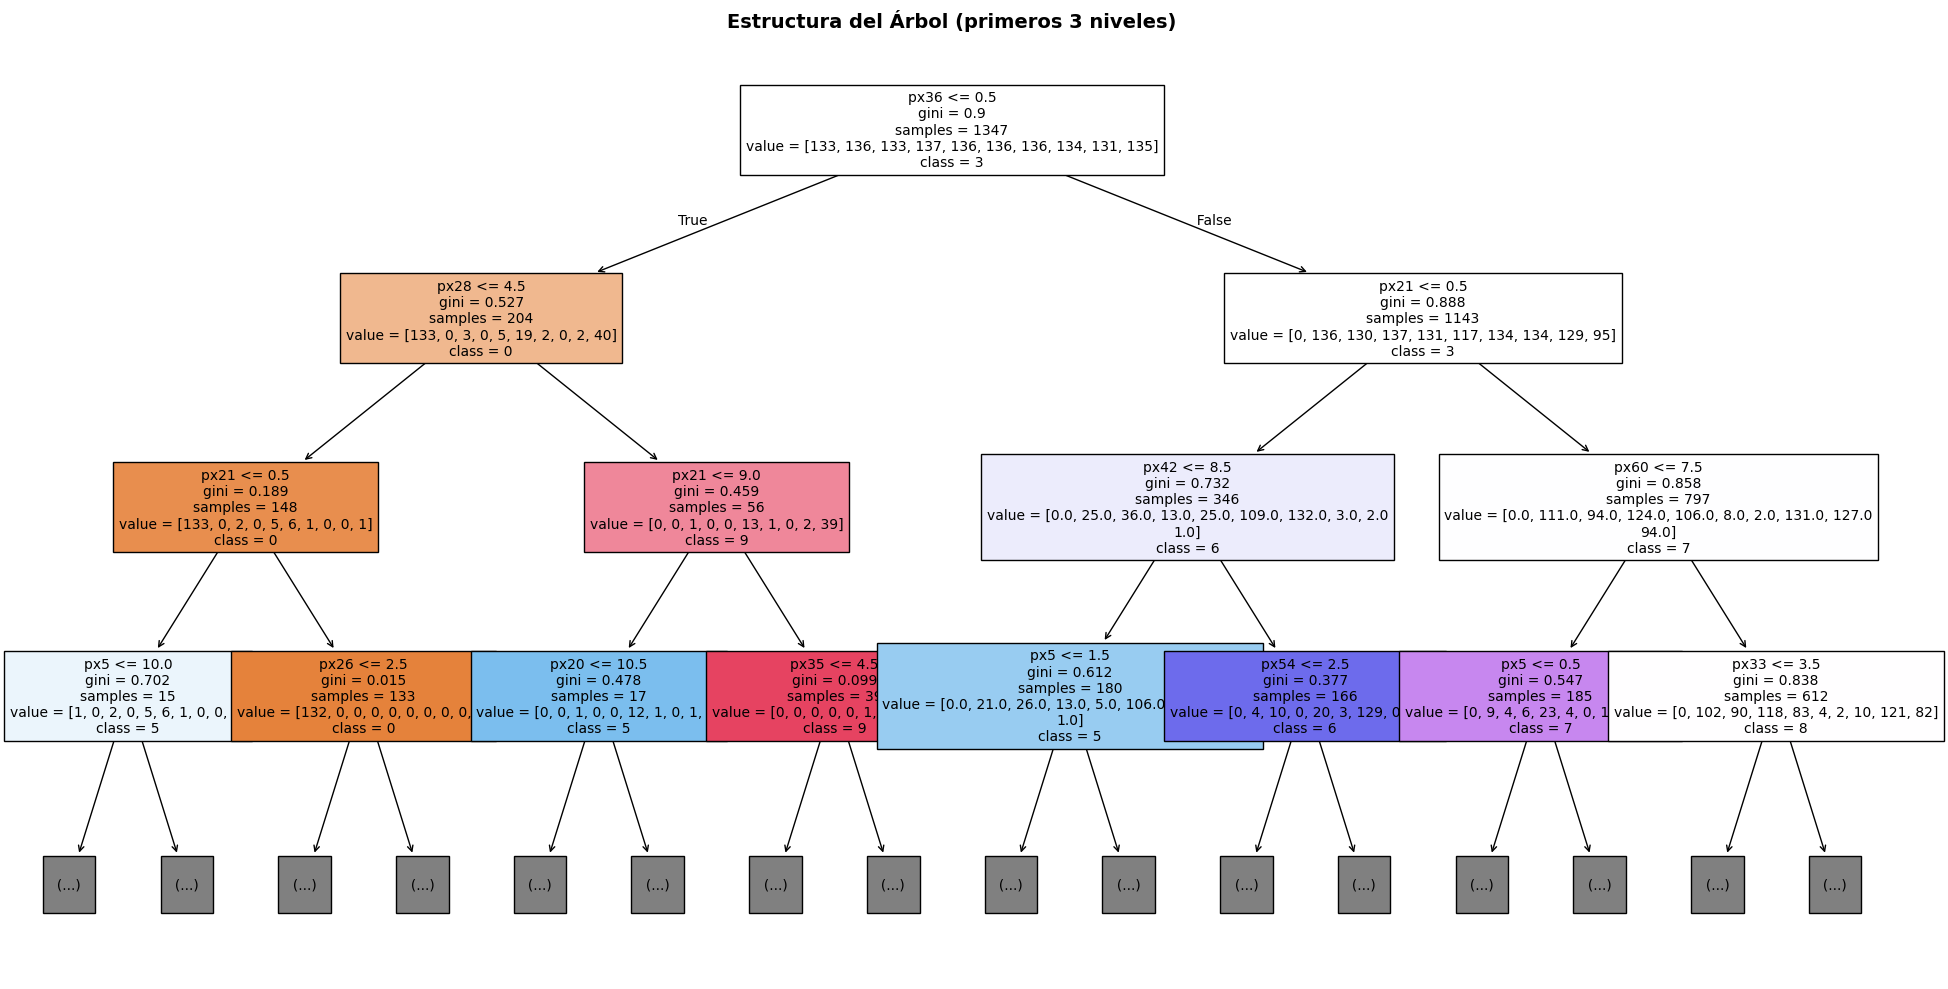

In [3]:
# ============================================================================
# SECCIÓN 2: CLASIFICACIÓN CON DIGITS
# ============================================================================
print("\n\n" + "="*80)
print("SECCIÓN 2: CLASIFICACIÓN - Reconocimiento de Dígitos (8x8)")
print("="*80)

# Cargar datos
digits = load_digits()
X, y = digits.data, digits.target

print(f"\n📊 Dataset DIGITS:")
print(f"   • {X.shape[0]} imágenes de dígitos (0-9)")
print(f"   • {X.shape[1]} características (píxeles 8x8)")
print(f"   • {len(np.unique(y))} clases")

# Visualizar ejemplos
fig, axes = plt.subplots(2, 5, figsize=(12, 5))
for i, ax in enumerate(axes.flat):
    ax.imshow(digits.images[i], cmap='gray')
    ax.set_title(f"Dígito: {digits.target[i]}", fontsize=12, fontweight='bold')
    ax.axis('off')
plt.suptitle("Ejemplos del Dataset DIGITS", fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

# Split estratificado
print("\n🔀 División estratificada 75/25:")
print("   💡 Mantiene la proporción de cada clase en train y test")
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, random_state=42, stratify=y
)
print(f"   ✓ Train: {X_train.shape[0]} muestras")
print(f"   ✓ Test: {X_test.shape[0]} muestras")

# Modelo base
print("\n🌳 Entrenando Árbol Base (max_depth=10)...")
clf_base = DecisionTreeClassifier(criterion="gini", max_depth=10, random_state=42)
clf_base.fit(X_train, y_train)

y_pred = clf_base.predict(X_test)
acc = accuracy_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred, average="macro")

print(f"""
   📊 RESULTADOS INICIALES:
   • Accuracy: {acc:.4f} ({acc*100:.1f}% de aciertos)
   • F1-macro: {f1:.4f}
   • Hojas: {clf_base.get_n_leaves()}
   • Profundidad: {clf_base.get_depth()}
""")

# Matriz de confusión
fig, ax = plt.subplots(figsize=(10, 8))
ConfusionMatrixDisplay.from_predictions(y_test, y_pred, ax=ax, cmap='Blues')
plt.title("Matriz de Confusión - Árbol Base", fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

# Visualizar árbol (parcial)
plt.figure(figsize=(20, 10))
plot_tree(clf_base, max_depth=3, filled=True, fontsize=10,
          feature_names=[f"px{i}" for i in range(X.shape[1])],
          class_names=[str(i) for i in range(10)])
plt.title("Estructura del Árbol (primeros 3 niveles)", fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

In [4]:
# ============================================================================
# 2.1 EXPLICACIÓN DETALLADA DE MÉTRICAS DE CLASIFICACIÓN
# ============================================================================
print("\n" + "─"*80)
print("2.1 MÉTRICAS DE CLASIFICACIÓN - Guía Completa")
print("─"*80)

print("""
📚 FUNDAMENTOS: MATRIZ DE CONFUSIÓN

Para entender las métricas, primero necesitamos la matriz de confusión:

                    PREDICCIÓN
                 Clase 0  Clase 1  Clase 2
              ┌─────────┬────────┬────────┐
    REALIDAD  │   TP₀   │  FN₀→₁ │ FN₀→₂  │  Clase 0
              ├─────────┼────────┼────────┤
              │  FP₁←₀  │   TP₁  │ FN₁→₂  │  Clase 1
              ├─────────┼────────┼────────┤
              │  FP₂←₀  │ FP₂←₁  │   TP₂  │  Clase 2
              └─────────┴────────┴────────┘

Para CADA clase i:
  • TP_i (True Positive): Predijo i y ERA i ✓
  • FP_i (False Positive): Predijo i pero NO era i ✗
  • FN_i (False Negative): Era i pero NO predijo i ✗
  • TN_i (True Negative): No era i y no predijo i ✓
""")

# Calcular métricas por clase
from sklearn.metrics import precision_score, recall_score, classification_report

print("\n🔬 MÉTRICAS POR CLASE (primeras 3 clases como ejemplo):")
print("─"*70)

# Calcular para cada clase
for digit in range(3):
    # Convertir a problema binario (clase i vs resto)
    y_test_binary = (y_test == digit).astype(int)
    y_pred_binary = (y_pred == digit).astype(int)

    tp = np.sum((y_test_binary == 1) & (y_pred_binary == 1))
    fp = np.sum((y_test_binary == 0) & (y_pred_binary == 1))
    fn = np.sum((y_test_binary == 1) & (y_pred_binary == 0))
    tn = np.sum((y_test_binary == 0) & (y_pred_binary == 0))

    precision = tp / (tp + fp) if (tp + fp) > 0 else 0
    recall = tp / (tp + fn) if (tp + fn) > 0 else 0
    f1 = 2 * (precision * recall) / (precision + recall) if (precision + recall) > 0 else 0

    print(f"\n📊 CLASE {digit} (Dígito '{digit}'):")
    print(f"   TP={tp:3d}  FP={fp:3d}  FN={fn:3d}  TN={tn:3d}")
    print(f"   Precision = TP/(TP+FP) = {tp}/({tp}+{fp}) = {precision:.3f}")
    print(f"   Recall    = TP/(TP+FN) = {tp}/({tp}+{fn}) = {recall:.3f}")
    print(f"   F1-score  = 2×(P×R)/(P+R) = {f1:.3f}")

print("\n" + "─"*70)
print("\n💡 INTERPRETACIÓN DE LAS MÉTRICAS:\n")

print("""
1️⃣ ACCURACY (Exactitud)
   Fórmula: (TP + TN) / Total

   📌 Pregunta: "¿Qué porcentaje de predicciones fueron correctas?"

   ✅ USAR CUANDO:
   • Las clases están balanceadas
   • Todos los errores tienen el mismo costo
   • Métrica simple y fácil de explicar

   ⚠️ PROBLEMA:
   • Engañosa con clases desbalanceadas

   Ejemplo: 95% negativos, 5% positivos
   Modelo que predice siempre negativo → 95% accuracy ¡Pero no detecta positivos!

2️⃣ PRECISION (Precisión)
   Fórmula: TP / (TP + FP)

   📌 Pregunta: "De los que predije como positivos, ¿cuántos acerté?"
   📌 Sinónimo: "¿Qué tan CONFIABLE soy cuando digo SÍ?"

   ✅ USAR CUANDO:
   • El costo de FALSOS POSITIVOS es ALTO
   • No quieres molestar con falsas alarmas

   Ejemplos:
   • Filtro de SPAM: No quieres borrar emails importantes
   • Recomendaciones: No sugieras productos malos (pierdes confianza)
   • Aprobación de créditos: No prestar a morosos

   Alta precisión = Pocos falsos positivos

3️⃣ RECALL (Sensibilidad, Exhaustividad)
   Fórmula: TP / (TP + FN)

   📌 Pregunta: "De todos los positivos reales, ¿cuántos detecté?"
   📌 Sinónimo: "¿Qué tan bueno soy para NO DEJAR PASAR casos?"

   ✅ USAR CUANDO:
   • El costo de FALSOS NEGATIVOS es ALTO
   • No puedes permitirte perder casos positivos

   Ejemplos:
   • Detección de CÁNCER: No dejar pasar enfermos
   • Detección de FRAUDE: No dejar pasar transacciones fraudulentas
   • Alarmas de INCENDIO: Mejor falsa alarma que no detectar

   Alto recall = Pocos falsos negativos

4️⃣ F1-SCORE
   Fórmula: 2 × (Precision × Recall) / (Precision + Recall)

   📌 Pregunta: "¿Cuál es el BALANCE entre Precision y Recall?"

   • Media armónica (penaliza valores dispares)
   • Si Precision=1.0 y Recall=0.1 → F1=0.18 (no 0.55)

   ✅ USAR CUANDO:
   • No puedes decidir entre precision y recall
   • Ambos errores son igualmente importantes
   • Clases desbalanceadas (mejor que accuracy)

   Ejemplo: Sistema de clasificación de emails
   • Precision: No perder emails importantes
   • Recall: Detectar todo el spam
   • F1: Balance entre ambos objetivos
""")



────────────────────────────────────────────────────────────────────────────────
2.1 MÉTRICAS DE CLASIFICACIÓN - Guía Completa
────────────────────────────────────────────────────────────────────────────────

📚 FUNDAMENTOS: MATRIZ DE CONFUSIÓN

Para entender las métricas, primero necesitamos la matriz de confusión:

                    PREDICCIÓN
                 Clase 0  Clase 1  Clase 2
              ┌─────────┬────────┬────────┐
    REALIDAD  │   TP₀   │  FN₀→₁ │ FN₀→₂  │  Clase 0
              ├─────────┼────────┼────────┤
              │  FP₁←₀  │   TP₁  │ FN₁→₂  │  Clase 1
              ├─────────┼────────┼────────┤
              │  FP₂←₀  │ FP₂←₁  │   TP₂  │  Clase 2
              └─────────┴────────┴────────┘

Para CADA clase i:
  • TP_i (True Positive): Predijo i y ERA i ✓
  • FP_i (False Positive): Predijo i pero NO era i ✗
  • FN_i (False Negative): Era i pero NO predijo i ✗
  • TN_i (True Negative): No era i y no predijo i ✓


🔬 MÉTRICAS POR CLASE (primeras 3 clases como e


────────────────────────────────────────────────────────────────────────────────
2.2 PROMEDIOS: MACRO vs MICRO vs WEIGHTED
────────────────────────────────────────────────────────────────────────────────

🎯 EL PROBLEMA: Tienes métricas para cada clase, ¿cómo las combinas?

Calculemos las 3 formas para nuestro modelo:


📊 Métricas individuales por clase:
              precision    recall  f1-score   support

           0      0.932     0.911     0.921        45
           1      0.800     0.783     0.791        46
           2      0.850     0.773     0.810        44
           3      0.905     0.826     0.864        46
           4      0.809     0.844     0.826        45
           5      0.915     0.935     0.925        46
           6      0.951     0.867     0.907        45
           7      0.707     0.911     0.796        45
           8      0.775     0.721     0.747        43
           9      0.761     0.778     0.769        45

    accuracy                          0.836    

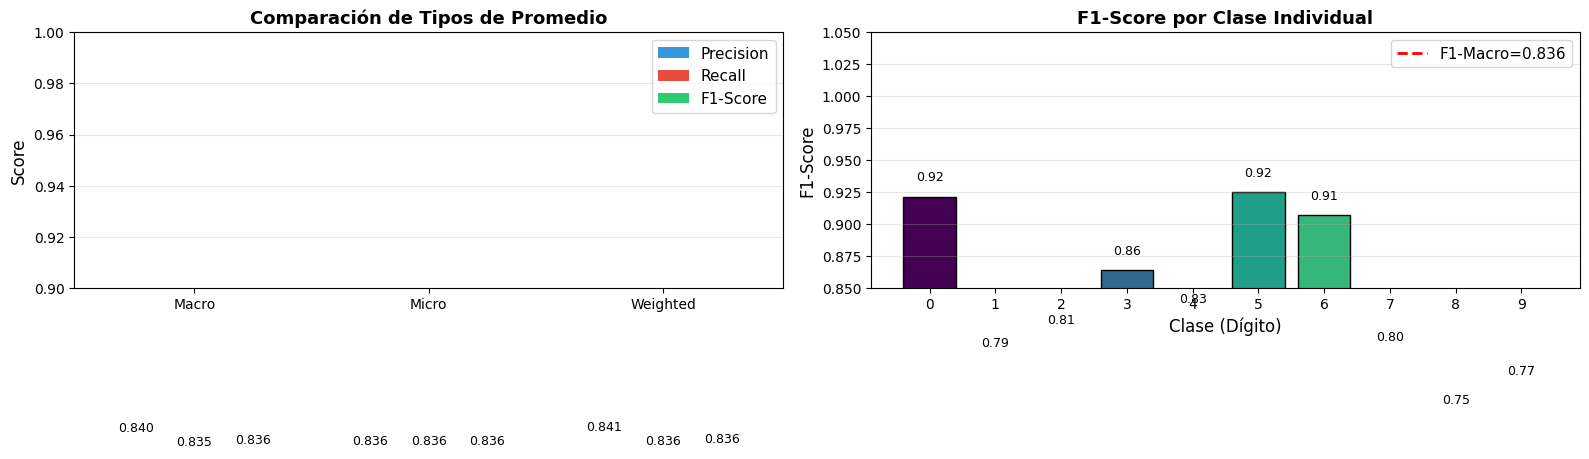


📊 MATRIZ DE CONFUSIÓN:
   (Ayuda a identificar qué clases se confunden)


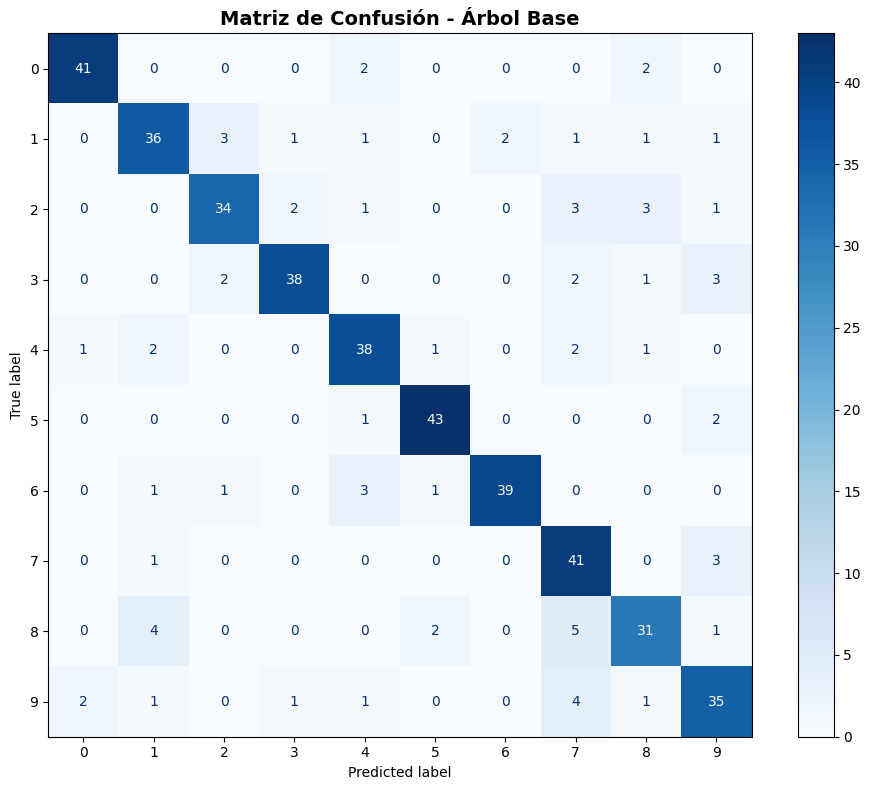


💡 INTERPRETACIÓN DE LA MATRIZ:
   • Diagonal principal = Predicciones correctas ✓
   • Fuera de diagonal = Errores ✗
   • Fila i, columna j = casos de clase i predichos como j

   Busca patrones:
   • ¿Qué clases se confunden más?
   • ¿Hay clases problemáticas?


🌳 ESTRUCTURA DEL ÁRBOL:


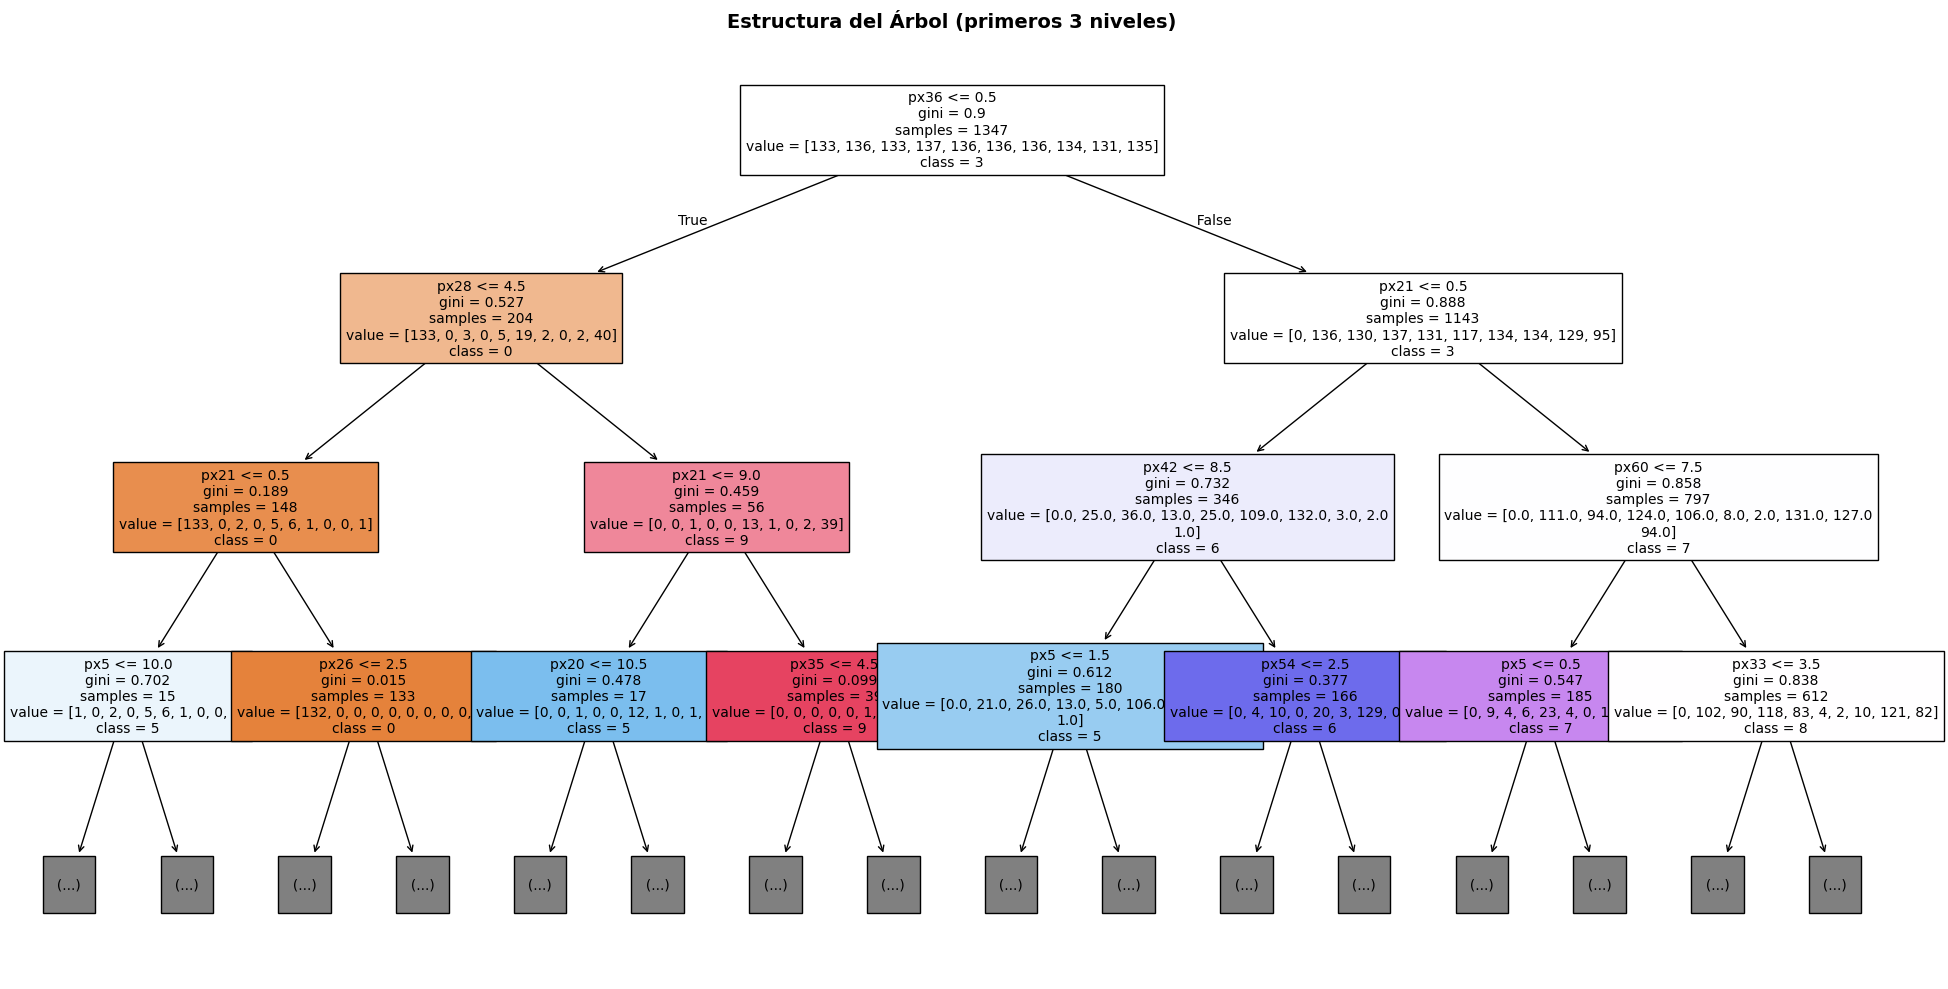


💡 LECTURA DEL ÁRBOL:
   • 'gini' = impureza del nodo
   • 'samples' = cuántos ejemplos llegan ahí
   • 'value' = distribución de clases [clase0, clase1, ...]
   • 'class' = clase mayoritaria (predicción)
   • Color = pureza del nodo (más oscuro = más puro)



In [5]:
# ============================================================================
# 2.2 MÉTRICAS MACRO vs MICRO vs WEIGHTED
# ============================================================================
print("\n" + "─"*80)
print("2.2 PROMEDIOS: MACRO vs MICRO vs WEIGHTED")
print("─"*80)

print("""
🎯 EL PROBLEMA: Tienes métricas para cada clase, ¿cómo las combinas?

Calculemos las 3 formas para nuestro modelo:
""")

# Calcular todas las variantes
precision_macro = precision_score(y_test, y_pred, average='macro')
precision_micro = precision_score(y_test, y_pred, average='micro')
precision_weighted = precision_score(y_test, y_pred, average='weighted')

recall_macro = recall_score(y_test, y_pred, average='macro')
recall_micro = recall_score(y_test, y_pred, average='micro')
recall_weighted = recall_score(y_test, y_pred, average='weighted')

f1_macro = f1_score(y_test, y_pred, average='macro')
f1_micro = f1_score(y_test, y_pred, average='micro')
f1_weighted = f1_score(y_test, y_pred, average='weighted')

# Mostrar métricas por clase
print("\n📊 Métricas individuales por clase:")
print(classification_report(y_test, y_pred, digits=3))

print("\n" + "─"*70)
print("COMPARACIÓN DE PROMEDIOS:")
print("─"*70)
print(f"""
                MACRO      MICRO     WEIGHTED
Precision:     {precision_macro:.4f}     {precision_micro:.4f}     {precision_weighted:.4f}
Recall:        {recall_macro:.4f}     {recall_micro:.4f}     {recall_weighted:.4f}
F1-Score:      {f1_macro:.4f}     {f1_micro:.4f}     {f1_weighted:.4f}
""")

print("""
💡 ¿QUÉ SIGNIFICA CADA UNO?

1️⃣ MACRO AVERAGE (Promedio Simple)

   Cálculo: (Métrica_clase0 + Métrica_clase1 + ... + Métrica_clase9) / 10

   🎯 Trata TODAS las clases POR IGUAL
   • Cada clase contribuye 1/N al promedio
   • Sin importar cuántos ejemplos tenga

   ✅ USAR CUANDO:
   • Todas las clases son igualmente importantes
   • Quieres penalizar mal desempeño en clases minoritarias
   • Clases desbalanceadas pero cada una importa

   Ejemplo: Diagnóstico de 10 enfermedades
   → Cada enfermedad cuenta igual, aunque una sea rara

2️⃣ MICRO AVERAGE (Suma Global)

   Cálculo:
   Total_TP = TP_clase0 + TP_clase1 + ... + TP_clase9
   Total_FP = FP_clase0 + FP_clase1 + ... + FP_clase9
   Total_FN = FN_clase0 + FN_clase1 + ... + FN_clase9

   Precision_micro = Total_TP / (Total_TP + Total_FP)

   🎯 Las clases GRANDES dominan el resultado
   • Equivale a Accuracy en clasificación multiclase
   • Ponderación proporcional al tamaño

   ✅ USAR CUANDO:
   • El volumen de la clase refleja su importancia
   • Quieres priorizar desempeño global
   • Las clases están balanceadas

   Ejemplo: Clasificación de productos en e-commerce
   → Los productos más vendidos son más importantes

3️⃣ WEIGHTED AVERAGE (Promedio Ponderado)

   Cálculo:
   F1_weighted = Σ(F1_i × n_i) / N
   Donde n_i = número de ejemplos de clase i

   🎯 Balance intermedio entre macro y micro
   • Considera el tamaño de cada clase
   • Pero sin que las grandes dominen completamente

   ✅ USAR CUANDO:
   • Quieres considerar el tamaño de las clases
   • Pero todas siguen siendo importantes
   • Balance entre equidad y realismo

━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

🎯 REGLA DE DECISIÓN:

¿Todas las clases = importancia? → MACRO ⭐
¿Clases grandes = más importantes? → MICRO
¿Dudas? → Reporta MACRO y WEIGHTED

En DIGITS (relativamente balanceado):
• Micro ≈ Accuracy ({f1_micro:.4f})
• Macro considera todas las clases igual ({f1_macro:.4f})
• Weighted similar a micro ({f1_weighted:.4f})

→ Para este problema, las 3 son similares (dataset balanceado)
""")

# Visualización comparativa
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Gráfico 1: Métricas por promedio
ax1 = axes[0]
metrics_types = ['Macro', 'Micro', 'Weighted']
precision_values = [precision_macro, precision_micro, precision_weighted]
recall_values = [recall_macro, recall_micro, recall_weighted]
f1_values = [f1_macro, f1_micro, f1_weighted]

x = np.arange(len(metrics_types))
width = 0.25

bars1 = ax1.bar(x - width, precision_values, width, label='Precision', color='#3498DB')
bars2 = ax1.bar(x, recall_values, width, label='Recall', color='#E74C3C')
bars3 = ax1.bar(x + width, f1_values, width, label='F1-Score', color='#2ECC71')

ax1.set_ylabel('Score', fontsize=12)
ax1.set_title('Comparación de Tipos de Promedio', fontsize=13, fontweight='bold')
ax1.set_xticks(x)
ax1.set_xticklabels(metrics_types)
ax1.legend(fontsize=11)
ax1.set_ylim([0.9, 1.0])
ax1.grid(alpha=0.3, axis='y')

# Añadir valores
for bars in [bars1, bars2, bars3]:
    for bar in bars:
        height = bar.get_height()
        ax1.text(bar.get_x() + bar.get_width()/2., height + 0.002,
                f'{height:.3f}', ha='center', va='bottom', fontsize=9)

# Gráfico 2: F1 por clase
ax2 = axes[1]
f1_per_class = f1_score(y_test, y_pred, average=None)
class_labels = [str(i) for i in range(10)]
colors_gradient = plt.cm.viridis(np.linspace(0, 1, 10))

bars = ax2.bar(class_labels, f1_per_class, color=colors_gradient, edgecolor='black')
ax2.axhline(f1_macro, color='red', linestyle='--', linewidth=2, label=f'F1-Macro={f1_macro:.3f}')
ax2.set_xlabel('Clase (Dígito)', fontsize=12)
ax2.set_ylabel('F1-Score', fontsize=12)
ax2.set_title('F1-Score por Clase Individual', fontsize=13, fontweight='bold')
ax2.legend(fontsize=11)
ax2.set_ylim([0.85, 1.05])
ax2.grid(alpha=0.3, axis='y')

# Añadir valores
for bar in bars:
    height = bar.get_height()
    ax2.text(bar.get_x() + bar.get_width()/2., height + 0.01,
            f'{height:.2f}', ha='center', va='bottom', fontsize=9)

plt.tight_layout()
plt.show()

# Matriz de confusión
print("\n📊 MATRIZ DE CONFUSIÓN:")
print("   (Ayuda a identificar qué clases se confunden)")
fig, ax = plt.subplots(figsize=(10, 8))
ConfusionMatrixDisplay.from_predictions(y_test, y_pred, ax=ax, cmap='Blues')
plt.title("Matriz de Confusión - Árbol Base", fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

print("""
💡 INTERPRETACIÓN DE LA MATRIZ:
   • Diagonal principal = Predicciones correctas ✓
   • Fuera de diagonal = Errores ✗
   • Fila i, columna j = casos de clase i predichos como j

   Busca patrones:
   • ¿Qué clases se confunden más?
   • ¿Hay clases problemáticas?
""")

# Visualizar árbol (parcial)
print("\n🌳 ESTRUCTURA DEL ÁRBOL:")
plt.figure(figsize=(20, 10))
plot_tree(clf_base, max_depth=3, filled=True, fontsize=10,
          feature_names=[f"px{i}" for i in range(X.shape[1])],
          class_names=[str(i) for i in range(10)])
plt.title("Estructura del Árbol (primeros 3 niveles)", fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

print("""
💡 LECTURA DEL ÁRBOL:
   • 'gini' = impureza del nodo
   • 'samples' = cuántos ejemplos llegan ahí
   • 'value' = distribución de clases [clase0, clase1, ...]
   • 'class' = clase mayoritaria (predicción)
   • Color = pureza del nodo (más oscuro = más puro)
""")


#Regresión


SECCIÓN 3: REGRESIÓN - Predicción de Progresión de Diabetes

📊 Dataset DIABETES:
   • 442 pacientes
   • 10 características (edad, IMC, presión, etc.)
   • Objetivo: progresión de la enfermedad [25, 346]

🌳 Entrenando Árbol de Regresión (max_depth=6)...

   📊 MÉTRICAS:
   • RMSE: 66.74 (error promedio)
   • MAE:  52.34 (error absoluto medio)
   • R²:   0.194 (19.4% de varianza explicada)



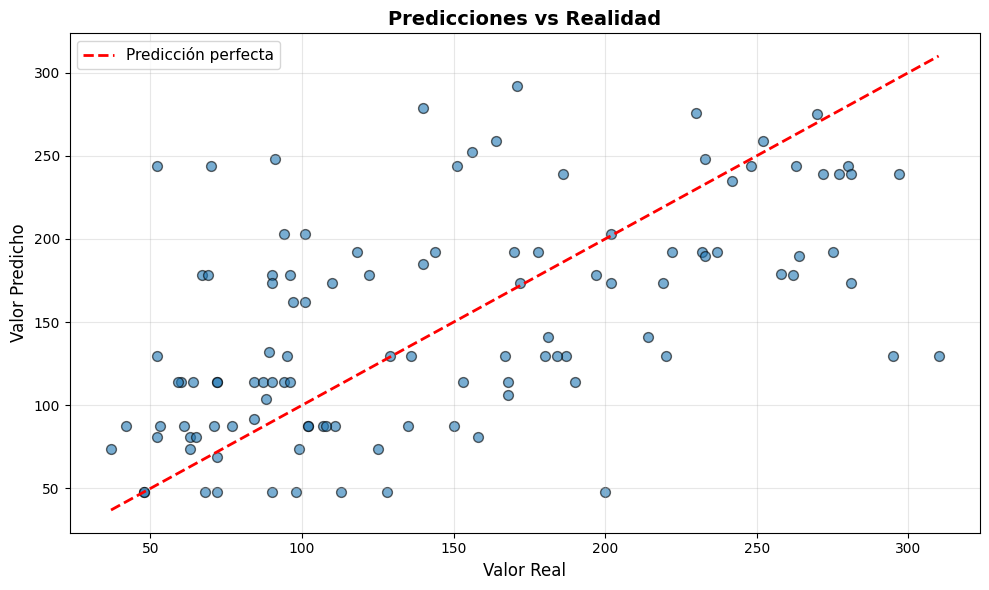

In [6]:
# ============================================================================
# SECCIÓN 3: REGRESIÓN CON DIABETES
# ============================================================================
print("\n" + "="*80)
print("SECCIÓN 3: REGRESIÓN - Predicción de Progresión de Diabetes")
print("="*80)

diabetes = load_diabetes()
X_reg, y_reg = diabetes.data, diabetes.target

print(f"\n📊 Dataset DIABETES:")
print(f"   • {X_reg.shape[0]} pacientes")
print(f"   • {X_reg.shape[1]} características (edad, IMC, presión, etc.)")
print(f"   • Objetivo: progresión de la enfermedad [{y_reg.min():.0f}, {y_reg.max():.0f}]")

X_reg_train, X_reg_test, y_reg_train, y_reg_test = train_test_split(
    X_reg, y_reg, test_size=0.25, random_state=42
)

# Árbol de regresión
print("\n🌳 Entrenando Árbol de Regresión (max_depth=6)...")
reg_base = DecisionTreeRegressor(criterion="squared_error", max_depth=6, random_state=42)
reg_base.fit(X_reg_train, y_reg_train)

y_reg_pred = reg_base.predict(X_reg_test)
rmse = mean_squared_error(y_reg_test, y_reg_pred)
rmse=np.sqrt(rmse)
mae = mean_absolute_error(y_reg_test, y_reg_pred)
r2 = r2_score(y_reg_test, y_reg_pred)

print(f"""
   📊 MÉTRICAS:
   • RMSE: {rmse:.2f} (error promedio)
   • MAE:  {mae:.2f} (error absoluto medio)
   • R²:   {r2:.3f} ({r2*100:.1f}% de varianza explicada)
""")

# Visualizar predicciones
plt.figure(figsize=(10, 6))
plt.scatter(y_reg_test, y_reg_pred, alpha=0.6, edgecolors='k', s=50)
plt.plot([y_reg_test.min(), y_reg_test.max()],
         [y_reg_test.min(), y_reg_test.max()],
         'r--', lw=2, label='Predicción perfecta')
plt.xlabel('Valor Real', fontsize=12)
plt.ylabel('Valor Predicho', fontsize=12)
plt.title('Predicciones vs Realidad', fontsize=14, fontweight='bold')
plt.legend(fontsize=11)
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

In [7]:
# ============================================================================
# 3.1 EXPLICACIÓN DETALLADA DE MÉTRICAS DE REGRESIÓN
# ============================================================================
print("\n" + "─"*80)
print("3.1 MÉTRICAS DE REGRESIÓN - Guía Completa")
print("─"*80)

print("""
📚 FUNDAMENTOS: ¿QUÉ MEDIMOS EN REGRESIÓN?

En clasificación predecimos categorías (0, 1, 2...)
En regresión predecimos valores continuos (152.3, 89.7, 201.5...)

La pregunta es: ¿Qué tan cerca están nuestras predicciones de los valores reales?
""")

# Calcular errores para ejemplos
errors = y_reg_test - y_reg_pred
abs_errors = np.abs(errors)
squared_errors = errors ** 2

print(f"\n🔬 ANÁLISIS DE ERRORES (primeros 10 casos):")
print("─"*70)
print("  #  | Real  | Pred  | Error | |Error| | Error²")
print("─"*70)
for i in range(min(10, len(y_reg_test))):
    print(f" {i+1:2d}  | {y_reg_test.iloc[i] if hasattr(y_reg_test, 'iloc') else y_reg_test[i]:5.1f} | {y_reg_pred[i]:5.1f} | {errors[i]:6.1f} | {abs_errors[i]:7.1f} | {squared_errors[i]:7.1f}")
print("─"*70)

print("\n💡 MÉTRICAS DE REGRESIÓN:\n")

print(f"""
1️⃣ MAE (Mean Absolute Error) - Error Absoluto Medio

   Fórmula: MAE = (1/n) × Σ|y_real - y_pred|

   📌 Pregunta: "En promedio, ¿cuánto me equivoco?"

   En nuestro caso: MAE = {mae:.2f}
   → En promedio, nos equivocamos {mae:.2f} unidades

   ✅ VENTAJAS:
   • Fácil de interpretar (mismas unidades que y)
   • Robusto a outliers
   • Todos los errores pesan igual

   ⚠️ DESVENTAJAS:
   • No penaliza errores grandes extra
   • No diferenciable en 0 (problemas de optimización)

   📌 USAR CUANDO:
   • Los outliers NO deben dominar
   • Quieres métrica robusta
   • Errores grandes y pequeños = mismo impacto

   Ejemplo: Predicción de precios de casas
   → Error de $10k en casa de $100k = Error de $10k en casa de $1M
   → Ambos errores cuentan igual

2️⃣ MSE (Mean Squared Error) - Error Cuadrático Medio

   Fórmula: MSE = (1/n) × Σ(y_real - y_pred)²

   En nuestro caso: MSE = {mse:.2f}

   ✅ VENTAJAS:
   • Penaliza MÁS los errores grandes
   • Diferenciable en todo punto (bueno para optimización)
   • Usado en entrenamiento de modelos

   ⚠️ DESVENTAJAS:
   • Unidades al cuadrado (difícil interpretar)
   • MUY sensible a outliers
   • Un solo error grande puede dominar

   📌 USAR CUANDO:
   • Errores grandes son MUY malos
   • Durante entrenamiento (optimización)
   • Quieres penalizar varianza

   💡 Comparación de penalización:
   Error de 10: MAE=10, MSE=100
   Error de 100: MAE=100, MSE=10,000 ← ¡100x más penalizado!

3️⃣ RMSE (Root Mean Squared Error) - Raíz del ECM

   Fórmula: RMSE = √MSE = √[(1/n) × Σ(y_real - y_pred)²]

   En nuestro caso: RMSE = {rmse:.2f}
   → En promedio, nos equivocamos {rmse:.2f} unidades (penalizando más los errores grandes)

   ✅ VENTAJAS:
   • Mismas unidades que y (fácil interpretar)
   • Penaliza errores grandes
   • Métrica estándar en competencias

   ⚠️ DESVENTAJAS:
   • Sensible a outliers
   • Siempre mayor o igual que MAE

   📌 USAR CUANDO:
   • Quieres penalizar errores grandes
   • Necesitas unidades interpretables
   • Es el estándar de tu industria

   💡 Relación con MAE:
   MAE = {mae:.2f}
   RMSE = {rmse:.2f}
   RMSE > MAE → Hay variabilidad en los errores
   RMSE ≈ MAE → Errores son consistentes

4️⃣ R² (Coeficiente de Determinación)

   Fórmula: R² = 1 - (SS_res / SS_tot)

   Donde:
   SS_res = Σ(y_real - y_pred)²  ← Error del modelo
   SS_tot = Σ(y_real - ȳ)²       ← Variabilidad total

   En nuestro caso: R² = {r2:.3f}

   📌 Pregunta: "¿Qué proporción de la variabilidad explico?"

   → {r2*100:.1f}% de la varianza en los datos es explicada por el modelo
   → {(1-r2)*100:.1f}% permanece sin explicar

   ✅ INTERPRETACIÓN:
   R² = 1.0  → Predicción perfecta ✓✓✓
   R² = 0.8  → Muy bueno (explica 80%)
   R² = 0.5  → Moderado (explica 50%)
   R² = 0.0  → Tan malo como predecir la media
   R² < 0.0  → Peor que predecir la media ✗✗✗

   ⚠️ CUIDADO:
   • NO tiene unidades (adimensional)
   • Puede ser negativo (modelo muy malo)
   • Sensible a outliers
   • Aumenta al agregar variables (usar R² ajustado)

   📌 USAR CUANDO:
   • Quieres porcentaje de varianza explicada
   • Comparar modelos con misma variable objetivo
   • Comunicar a audiencia no técnica

5️⃣ MAPE (Mean Absolute Percentage Error) - Error Porcentual

   Fórmula: MAPE = (100/n) × Σ|((y_real - y_pred) / y_real)|

   📌 Pregunta: "¿Cuál es mi error como porcentaje?"
""")

# Calcular MAPE (evitando división por cero)
mape = np.mean(np.abs((y_reg_test - y_reg_pred) / y_reg_test)) * 100

print(f"""
   En nuestro caso: MAPE = {mape:.2f}%
   → En promedio, nos equivocamos un {mape:.2f}%

   ✅ VENTAJAS:
   • Fácil de interpretar (porcentaje)
   • Escala independiente
   • Comparable entre diferentes problemas

   ⚠️ DESVENTAJAS:
   • Indefinido cuando y_real = 0
   • Asimétrico (penaliza más subestimar que sobreestimar)
   • Sesgado hacia predicciones bajas

   📌 USAR CUANDO:
   • Quieres error relativo (no absoluto)
   • Comparar modelos en diferentes escalas
   • Variables positivas (precios, ventas, etc.)
""")


────────────────────────────────────────────────────────────────────────────────
3.1 MÉTRICAS DE REGRESIÓN - Guía Completa
────────────────────────────────────────────────────────────────────────────────

📚 FUNDAMENTOS: ¿QUÉ MEDIMOS EN REGRESIÓN?

En clasificación predecimos categorías (0, 1, 2...)
En regresión predecimos valores continuos (152.3, 89.7, 201.5...)

La pregunta es: ¿Qué tan cerca están nuestras predicciones de los valores reales?


🔬 ANÁLISIS DE ERRORES (primeros 10 casos):
──────────────────────────────────────────────────────────────────────
  #  | Real  | Pred  | Error | |Error| | Error²
──────────────────────────────────────────────────────────────────────
  1  | 219.0 | 173.3 |   45.7 |    45.7 |  2088.5
  2  |  70.0 | 243.7 | -173.7 |   173.7 | 30181.2
  3  | 202.0 | 173.3 |   28.7 |    28.7 |   823.7
  4  | 230.0 | 276.0 |  -46.0 |    46.0 |  2116.0
  5  | 111.0 |  87.5 |   23.5 |    23.5 |   554.4
  6  |  84.0 | 113.9 |  -29.9 |    29.9 |   895.0
  7  | 242.0 | 


────────────────────────────────────────────────────────────────────────────────
3.2 VISUALIZACIÓN Y COMPARACIÓN
────────────────────────────────────────────────────────────────────────────────


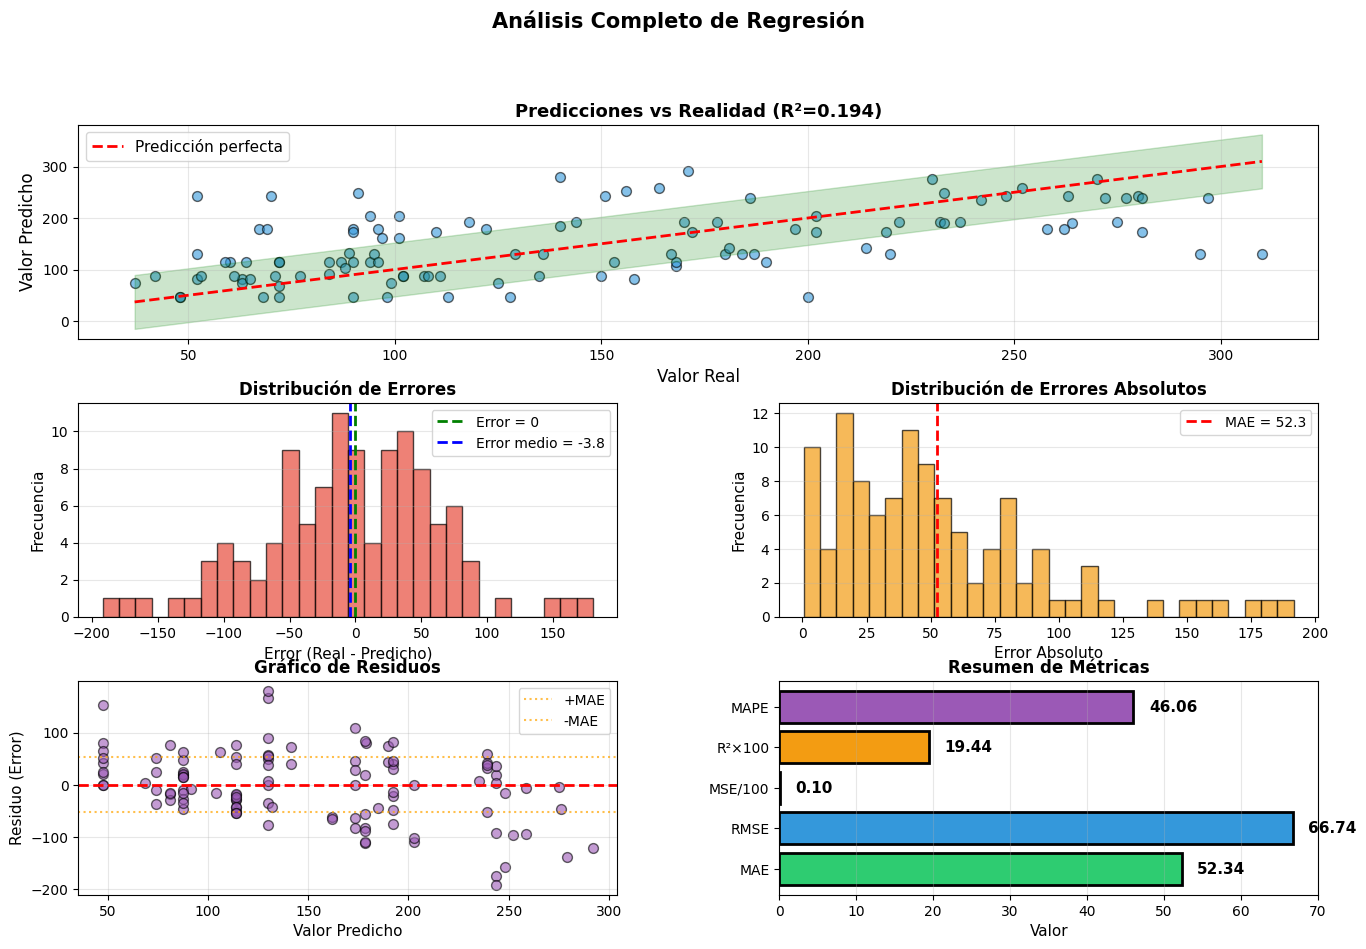


💡 INTERPRETACIÓN DE LOS GRÁFICOS:

1️⃣ Predicciones vs Realidad:
   • Puntos cerca de línea roja = buenas predicciones
   • Dispersión = variabilidad del error
   • Patrones sistemáticos = sesgo del modelo

2️⃣ Distribución de Errores:
   • Centrada en 0 = modelo sin sesgo ✓
   • Simétrica = errores balanceados
   • Colas pesadas = outliers problemáticos

3️⃣ Errores Absolutos:
   • Mayoría cerca de 0 = buen modelo
   • Cola larga = casos difíciles de predecir

4️⃣ Gráfico de Residuos:
   • Sin patrones = modelo bien especificado ✓
   • Embudo = heterocedasticidad
   • Curva = no linealidad no capturada

5️⃣ Resumen de Métricas:
   • MAE: Error típico en unidades originales
   • RMSE: Penaliza más errores grandes
   • R²: Porcentaje de varianza explicada



In [8]:
# ============================================================================
# 3.2 COMPARACIÓN VISUAL DE MÉTRICAS
# ============================================================================
print("\n" + "─"*80)
print("3.2 VISUALIZACIÓN Y COMPARACIÓN")
print("─"*80)

# Crear figura con múltiples subplots
fig = plt.figure(figsize=(16, 10))
gs = fig.add_gridspec(3, 2, hspace=0.3, wspace=0.3)

# 1. Predicciones vs Realidad
ax1 = fig.add_subplot(gs[0, :])
ax1.scatter(y_reg_test, y_reg_pred, alpha=0.6, edgecolors='k', s=50, color='#3498DB')
ax1.plot([y_reg_test.min(), y_reg_test.max()],
         [y_reg_test.min(), y_reg_test.max()],
         'r--', lw=2, label='Predicción perfecta')
ax1.set_xlabel('Valor Real', fontsize=12)
ax1.set_ylabel('Valor Predicho', fontsize=12)
ax1.set_title(f'Predicciones vs Realidad (R²={r2:.3f})', fontsize=13, fontweight='bold')
ax1.legend(fontsize=11)
ax1.grid(alpha=0.3)

# Añadir líneas de error
ax1.fill_between([y_reg_test.min(), y_reg_test.max()],
                  [y_reg_test.min() - mae, y_reg_test.max() - mae],
                  [y_reg_test.min() + mae, y_reg_test.max() + mae],
                  alpha=0.2, color='green', label=f'±MAE ({mae:.1f})')

# 2. Distribución de errores
ax2 = fig.add_subplot(gs[1, 0])
ax2.hist(errors, bins=30, edgecolor='black', alpha=0.7, color='#E74C3C')
ax2.axvline(0, color='green', linestyle='--', linewidth=2, label='Error = 0')
ax2.axvline(errors.mean(), color='blue', linestyle='--', linewidth=2,
            label=f'Error medio = {errors.mean():.1f}')
ax2.set_xlabel('Error (Real - Predicho)', fontsize=11)
ax2.set_ylabel('Frecuencia', fontsize=11)
ax2.set_title('Distribución de Errores', fontsize=12, fontweight='bold')
ax2.legend(fontsize=10)
ax2.grid(alpha=0.3, axis='y')

# 3. Errores absolutos
ax3 = fig.add_subplot(gs[1, 1])
ax3.hist(abs_errors, bins=30, edgecolor='black', alpha=0.7, color='#F39C12')
ax3.axvline(mae, color='red', linestyle='--', linewidth=2,
            label=f'MAE = {mae:.1f}')
ax3.set_xlabel('Error Absoluto', fontsize=11)
ax3.set_ylabel('Frecuencia', fontsize=11)
ax3.set_title('Distribución de Errores Absolutos', fontsize=12, fontweight='bold')
ax3.legend(fontsize=10)
ax3.grid(alpha=0.3, axis='y')

# 4. Residuos vs predicciones
ax4 = fig.add_subplot(gs[2, 0])
ax4.scatter(y_reg_pred, errors, alpha=0.6, edgecolors='k', s=50, color='#9B59B6')
ax4.axhline(0, color='red', linestyle='--', linewidth=2)
ax4.axhline(mae, color='orange', linestyle=':', linewidth=1.5, alpha=0.7, label=f'+MAE')
ax4.axhline(-mae, color='orange', linestyle=':', linewidth=1.5, alpha=0.7, label=f'-MAE')
ax4.set_xlabel('Valor Predicho', fontsize=11)
ax4.set_ylabel('Residuo (Error)', fontsize=11)
ax4.set_title('Gráfico de Residuos', fontsize=12, fontweight='bold')
ax4.legend(fontsize=10)
ax4.grid(alpha=0.3)

# 5. Comparación de métricas
ax5 = fig.add_subplot(gs[2, 1])
metrics_names = ['MAE', 'RMSE', 'MSE/100', f'R²×100', f'MAPE']
metrics_values = [mae, rmse, mse/100, r2*100, mape]
colors_metrics = ['#2ECC71', '#3498DB', '#E74C3C', '#F39C12', '#9B59B6']

bars = ax5.barh(metrics_names, metrics_values, color=colors_metrics,
                edgecolor='black', linewidth=2)
for bar, val in zip(bars, metrics_values):
    ax5.text(val + 2, bar.get_y() + bar.get_height()/2,
            f'{val:.2f}', va='center', fontsize=11, fontweight='bold')
ax5.set_xlabel('Valor', fontsize=11)
ax5.set_title('Resumen de Métricas', fontsize=12, fontweight='bold')
ax5.grid(alpha=0.3, axis='x')

plt.suptitle('Análisis Completo de Regresión', fontsize=15, fontweight='bold', y=0.995)
plt.tight_layout()
plt.show()

print("""
💡 INTERPRETACIÓN DE LOS GRÁFICOS:

1️⃣ Predicciones vs Realidad:
   • Puntos cerca de línea roja = buenas predicciones
   • Dispersión = variabilidad del error
   • Patrones sistemáticos = sesgo del modelo

2️⃣ Distribución de Errores:
   • Centrada en 0 = modelo sin sesgo ✓
   • Simétrica = errores balanceados
   • Colas pesadas = outliers problemáticos

3️⃣ Errores Absolutos:
   • Mayoría cerca de 0 = buen modelo
   • Cola larga = casos difíciles de predecir

4️⃣ Gráfico de Residuos:
   • Sin patrones = modelo bien especificado ✓
   • Embudo = heterocedasticidad
   • Curva = no linealidad no capturada

5️⃣ Resumen de Métricas:
   • MAE: Error típico en unidades originales
   • RMSE: Penaliza más errores grandes
   • R²: Porcentaje de varianza explicada
""")


────────────────────────────────────────────────────────────────────────────────
3.3 MAE vs MSE/RMSE - ¿Cuál elegir?
────────────────────────────────────────────────────────────────────────────────

🎯 EJEMPLO PRÁCTICO: Efecto de outliers

Imaginemos dos modelos prediciendo precios de casas:


Modelo A: Errores pequeños consistentes
Real:  [100 150 200 180 120 160 140 190 170 110]
Pred:  [105 145 195 175 125 155 145 185 175 115]
Errores: [-5  5  5  5 -5  5 -5  5 -5 -5]

MAE_A  = 5.00
RMSE_A = 5.00

Modelo B: Un error grande (190 → 250)
Real:  [100 150 200 180 120 160 140 190 170 110]
Pred:  [100 150 200 180 120 160 140 250 170 110]
Errores: [  0   0   0   0   0   0   0 -60   0   0]

MAE_B  = 6.00   (aumentó 1.00)
RMSE_B = 18.97  (aumentó 13.97)

📊 OBSERVACIÓN:
   MAE aumentó solo 20.0%
   RMSE aumentó 279.5% ← ¡Mucho más sensible!

   → RMSE penaliza MÁS los errores grandes (cuadrático vs lineal)



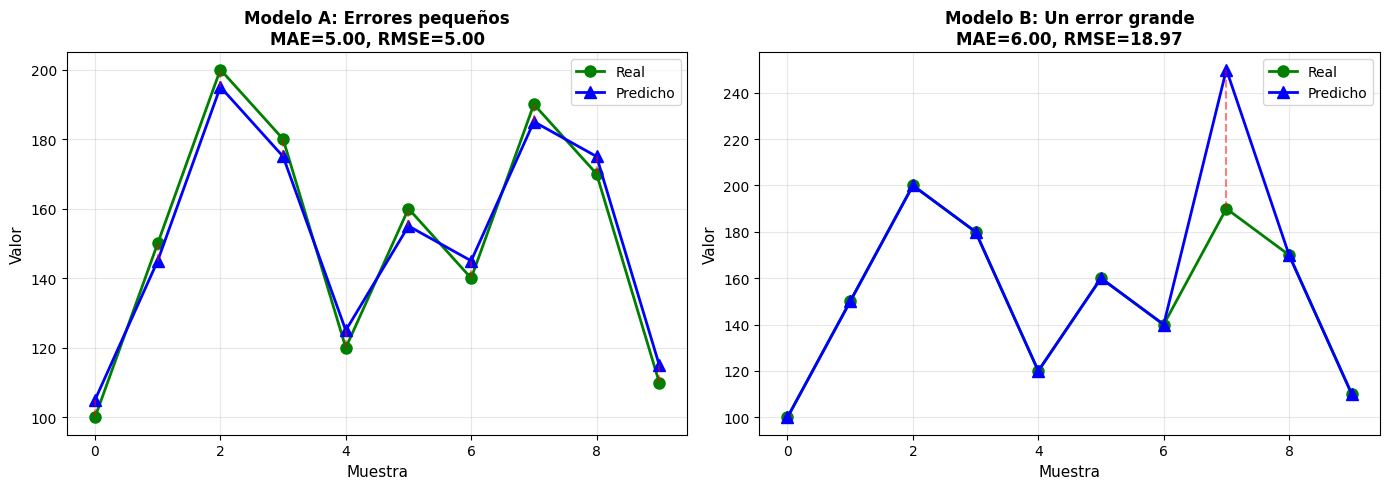


🎯 GUÍA DE DECISIÓN: MAE vs RMSE

USA MAE CUANDO:
├─ Los outliers NO deben dominar la métrica
├─ Todos los errores tienen el mismo "costo"
├─ Quieres robustez
└─ Ejemplo: Predicción de tiempo de entrega
   → Error de 1 día = Error de 1 día (sin importar si es 2→3 o 10→11)

USA RMSE CUANDO:
├─ Los errores grandes son MUY costosos
├─ Quieres penalizar variabilidad
├─ Es el estándar de tu industria/competencia
└─ Ejemplo: Predicción de demanda eléctrica
   → Error de 1000 MW puede causar apagón (muy grave)
   → Error de 10 MW es manejable
   → Necesitas penalizar los errores grandes extra

USA R² CUANDO:
├─ Quieres comunicar % de varianza explicada
├─ Comparar modelos con mismo target
├─ Audiencia no técnica
└─ Ejemplo: Reportar a stakeholders
   → "El modelo explica 75% de la variabilidad en ventas"
   → Más fácil que "RMSE de 1250.34 unidades"



In [9]:
# ============================================================================
# 3.3 COMPARACIÓN: MAE vs MSE EN PRÁCTICA
# ============================================================================
print("\n" + "─"*80)
print("3.3 MAE vs MSE/RMSE - ¿Cuál elegir?")
print("─"*80)

print("""
🎯 EJEMPLO PRÁCTICO: Efecto de outliers

Imaginemos dos modelos prediciendo precios de casas:
""")

# Crear ejemplo sintético
y_true_example = np.array([100, 150, 200, 180, 120, 160, 140, 190, 170, 110])
y_pred_model_a = np.array([105, 145, 195, 175, 125, 155, 145, 185, 175, 115])
y_pred_model_b = np.array([100, 150, 200, 180, 120, 160, 140, 250, 170, 110])  # Un error grande

mae_a = mean_absolute_error(y_true_example, y_pred_model_a)
mse_a = mean_squared_error(y_true_example, y_pred_model_a)
rmse_a = np.sqrt(mse_a)  # ← IMPORTANTE: Raíz cuadrada del MSE
mae_b = mean_absolute_error(y_true_example, y_pred_model_b)
mse_b = mean_squared_error(y_true_example, y_pred_model_b)
rmse_b = np.sqrt(mse_b)  # ← IMPORTANTE: Raíz cuadrada del MSE

print(f"""
Modelo A: Errores pequeños consistentes
Real:  {y_true_example}
Pred:  {y_pred_model_a}
Errores: {y_true_example - y_pred_model_a}

MAE_A  = {mae_a:.2f}
RMSE_A = {rmse_a:.2f}

Modelo B: Un error grande (190 → 250)
Real:  {y_true_example}
Pred:  {y_pred_model_b}
Errores: {y_true_example - y_pred_model_b}

MAE_B  = {mae_b:.2f}   (aumentó {mae_b - mae_a:.2f})
RMSE_B = {rmse_b:.2f}  (aumentó {rmse_b - rmse_a:.2f})

📊 OBSERVACIÓN:
   MAE aumentó solo {((mae_b/mae_a - 1)*100):.1f}%
   RMSE aumentó {((rmse_b/rmse_a - 1)*100):.1f}% ← ¡Mucho más sensible!

   → RMSE penaliza MÁS los errores grandes (cuadrático vs lineal)
""")

# Visualizar comparación
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Modelo A
ax1 = axes[0]
x_pos = np.arange(len(y_true_example))
ax1.plot(x_pos, y_true_example, 'go-', label='Real', linewidth=2, markersize=8)
ax1.plot(x_pos, y_pred_model_a, 'b^-', label='Predicho', linewidth=2, markersize=8)
for i in range(len(y_true_example)):
    ax1.plot([i, i], [y_true_example[i], y_pred_model_a[i]], 'r--', alpha=0.5)
ax1.set_xlabel('Muestra', fontsize=11)
ax1.set_ylabel('Valor', fontsize=11)
ax1.set_title(f'Modelo A: Errores pequeños\nMAE={mae_a:.2f}, RMSE={rmse_a:.2f}',
             fontsize=12, fontweight='bold')
ax1.legend(fontsize=10)
ax1.grid(alpha=0.3)

# Modelo B
ax2 = axes[1]
ax2.plot(x_pos, y_true_example, 'go-', label='Real', linewidth=2, markersize=8)
ax2.plot(x_pos, y_pred_model_b, 'b^-', label='Predicho', linewidth=2, markersize=8)
for i in range(len(y_true_example)):
    ax2.plot([i, i], [y_true_example[i], y_pred_model_b[i]], 'r--', alpha=0.5)
ax2.set_xlabel('Muestra', fontsize=11)
ax2.set_ylabel('Valor', fontsize=11)
ax2.set_title(f'Modelo B: Un error grande\nMAE={mae_b:.2f}, RMSE={rmse_b:.2f}',
             fontsize=12, fontweight='bold')
ax2.legend(fontsize=10)
ax2.grid(alpha=0.3)

plt.tight_layout()
plt.show()

print("""
🎯 GUÍA DE DECISIÓN: MAE vs RMSE

USA MAE CUANDO:
├─ Los outliers NO deben dominar la métrica
├─ Todos los errores tienen el mismo "costo"
├─ Quieres robustez
└─ Ejemplo: Predicción de tiempo de entrega
   → Error de 1 día = Error de 1 día (sin importar si es 2→3 o 10→11)

USA RMSE CUANDO:
├─ Los errores grandes son MUY costosos
├─ Quieres penalizar variabilidad
├─ Es el estándar de tu industria/competencia
└─ Ejemplo: Predicción de demanda eléctrica
   → Error de 1000 MW puede causar apagón (muy grave)
   → Error de 10 MW es manejable
   → Necesitas penalizar los errores grandes extra

USA R² CUANDO:
├─ Quieres comunicar % de varianza explicada
├─ Comparar modelos con mismo target
├─ Audiencia no técnica
└─ Ejemplo: Reportar a stakeholders
   → "El modelo explica 75% de la variabilidad en ventas"
   → Más fácil que "RMSE de 1250.34 unidades"
""")

In [10]:
# ============================================================================
# 3.4 TABLA RESUMEN DE MÉTRICAS DE REGRESIÓN
# ============================================================================
print("\n" + "─"*80)
print("3.4 TABLA RESUMEN: MÉTRICAS DE REGRESIÓN")
print("─"*80)

print("""
┌──────────┬─────────────────┬────────────────┬──────────────────┬─────────────────────┐
│ MÉTRICA  │ RANGO           │ UNIDADES       │ SENSIBILIDAD     │ CUÁNDO USAR         │
│          │                 │                │ A OUTLIERS       │                     │
├──────────┼─────────────────┼────────────────┼──────────────────┼─────────────────────┤
│ MAE      │ [0, ∞)          │ Unidades de y  │ Baja ✓           │ Robustez            │
│          │ 0 = perfecto    │ Interpretable  │ Lineal           │ Todos errores =     │
├──────────┼─────────────────┼────────────────┼──────────────────┼─────────────────────┤
│ MSE      │ [0, ∞)          │ y²             │ MUY Alta ✗       │ Optimización        │
│          │ 0 = perfecto    │ Difícil        │ Cuadrática       │ Penalizar grandes   │
├──────────┼─────────────────┼────────────────┼──────────────────┼─────────────────────┤
│ RMSE     │ [0, ∞)          │ Unidades de y  │ Alta ⚠️          │ Estándar industria  │
│          │ 0 = perfecto    │ Interpretable  │ Cuadrática       │ Competencias        │
├──────────┼─────────────────┼────────────────┼──────────────────┼─────────────────────┤
│ R²       │ (-∞, 1]         │ Sin unidades   │ Media            │ % varianza          │
│          │ 1 = perfecto    │ Porcentaje     │                  │ Comparar modelos    │
│          │ 0 = baseline    │                │                  │ Comunicación        │
│          │ <0 = muy malo   │                │                  │                     │
├──────────┼─────────────────┼────────────────┼──────────────────┼─────────────────────┤
│ MAPE     │ [0, ∞)          │ Porcentaje     │ Media            │ Error relativo      │
│          │ 0 = perfecto    │ Fácil          │ Asimétrico       │ Diferentes escalas  │
└──────────┴─────────────────┴────────────────┴──────────────────┴─────────────────────┘

📊 NUESTRO MODELO (Diabetes):

Métrica    Valor      Interpretación
─────────────────────────────────────────────────────────────────
MAE        {mae:.2f}      Error típico: ~{mae:.0f} unidades
RMSE       {rmse:.2f}      Error penalizado: ~{rmse:.0f} unidades
R²         {r2:.3f}      Explica {r2*100:.1f}% de varianza
MAPE       {mape:.2f}%    Error relativo: ~{mape:.0f}%

💡 EVALUACIÓN:
""")

# Evaluación cualitativa del modelo
if r2 > 0.7:
    quality = "EXCELENTE ✓✓✓"
elif r2 > 0.5:
    quality = "BUENO ✓✓"
elif r2 > 0.3:
    quality = "MODERADO ✓"
elif r2 > 0:
    quality = "POBRE ⚠️"
else:
    quality = "MUY MALO ✗✗✗"

print(f"   Desempeño general: {quality}")
print(f"   • R² = {r2:.3f} → {quality}")
if rmse > mae * 1.2:
    print(f"   • RMSE/MAE = {rmse/mae:.2f} → Hay algunos errores grandes")
else:
    print(f"   • RMSE/MAE = {rmse/mae:.2f} → Errores bastante consistentes")

print("""
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

🎓 RESUMEN FINAL: CLASIFICACIÓN vs REGRESIÓN

CLASIFICACIÓN:
├─ Métricas principales: Accuracy, Precision, Recall, F1
├─ Promedios: Macro (todas =), Micro (volumen), Weighted (balance)
├─ Matriz de confusión para análisis detallado
└─ Elegir según costo de FP vs FN

REGRESIÓN:
├─ Métricas principales: MAE, RMSE, R², MAPE
├─ MAE = robusto, RMSE = penaliza grandes, R² = % varianza
├─ Gráficos de residuos para diagnosticar
└─ Elegir según sensibilidad a outliers

📋 CHECKLIST:

□ ¿Clasificación? → Usa F1-macro (desbalance) o Accuracy (balanceado)
□ ¿Regresión? → Usa RMSE (sensible) o MAE (robusto) + R²
□ ¿Clases desbalanceadas? → SIEMPRE F1-macro, NO accuracy
□ ¿Outliers en regresión? → Usa MAE en lugar de RMSE
□ ¿Comunicar a no técnicos? → R² (%) o Accuracy (%)
□ Siempre reporta MÚLTIPLES métricas
□ Analiza matriz de confusión o gráficos de residuos

━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
""")

print("\n✅ Secciones de Clasificación y Regresión completadas!")
print("   Ahora entiendes cómo evaluar modelos con las métricas apropiadas.\n")# ============================================================================
# TALLER: ÁRBOLES DE DECISIÓN - DE LA TEORÍA A LA PRÁCTICA
# Optimización de Hiperparámetros con Grid, Random y Búsqueda Bayesiana
# ============================================================================

import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import load_digits, load_diabetes, load_wine
from sklearn.model_selection import (train_test_split, StratifiedKFold,
                                     GridSearchCV, RandomizedSearchCV, cross_val_score)
from sklearn.tree import DecisionTreeClassifier, DecisionTreeRegressor, plot_tree
from sklearn.metrics import (accuracy_score, f1_score, ConfusionMatrixDisplay,
                            mean_squared_error, mean_absolute_error, r2_score)
from scipy.stats import randint, uniform


────────────────────────────────────────────────────────────────────────────────
3.4 TABLA RESUMEN: MÉTRICAS DE REGRESIÓN
────────────────────────────────────────────────────────────────────────────────

┌──────────┬─────────────────┬────────────────┬──────────────────┬─────────────────────┐
│ MÉTRICA  │ RANGO           │ UNIDADES       │ SENSIBILIDAD     │ CUÁNDO USAR         │
│          │                 │                │ A OUTLIERS       │                     │
├──────────┼─────────────────┼────────────────┼──────────────────┼─────────────────────┤
│ MAE      │ [0, ∞)          │ Unidades de y  │ Baja ✓           │ Robustez            │
│          │ 0 = perfecto    │ Interpretable  │ Lineal           │ Todos errores =     │
├──────────┼─────────────────┼────────────────┼──────────────────┼─────────────────────┤
│ MSE      │ [0, ∞)          │ y²             │ MUY Alta ✗       │ Optimización        │
│          │ 0 = perfecto    │ Difícil        │ Cuadrática       │ Penalizar grande

#hiperparametros


SECCIÓN 4: EFECTO DE LOS HIPERPARÁMETROS

📚 HIPERPARÁMETROS CLAVE:

1️⃣ max_depth (Profundidad Máxima)
   • Controla cuántas "preguntas" puede hacer el árbol
   • Muy alto → sobreajuste (memoriza ruido)
   • Muy bajo → subajuste (demasiado simple)

2️⃣ min_samples_split (Mínimo para dividir)
   • Evita divisiones con muy pocos datos
   • ↑ valor → árbol más simple

3️⃣ min_samples_leaf (Mínimo en hoja)
   • Cada hoja debe tener mínimo N ejemplos
   • Suaviza probabilidades (evita 1/1 = 100%)

4️⃣ max_features (Variables por split)
   • Cuántas variables considera en cada división
   • Introduce aleatoriedad útil

5️⃣ ccp_alpha (Poda por complejidad)
   • Penaliza árboles grandes
   • Coste = Impureza + α × #hojas


🔬 EXPERIMENTO: Efecto de max_depth
   depth=   2 → Train: 0.323 | Test: 0.307
   depth=   5 → Train: 0.710 | Test: 0.664
   depth=   7 → Train: 0.898 | Test: 0.789
   depth=   9 → Train: 0.970 | Test: 0.840
   depth=None → Train: 1.000 | Test: 0.824

🔬 EXPERIMENTO: Efecto d

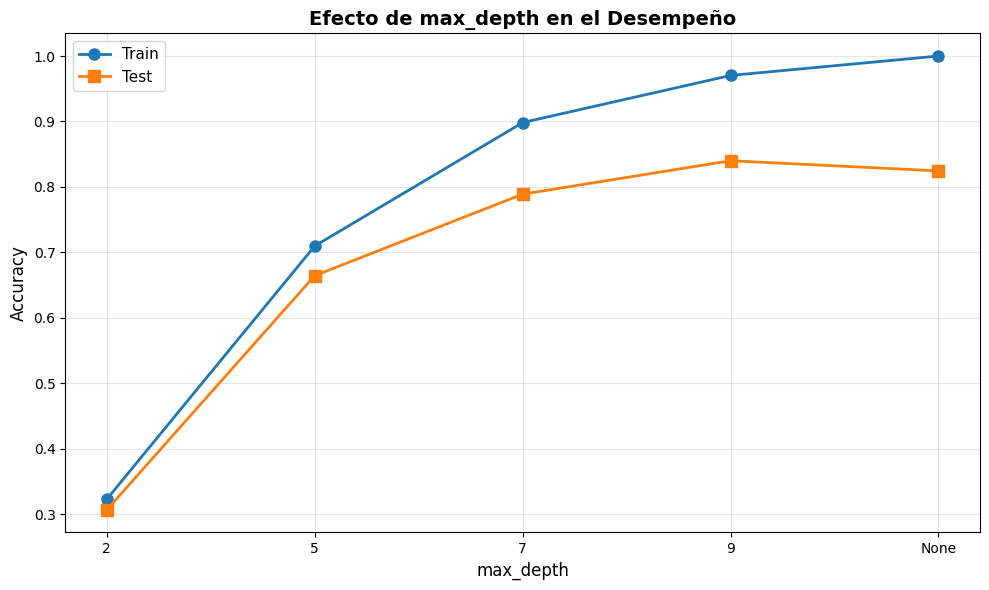


💡 OBSERVACIONES:
   • depth=2: Subajuste (modelo muy simple)
   • depth=10: Buen balance
   • depth=None: Sobreajuste (100% en train, peor en test)



In [ ]:
# ============================================================================
# SECCIÓN 4: EFECTO DE LOS HIPERPARÁMETROS (VISUALIZACIÓN)
# ============================================================================
print("\n" + "="*80)
print("SECCIÓN 4: EFECTO DE LOS HIPERPARÁMETROS")
print("="*80)

print("""
📚 HIPERPARÁMETROS CLAVE:

1️⃣ max_depth (Profundidad Máxima)
   • Controla cuántas "preguntas" puede hacer el árbol
   • Muy alto → sobreajuste (memoriza ruido)
   • Muy bajo → subajuste (demasiado simple)

2️⃣ min_samples_split (Mínimo para dividir)
   • Evita divisiones con muy pocos datos
   • ↑ valor → árbol más simple

3️⃣ min_samples_leaf (Mínimo en hoja)
   • Cada hoja debe tener mínimo N ejemplos
   • Suaviza probabilidades (evita 1/1 = 100%)

4️⃣ max_features (Variables por split)
   • Cuántas variables considera en cada división
   • Introduce aleatoriedad útil

5️⃣ ccp_alpha (Poda por complejidad)
   • Penaliza árboles grandes
   • Coste = Impureza + α × #hojas
""")

# Experimento: Efecto de max_depth
print("\n🔬 EXPERIMENTO: Efecto de max_depth")
depths = [2, 5, 7, 9, None]
train_scores = []
test_scores = []

for depth in depths:
    clf = DecisionTreeClassifier(max_depth=depth, random_state=42)
    clf.fit(X_train, y_train)
    train_scores.append(accuracy_score(y_train, clf.predict(X_train)))
    test_scores.append(accuracy_score(y_test, clf.predict(X_test)))

    print(f"   depth={str(depth):>4} → Train: {train_scores[-1]:.3f} | Test: {test_scores[-1]:.3f}")

max_features = [i for i in range(2, X.shape[1]+1)]
print("\n🔬 EXPERIMENTO: Efecto de max_features")
print(max_features)

train_scores_maxf = []
test_scores_maxf = []
for mf in max_features:
    clf = DecisionTreeClassifier(max_features=mf, random_state=42)
    clf.fit(X_train, y_train)
    train_scores_maxf.append(accuracy_score(y_train, clf.predict(X_train)))
    test_scores_maxf.append(accuracy_score(y_test, clf.predict(X_test)))
    print(f"   max_features={mf:>2} → Train: {train_scores_maxf[-1]:.3f} | Test: {test_scores_maxf[-1]:.3f}")
# Visualizar
plt.figure(figsize=(10, 6))
x_pos = range(len(depths))
plt.plot(x_pos, train_scores, 'o-', label='Train', linewidth=2, markersize=8)
plt.plot(x_pos, test_scores, 's-', label='Test', linewidth=2, markersize=8)
plt.xticks(x_pos, [str(d) for d in depths])
plt.xlabel('max_depth', fontsize=12)
plt.ylabel('Accuracy', fontsize=12)
plt.title('Efecto de max_depth en el Desempeño', fontsize=14, fontweight='bold')
plt.legend(fontsize=11)
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

print("""
💡 OBSERVACIONES:
   • depth=2: Subajuste (modelo muy simple)
   • depth=10: Buen balance
   • depth=None: Sobreajuste (100% en train, peor en test)
""")


# validación cruzada

In [30]:
# ============================================================================
# SECCIÓN 5: TIPOS DE VALIDACIÓN CRUZADA - GUÍA COMPLETA
# ============================================================================
print("\n" + "="*80)
print("SECCIÓN 5: TIPOS DE VALIDACIÓN CRUZADA")
print("="*80)

print("""
📚 ¿POR QUÉ VALIDACIÓN CRUZADA?

Problema: Un solo split train/test puede ser engañoso

Ejemplo: Tienes 100 datos, divides 80/20
   • Split 1: Test tiene casos fáciles → Accuracy 95% ✓
   • Split 2: Test tiene casos difíciles → Accuracy 70% ✗

¿Cuál refleja el verdadero desempeño? 🤔

SOLUCIÓN: Validación Cruzada
   • Múltiples splits para promediar resultados
   • Estimación más robusta y confiable
   • Menos dependencia de la "suerte"
""")



SECCIÓN 5: TIPOS DE VALIDACIÓN CRUZADA

📚 ¿POR QUÉ VALIDACIÓN CRUZADA?

Problema: Un solo split train/test puede ser engañoso

Ejemplo: Tienes 100 datos, divides 80/20
   • Split 1: Test tiene casos fáciles → Accuracy 95% ✓
   • Split 2: Test tiene casos difíciles → Accuracy 70% ✗

¿Cuál refleja el verdadero desempeño? 🤔

SOLUCIÓN: Validación Cruzada
   • Múltiples splits para promediar resultados
   • Estimación más robusta y confiable
   • Menos dependencia de la "suerte"



In [31]:
# ============================================================================
# 5.1 HOLD-OUT VALIDATION (Train/Test Split Simple)
# ============================================================================
print("\n" + "─"*80)
print("5.1 HOLD-OUT VALIDATION (Train/Test Split)")
print("─"*80)

print("""
📊 CONCEPTO:
   División única en conjunto de entrenamiento y prueba

   Visualización:
   [████████████████████████]░░░░░░  ← Dataset completo (100%)
   [████ TRAIN (70-80%) ████][TEST]  ← División
                              (20-30%)

   Entrenamiento: 1 sola vez en TRAIN
   Evaluación: 1 sola vez en TEST

🎯 CARACTERÍSTICAS:
   • Más simple y rápido
   • Una sola división aleatoria
   • Resultados pueden variar según el split

✅ VENTAJAS:
   • Muy rápido (entrena 1 vez)
   • Ideal para datasets grandes (>100k muestras)
   • Bueno para exploración inicial

⚠️ DESVENTAJAS:
   • Alta varianza (depende del split)
   • Desperdicia datos (no usa todo para entrenar)
   • Puede dar estimaciones poco confiables en datasets pequeños

📌 CUÁNDO USAR:
   • Exploración rápida de modelos
   • Datasets muy grandes (>100,000 muestras)
   • Cuando el tiempo de cómputo es crítico
   • Fase inicial de desarrollo
""")

# Ejemplo práctico
print("\n🔬 EJEMPLO PRÁCTICO:")
from sklearn.model_selection import train_test_split

# Simular múltiples splits para mostrar variabilidad
print("   Simulando 5 splits diferentes del mismo dataset...")
holdout_scores = []
for i in range(5):
    X_h_train, X_h_test, y_h_train, y_h_test = train_test_split(
        X_train, y_train, test_size=0.25, random_state=i
    )
    clf_h = DecisionTreeClassifier(max_depth=10, random_state=42)
    clf_h.fit(X_h_train, y_h_train)
    score = f1_score(y_h_test, clf_h.predict(X_h_test), average='macro')
    holdout_scores.append(score)
    print(f"   Split {i+1} (seed={i}): F1-macro = {score:.4f}")

print(f"""
   📊 Variabilidad observada:
   • Promedio: {np.mean(holdout_scores):.4f}
   • Desviación: {np.std(holdout_scores):.4f}
   • Rango: [{min(holdout_scores):.4f}, {max(holdout_scores):.4f}]

   ⚠️  ¡Diferencia de hasta {(max(holdout_scores)-min(holdout_scores)):.4f} puntos!
   💡 Por eso necesitamos métodos más robustos...
""")


────────────────────────────────────────────────────────────────────────────────
5.1 HOLD-OUT VALIDATION (Train/Test Split)
────────────────────────────────────────────────────────────────────────────────

📊 CONCEPTO:
   División única en conjunto de entrenamiento y prueba

   Visualización:
   [████████████████████████]░░░░░░  ← Dataset completo (100%)
   [████ TRAIN (70-80%) ████][TEST]  ← División
                              (20-30%)

   Entrenamiento: 1 sola vez en TRAIN
   Evaluación: 1 sola vez en TEST

🎯 CARACTERÍSTICAS:
   • Más simple y rápido
   • Una sola división aleatoria
   • Resultados pueden variar según el split

✅ VENTAJAS:
   • Muy rápido (entrena 1 vez)
   • Ideal para datasets grandes (>100k muestras)
   • Bueno para exploración inicial

⚠️ DESVENTAJAS:
   • Alta varianza (depende del split)
   • Desperdicia datos (no usa todo para entrenar)
   • Puede dar estimaciones poco confiables en datasets pequeños

📌 CUÁNDO USAR:
   • Exploración rápida de modelos
   • D

In [32]:
# ============================================================================
# 5.2 K-FOLD CROSS-VALIDATION
# ============================================================================
print("\n" + "─"*80)
print("5.2 K-FOLD CROSS-VALIDATION")
print("─"*80)

print("""
📊 CONCEPTO:
   Divide el dataset en K partes (folds) iguales
   Entrena K veces, cada vez usando un fold diferente para test

   Ejemplo con K=5:

   Iteración 1: [TEST][████][████][████][████]  ← Fold 1 es test
   Iteración 2: [████][TEST][████][████][████]  ← Fold 2 es test
   Iteración 3: [████][████][TEST][████][████]  ← Fold 3 es test
   Iteración 4: [████][████][████][TEST][████]  ← Fold 4 es test
   Iteración 5: [████][████][████][████][TEST]  ← Fold 5 es test

   Resultado final = Promedio de 5 evaluaciones

🎯 CARACTERÍSTICAS:
   • Cada muestra aparece exactamente 1 vez en test
   • Usa todos los datos tanto para train como para test
   • K entrenamientos y evaluaciones

✅ VENTAJAS:
   • Estimación más confiable que hold-out
   • Usa todos los datos eficientemente
   • Reduce el efecto de splits "afortunados/desafortunados"
   • Balance entre sesgo y varianza

⚠️ DESVENTAJAS:
   • K veces más costoso que hold-out
   • Puede no preservar distribución de clases

📌 CUÁNDO USAR:
   • Datasets de tamaño mediano (1k-100k muestras)
   • Regresión (donde distribución no importa tanto)
   • Cuando necesitas estimación robusta
   • K típico: 5 o 10

🔢 CÓMO ELEGIR K:
   • K=5: Balance entre costo y confiabilidad (más común)
   • K=10: Más confiable pero más costoso
   • K pequeño (3): Rápido pero menos preciso
   • K grande (20): Muy preciso pero muy costoso
""")

# Ejemplo práctico
print("\n🔬 EJEMPLO PRÁCTICO con K=5:")
from sklearn.model_selection import KFold

kfold = KFold(n_splits=5, shuffle=True, random_state=42)
kfold_scores = cross_val_score(
    DecisionTreeClassifier(max_depth=10, random_state=42),
    X_train, y_train, cv=kfold, scoring='f1_macro'
)

print("\n   Resultados por fold:")
for i, score in enumerate(kfold_scores, 1):
    print(f"   Fold {i}: F1-macro = {score:.4f}")

print(f"""
   📊 Resumen K-Fold (K=5):
   • Promedio: {kfold_scores.mean():.4f}
   • Desviación: {kfold_scores.std():.4f}
   • Intervalo confianza 95%: [{kfold_scores.mean()-1.96*kfold_scores.std():.4f},
     {kfold_scores.mean()+1.96*kfold_scores.std():.4f}]

   💡 Mucho más estable que hold-out simple
""")


────────────────────────────────────────────────────────────────────────────────
5.2 K-FOLD CROSS-VALIDATION
────────────────────────────────────────────────────────────────────────────────

📊 CONCEPTO:
   Divide el dataset en K partes (folds) iguales
   Entrena K veces, cada vez usando un fold diferente para test

   Ejemplo con K=5:

   Iteración 1: [TEST][████][████][████][████]  ← Fold 1 es test
   Iteración 2: [████][TEST][████][████][████]  ← Fold 2 es test
   Iteración 3: [████][████][TEST][████][████]  ← Fold 3 es test
   Iteración 4: [████][████][████][TEST][████]  ← Fold 4 es test
   Iteración 5: [████][████][████][████][TEST]  ← Fold 5 es test

   Resultado final = Promedio de 5 evaluaciones

🎯 CARACTERÍSTICAS:
   • Cada muestra aparece exactamente 1 vez en test
   • Usa todos los datos tanto para train como para test
   • K entrenamientos y evaluaciones

✅ VENTAJAS:
   • Estimación más confiable que hold-out
   • Usa todos los datos eficientemente
   • Reduce el efecto de 

In [33]:
# ============================================================================
# 5.3 STRATIFIED K-FOLD CROSS-VALIDATION
# ============================================================================
print("\n" + "─"*80)
print("5.3 STRATIFIED K-FOLD CROSS-VALIDATION ⭐ RECOMENDADO")
print("─"*80)

print("""
📊 CONCEPTO:
   Como K-Fold pero PRESERVA la proporción de cada clase en cada fold

   Ejemplo: Dataset con 70% clase A, 30% clase B

   K-Fold normal:
   Fold 1: [50% A, 50% B]  ← ¡No refleja distribución real!
   Fold 2: [80% A, 20% B]
   Fold 3: [65% A, 35% B]

   Stratified K-Fold:
   Fold 1: [70% A, 30% B]  ← ✓ Mantiene proporciones
   Fold 2: [70% A, 30% B]  ← ✓ Mantiene proporciones
   Fold 3: [70% A, 30% B]  ← ✓ Mantiene proporciones

🎯 CARACTERÍSTICAS:
   • Garantiza representación proporcional de cada clase
   • Especialmente importante con clases desbalanceadas
   • Cada fold es "representativo" del dataset completo

✅ VENTAJAS:
   • Resultados más confiables en clasificación
   • Fundamental con clases desbalanceadas
   • Evita folds sin alguna clase
   • Reduce varianza entre folds

⚠️ DESVENTAJAS:
   • Solo para clasificación (no regresión)
   • Ligeramente más complejo que K-Fold

📌 CUÁNDO USAR:
   • ⭐ SIEMPRE en clasificación (úsalo por defecto)
   • Especialmente crítico con clases desbalanceadas
   • Cuando algunas clases son raras (<5%)
   • Multiclase con distribuciones variadas

💡 EJEMPLO CRÍTICO:
   Imagina 100 datos: 95 negativos, 5 positivos (fraude)

   K-Fold normal podría crear:
   • Fold 1: 20 negativos, 0 positivos  ← ¡NO aprende positivos!
   • Fold 2: 20 negativos, 0 positivos
   • Fold 3: 15 negativos, 5 positivos  ← Todos los positivos juntos

   Stratified K-Fold garantiza:
   • Fold 1: 19 negativos, 1 positivo  ← ✓ Representativo
   • Fold 2: 19 negativos, 1 positivo  ← ✓ Representativo
   • Fold 3: 19 negativos, 1 positivo  ← ✓ Representativo
""")

# Ejemplo práctico con comparación
print("\n🔬 COMPARACIÓN: K-Fold vs Stratified K-Fold")

# Crear dataset desbalanceado artificial
from sklearn.datasets import make_classification
X_deseq, y_deseq = make_classification(
    n_samples=1000, n_features=20, n_classes=3,
    n_informative=15, n_redundant=5,
    weights=[0.7, 0.2, 0.1],  # Desbalanceado: 70%, 20%, 10%
    random_state=42
)

print(f"\n   Dataset desbalanceado: {np.bincount(y_deseq)} muestras")
print(f"   Distribución: {np.bincount(y_deseq)/len(y_deseq)*100}")

# K-Fold normal
print("\n   📊 K-FOLD NORMAL:")
kf_normal = KFold(n_splits=5, shuffle=True, random_state=42)
for i, (train_idx, test_idx) in enumerate(kf_normal.split(X_deseq), 1):
    dist = np.bincount(y_deseq[test_idx], minlength=3)
    print(f"   Fold {i} test: {dist} → {(dist/len(test_idx)*100).astype(int)}%")

# Stratified K-Fold
print("\n   📊 STRATIFIED K-FOLD:")
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
for i, (train_idx, test_idx) in enumerate(skf.split(X_deseq, y_deseq), 1):
    dist = np.bincount(y_deseq[test_idx], minlength=3)
    print(f"   Fold {i} test: {dist} → {(dist/len(test_idx)*100).astype(int)}%")

print("""
   💡 Observa cómo Stratified mantiene las proporciones constantes!
""")

# Aplicar en nuestro dataset digits
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
strat_scores = cross_val_score(
    DecisionTreeClassifier(max_depth=10, random_state=42),
    X_train, y_train, cv=cv, scoring='f1_macro'
)

print("\n🔬 APLICACIÓN EN DIGITS (Stratified K-Fold):")
print("\n   Resultados por fold:")
for i, score in enumerate(strat_scores, 1):
    print(f"   Fold {i}: F1-macro = {score:.4f}")

print(f"""
   📊 RESUMEN:
   • F1-macro promedio: {strat_scores.mean():.4f}
   • Desviación estándar: {strat_scores.std():.4f}
   • Rango: [{strat_scores.min():.4f}, {strat_scores.max():.4f}]

   ✓ Resultado más confiable y representativo
""")


────────────────────────────────────────────────────────────────────────────────
5.3 STRATIFIED K-FOLD CROSS-VALIDATION ⭐ RECOMENDADO
────────────────────────────────────────────────────────────────────────────────

📊 CONCEPTO:
   Como K-Fold pero PRESERVA la proporción de cada clase en cada fold

   Ejemplo: Dataset con 70% clase A, 30% clase B

   K-Fold normal:
   Fold 1: [50% A, 50% B]  ← ¡No refleja distribución real!
   Fold 2: [80% A, 20% B]
   Fold 3: [65% A, 35% B]

   Stratified K-Fold:
   Fold 1: [70% A, 30% B]  ← ✓ Mantiene proporciones
   Fold 2: [70% A, 30% B]  ← ✓ Mantiene proporciones
   Fold 3: [70% A, 30% B]  ← ✓ Mantiene proporciones

🎯 CARACTERÍSTICAS:
   • Garantiza representación proporcional de cada clase
   • Especialmente importante con clases desbalanceadas
   • Cada fold es "representativo" del dataset completo

✅ VENTAJAS:
   • Resultados más confiables en clasificación
   • Fundamental con clases desbalanceadas
   • Evita folds sin alguna clase
   • Reduce


────────────────────────────────────────────────────────────────────────────────
5.6 MONTE CARLO CROSS-VALIDATION (Shuffle-Split)
────────────────────────────────────────────────────────────────────────────────

📊 CONCEPTO:
   Repite splits aleatorios train/test múltiples veces
   Como hacer hold-out repetidamente con diferentes seeds

   Visualización (10 iteraciones):

   Split 1: [████████████]░░░░░  80% train, 20% test (aleatorio)
   Split 2: [████████████]░░░░░  80% train, 20% test (diferente split)
   Split 3: [████████████]░░░░░  80% train, 20% test (diferente split)
   ...
   Split 10: [████████████]░░░░░  80% train, 20% test (diferente split)

   ⚠️  Una muestra puede aparecer en test 0, 1 o múltiples veces

🎯 CARACTERÍSTICAS:
   • N iteraciones con splits aleatorios independientes
   • Flexibilidad en tamaño de train/test
   • Las muestras pueden repetirse o no aparecer

✅ VENTAJAS:
   • Control total sobre número de iteraciones
   • Puedes elegir proporción train/test libre

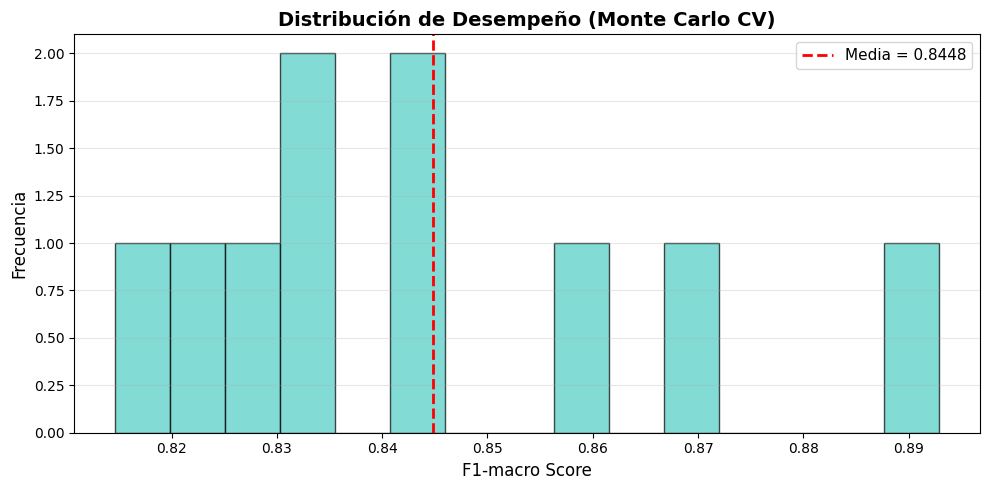

In [34]:
# ============================================================================
# 5.4 MONTE CARLO CROSS-VALIDATION (SHUFFLE-SPLIT)
# ============================================================================
print("\n" + "─"*80)
print("5.6 MONTE CARLO CROSS-VALIDATION (Shuffle-Split)")
print("─"*80)

print("""
📊 CONCEPTO:
   Repite splits aleatorios train/test múltiples veces
   Como hacer hold-out repetidamente con diferentes seeds

   Visualización (10 iteraciones):

   Split 1: [████████████]░░░░░  80% train, 20% test (aleatorio)
   Split 2: [████████████]░░░░░  80% train, 20% test (diferente split)
   Split 3: [████████████]░░░░░  80% train, 20% test (diferente split)
   ...
   Split 10: [████████████]░░░░░  80% train, 20% test (diferente split)

   ⚠️  Una muestra puede aparecer en test 0, 1 o múltiples veces

🎯 CARACTERÍSTICAS:
   • N iteraciones con splits aleatorios independientes
   • Flexibilidad en tamaño de train/test
   • Las muestras pueden repetirse o no aparecer

✅ VENTAJAS:
   • Control total sobre número de iteraciones
   • Puedes elegir proporción train/test libremente
   • Más rápido que K-Fold para mismas iteraciones
   • Útil para obtener distribución de desempeño

⚠️ DESVENTAJAS:
   • Las muestras no aparecen uniformemente
   • Pueden haber traslapes entre train/test de diferentes splits
   • Menos eficiente en uso de datos que K-Fold

📌 CUÁNDO USAR:
   • Quieres una distribución de desempeños
   • Necesitas control fino sobre tamaño de splits
   • Datasets grandes donde el traslape no importa
   • Cuando K-Fold es demasiado rígido
   • Para estimar intervalos de confianza

⚙️ PARÁMETROS CLAVE:
   • n_splits: Número de iteraciones (típico: 10-100)
   • test_size: Proporción para test (típico: 0.2-0.3)
   • train_size: Proporción para train (opcional)
""")

# Ejemplo práctico
print("\n🔬 EJEMPLO PRÁCTICO (10 splits aleatorios):")
from sklearn.model_selection import ShuffleSplit

shuffle_split = ShuffleSplit(n_splits=10, test_size=0.25, random_state=42)
mc_scores = cross_val_score(
    DecisionTreeClassifier(max_depth=10, random_state=42),
    X_train, y_train, cv=shuffle_split, scoring='f1_macro'
)

print("\n   Resultados por iteración:")
for i, score in enumerate(mc_scores, 1):
    print(f"   Split {i:2d}: F1-macro = {score:.4f}")

print(f"""
   📊 Resumen Monte Carlo (10 splits):
   • Promedio: {mc_scores.mean():.4f}
   • Desviación: {mc_scores.std():.4f}
   • Rango: [{mc_scores.min():.4f}, {mc_scores.max():.4f}]

   💡 Útil para estimar variabilidad del modelo
""")

# Visualizar distribución
plt.figure(figsize=(10, 5))
plt.hist(mc_scores, bins=15, edgecolor='black', alpha=0.7, color='#4ECDC4')
plt.axvline(mc_scores.mean(), color='red', linestyle='--', linewidth=2,
            label=f'Media = {mc_scores.mean():.4f}')
plt.xlabel('F1-macro Score', fontsize=12)
plt.ylabel('Frecuencia', fontsize=12)
plt.title('Distribución de Desempeño (Monte Carlo CV)', fontsize=14, fontweight='bold')
plt.legend(fontsize=11)
plt.grid(alpha=0.3, axis='y')
plt.tight_layout()
plt.show()


In [17]:
# ============================================================================
# 5.5 TIME SERIES CROSS-VALIDATION (Rolling/Expanding Window)
# ============================================================================
print("\n" + "─"*80)
print("5.7 TIME SERIES CROSS-VALIDATION")
print("─"*80)

print("""
📊 CONCEPTO:
   RESPETA el orden temporal de los datos
   Nunca entrena con datos futuros para predecir el pasado

   ⚠️  CRÍTICO: En series de tiempo NO puedes mezclar aleatoriamente!

   Ejemplo INCORRECTO (K-Fold normal):
   2020 [test] 2021 [train] 2022 [train] 2023 [train]
   ↑ Predice 2020 usando datos de 2021-2023 ← ¡Data leakage!

   Ejemplo CORRECTO (Time Series CV):

   ROLLING WINDOW (ventana fija):
   Split 1: [████████][-test-]                 2020-2021 → pred 2022
   Split 2:     [████████][-test-]             2021-2022 → pred 2023
   Split 3:         [████████][-test-]         2022-2023 → pred 2024

   EXPANDING WINDOW (ventana creciente):
   Split 1: [████][-test-]                     2020 → pred 2021
   Split 2: [████████][-test-]                 2020-2021 → pred 2022
   Split 3: [████████████][-test-]             2020-2022 → pred 2023
   Split 4: [████████████████][-test-]         2020-2023 → pred 2024

🎯 CARACTERÍSTICAS:
   • Mantiene orden cronológico
   • Train siempre está ANTES de test
   • Simula predicción real hacia el futuro

✅ VENTAJAS:
   • Evita data leakage temporal
   • Realista para series de tiempo
   • Valida capacidad de generalización futura

⚠️ DESVENTAJAS:
   • Solo para datos temporales
   • Menos datos en primeros splits (expanding)
   • Puede ser sensible a cambios de tendencia

📌 CUÁNDO USAR (OBLIGATORIO):
   • Series de tiempo (ventas, stocks, clima, etc.)
   • Datos secuenciales (logs, transacciones)
   • Cuando el orden importa
   • Predicción de demanda, precios, etc.

🚫 NUNCA uses K-Fold o Stratified en series de tiempo:
   → Causan data leakage (usar futuro para predecir pasado)
   → Resultados optimistas pero inútiles en producción

⚙️ TIPOS:
   • TimeSeriesSplit: Expanding window (sklearn)
   • Custom rolling window: Ventana fija que se mueve
""")

# Ejemplo ilustrativo (datos sintéticos temporales)
print("\n🔬 EJEMPLO con datos temporales simulados:")
from sklearn.model_selection import TimeSeriesSplit

# Crear serie temporal sintética
np.random.seed(42)
n_temporal = 200
X_temporal = np.random.randn(n_temporal, 10)
# Agregar tendencia temporal
y_temporal = (np.arange(n_temporal) % 10).astype(int)  # Patrón cíclico

tscv = TimeSeriesSplit(n_splits=5)

print(f"\n   Dataset temporal: {n_temporal} observaciones ordenadas")
print("\n   Estructura de los splits (expanding window):\n")

for i, (train_idx, test_idx) in enumerate(tscv.split(X_temporal), 1):
    print(f"   Split {i}:")
    print(f"      Train: índices {train_idx[0]:3d} a {train_idx[-1]:3d} ({len(train_idx):3d} muestras)")
    print(f"      Test:  índices {test_idx[0]:3d} a {test_idx[-1]:3d} ({len(test_idx):2d} muestras)")

# Aplicar CV temporal
ts_scores = cross_val_score(
    DecisionTreeClassifier(max_depth=5, random_state=42),
    X_temporal, y_temporal, cv=tscv, scoring='f1_macro'
)

print("\n   📊 Resultados por split temporal:")
for i, score in enumerate(ts_scores, 1):
    print(f"   Split {i}: F1-macro = {score:.4f}")

print(f"""
   Promedio: {ts_scores.mean():.4f} ± {ts_scores.std():.4f}

   💡 Observa cómo el tamaño de train crece en cada split
   ⚠️  NUNCA uses K-Fold normal en series de tiempo!
""")


────────────────────────────────────────────────────────────────────────────────
5.7 TIME SERIES CROSS-VALIDATION
────────────────────────────────────────────────────────────────────────────────

📊 CONCEPTO:
   RESPETA el orden temporal de los datos
   Nunca entrena con datos futuros para predecir el pasado

   ⚠️  CRÍTICO: En series de tiempo NO puedes mezclar aleatoriamente!

   Ejemplo INCORRECTO (K-Fold normal):
   2020 [test] 2021 [train] 2022 [train] 2023 [train]
   ↑ Predice 2020 usando datos de 2021-2023 ← ¡Data leakage!

   Ejemplo CORRECTO (Time Series CV):

   ROLLING WINDOW (ventana fija):
   Split 1: [████████][-test-]                 2020-2021 → pred 2022
   Split 2:     [████████][-test-]             2021-2022 → pred 2023
   Split 3:         [████████][-test-]         2022-2023 → pred 2024

   EXPANDING WINDOW (ventana creciente):
   Split 1: [████][-test-]                     2020 → pred 2021
   Split 2: [████████][-test-]                 2020-2021 → pred 2022
   Split

In [35]:
# ============================================================================
# 5.6 TABLA COMPARATIVA Y GUÍA DE DECISIÓN
# ============================================================================
print("\n" + "="*80)
print("5.8 COMPARACIÓN Y GUÍA DE DECISIÓN")
print("="*80)

print("""
┌────────────────────┬────────────┬──────────────┬────────────┬─────────────────────┐
│ MÉTODO             │ # ENTRENA. │ USO DE DATOS │ COSTO      │ CUÁNDO USAR         │
├────────────────────┼────────────┼──────────────┼────────────┼─────────────────────┤
│ Hold-Out           │     1      │    Bajo      │   Bajo     │ Exploración rápida  │
│                    │            │    (70-80%)  │            │ Datasets grandes    │
├────────────────────┼────────────┼──────────────┼────────────┼─────────────────────┤
│ K-Fold             │     K      │    Alto      │   Medio    │ Regresión           │
│ (K=5,10)           │   (5-10)   │    (100%)    │            │ Clasificación       │
│                    │            │              │            │ balanceada          │
├────────────────────┼────────────┼──────────────┼────────────┼─────────────────────┤
│ Stratified K-Fold  │     K      │    Alto      │   Medio    │ ⭐ CLASIFICACIÓN    │
│ ⭐ RECOMENDADO     │   (5-10)   │    (100%)    │            │ (por defecto)       │
├────────────────────┼────────────┼──────────────┼────────────┼─────────────────────┤
│ LOOCV              │     N      │   Máximo     │  Muy Alto  │ N < 100 muestras    │
│                    │            │   (N-1)/N    │            │ Datos escasos       │
├────────────────────┼────────────┼──────────────┼────────────┼─────────────────────┤
│ Leave-P-Out        │   C(N,P)   │   Máximo     │ Prohibitivo│ Casi nunca          │
│                    │ (explosivo)│              │            │ (solo teoría)       │
├────────────────────┼────────────┼──────────────┼────────────┼─────────────────────┤
│ Monte Carlo        │ Configura- │    Medio     │   Medio    │ Distribución        │
│ (Shuffle-Split)    │    ble     │   (variable) │            │ desempeños          │
├────────────────────┼────────────┼──────────────┼────────────┼─────────────────────┤
│ Time Series CV     │     K      │    Alto      │   Medio    │ ⚠️ SERIES TIEMPO   │
│ ⚠️ OBLIGATORIO     │   (3-10)   │    (100%)    │            │ (obligatorio)       │
└────────────────────┴────────────┴──────────────┴────────────┴─────────────────────┘

🎯 ÁRBOL DE DECISIÓN PARA ELEGIR:

¿Datos temporales/secuenciales?
├─ SÍ → Time Series CV (expanding/rolling window)
└─ NO → ¿Qué tipo de problema?
         ├─ Clasificación → Stratified K-Fold (K=5 o 10) ⭐
         ├─ Regresión → K-Fold (K=5 o 10)
         └─ ¿Consideraciones especiales?
              ├─ Muy pocos datos (N<100) → LOOCV
              ├─ Dataset enorme (>100k) → Hold-out
              ├─ Necesitas distribución → Monte Carlo
              └─ Clases desbalanceadas → Stratified K-Fold ⭐

📊 RECOMENDACIONES POR ESCENARIO:

1️⃣ CLASIFICACIÓN GENERAL (default):
   → Stratified K-Fold con K=5
   → Garantiza representación de todas las clases

2️⃣ REGRESIÓN GENERAL:
   → K-Fold con K=5 o 10
   → Sin necesidad de estratificar

3️⃣ CLASES MUY DESBALANCEADAS:
   → Stratified K-Fold con K=5
   → Considerar métricas macro (F1-macro)

4️⃣ DATOS ESCASOS (N < 100):
   → LOOCV (si el costo lo permite)
   → O Stratified K-Fold con K=N/10

5️⃣ DATASETS GRANDES (N > 100,000):
   → Hold-out (80/20 o 70/30)
   → Validación rápida

6️⃣ SERIES DE TIEMPO:
   → Time Series Split (expanding window)
   → NUNCA K-Fold normal

7️⃣ COMPETENCIAS/INVESTIGACIÓN:
   → Combinar varios métodos
   → Reportar múltiples CV
""")


5.8 COMPARACIÓN Y GUÍA DE DECISIÓN

┌────────────────────┬────────────┬──────────────┬────────────┬─────────────────────┐
│ MÉTODO             │ # ENTRENA. │ USO DE DATOS │ COSTO      │ CUÁNDO USAR         │
├────────────────────┼────────────┼──────────────┼────────────┼─────────────────────┤
│ Hold-Out           │     1      │    Bajo      │   Bajo     │ Exploración rápida  │
│                    │            │    (70-80%)  │            │ Datasets grandes    │
├────────────────────┼────────────┼──────────────┼────────────┼─────────────────────┤
│ K-Fold             │     K      │    Alto      │   Medio    │ Regresión           │
│ (K=5,10)           │   (5-10)   │    (100%)    │            │ Clasificación       │
│                    │            │              │            │ balanceada          │
├────────────────────┼────────────┼──────────────┼────────────┼─────────────────────┤
│ Stratified K-Fold  │     K      │    Alto      │   Medio    │ ⭐ CLASIFICACIÓN    │
│ ⭐ RECOMENDADO   


────────────────────────────────────────────────────────────────────────────────
5.9 COMPARACIÓN VISUAL DE MÉTODOS
────────────────────────────────────────────────────────────────────────────────


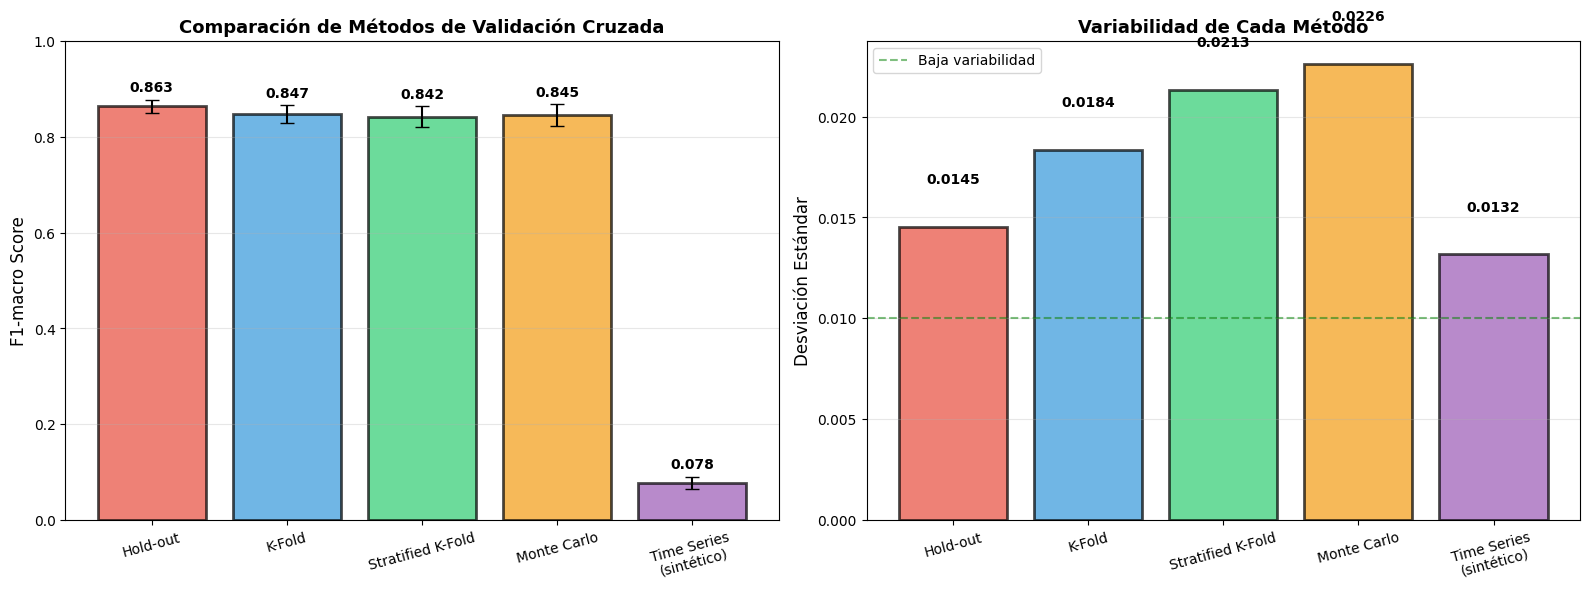


💡 INTERPRETACIÓN:
   • Menor desviación estándar = más confiable
   • K-Fold y Stratified suelen ser más estables
   • LOOCV puede tener alta variabilidad individual
   • Hold-out depende mucho del split específico



In [36]:
# ============================================================================
# 5.9 VISUALIZACIÓN COMPARATIVA
# ============================================================================
print("\n" + "─"*80)
print("5.9 COMPARACIÓN VISUAL DE MÉTODOS")
print("─"*80)

# Recopilar todos los resultados
methods_comparison = {
    'Hold-out': np.mean(holdout_scores),
    'K-Fold': kfold_scores.mean(),
    'Stratified K-Fold': strat_scores.mean(),

    'Monte Carlo': mc_scores.mean(),
    'Time Series\n(sintético)': ts_scores.mean()
}

methods_std = {
    'Hold-out': np.std(holdout_scores),
    'K-Fold': kfold_scores.std(),
    'Stratified K-Fold': strat_scores.std(),

    'Monte Carlo': mc_scores.std(),
    'Time Series\n(sintético)': ts_scores.std()
}

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Gráfico 1: Comparación de promedios con barras de error
ax1 = axes[0]
methods = list(methods_comparison.keys())
means = list(methods_comparison.values())
stds = list(methods_std.values())
colors = ['#E74C3C', '#3498DB', '#2ECC71', '#F39C12', '#9B59B6', '#1ABC9C']

bars = ax1.bar(methods, means, yerr=stds, capsize=5,
               color=colors, edgecolor='black', linewidth=2, alpha=0.7)

# Añadir valores
for bar, mean, std in zip(bars, means, stds):
    height = bar.get_height()
    ax1.text(bar.get_x() + bar.get_width()/2., height + std + 0.01,
            f'{mean:.3f}',
            ha='center', va='bottom', fontsize=10, fontweight='bold')

ax1.set_ylabel('F1-macro Score', fontsize=12)
ax1.set_title('Comparación de Métodos de Validación Cruzada',
             fontsize=13, fontweight='bold')
ax1.set_ylim([0, 1.0])
ax1.grid(alpha=0.3, axis='y')
ax1.tick_params(axis='x', rotation=15)

# Gráfico 2: Variabilidad (desviación estándar)
ax2 = axes[1]
bars2 = ax2.bar(methods, stds, color=colors, edgecolor='black',
                linewidth=2, alpha=0.7)

for bar, std in zip(bars2, stds):
    height = bar.get_height()
    ax2.text(bar.get_x() + bar.get_width()/2., height + 0.002,
            f'{std:.4f}',
            ha='center', va='bottom', fontsize=10, fontweight='bold')

ax2.set_ylabel('Desviación Estándar', fontsize=12)
ax2.set_title('Variabilidad de Cada Método', fontsize=13, fontweight='bold')
ax2.grid(alpha=0.3, axis='y')
ax2.tick_params(axis='x', rotation=15)
ax2.axhline(0.01, color='green', linestyle='--', alpha=0.5, label='Baja variabilidad')
ax2.legend(fontsize=10)

plt.tight_layout()
plt.show()

print("""
💡 INTERPRETACIÓN:
   • Menor desviación estándar = más confiable
   • K-Fold y Stratified suelen ser más estables
   • LOOCV puede tener alta variabilidad individual
   • Hold-out depende mucho del split específico
""")


5.10 EJEMPLO PRÁCTICO: SELECCIÓN DEL MÉTODO APROPIADO

🎯 ESCENARIO: Optimizando hiperparámetros de árbol de decisión

PREGUNTA: ¿Qué método de CV usar para evaluar hiperparámetros?

Consideraciones:
  • Dataset: DIGITS (clasificación multiclase)
  • Tamaño: 1347 muestras (mediano)
  • Clases: 10 dígitos (relativamente balanceadas)
  • Objetivo: Optimizar hiperparámetros con confianza

DECISIÓN: Stratified K-Fold con K=5 ✓

¿POR QUÉ?
  ✓ Clasificación → Necesita estratificación
  ✓ Tamaño mediano → K-Fold es eficiente
  ✓ 10 clases → Garantiza representación en cada fold
  ✓ K=5 → Balance entre costo y confiabilidad
  ✗ Hold-out → Muy variable para optimización
  ✗ LOOCV → Demasiado costoso (1347 entrenamientos)
  ✗ Time Series CV → No es serie temporal


🔬 APLICACIÓN PRÁCTICA:

   Evaluando diferentes profundidades con Stratified 5-Fold CV...
   max_depth= 3: 0.3924 ± 0.0142 [0.3725, 0.4076]
   max_depth= 5: 0.6593 ± 0.0388 [0.6195, 0.7314]
   max_depth= 7: 0.8144 ± 0.0288 [0.7851, 0.

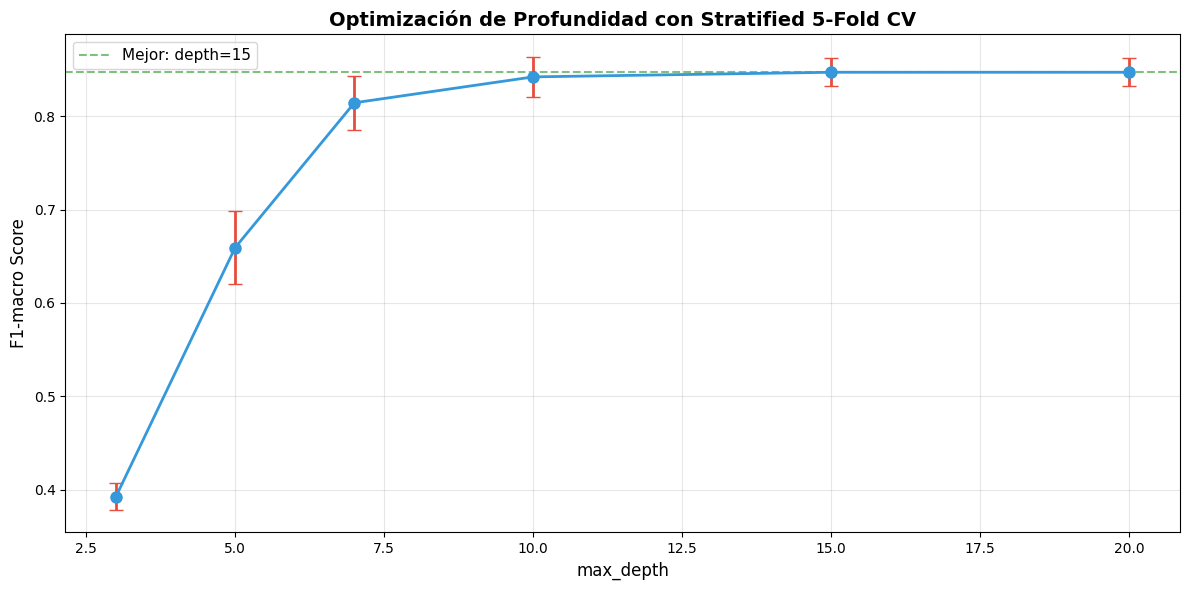

In [37]:
# ============================================================================
# 5.10 EJEMPLO PRÁCTICO INTEGRADO
# ============================================================================
print("\n" + "="*80)
print("5.10 EJEMPLO PRÁCTICO: SELECCIÓN DEL MÉTODO APROPIADO")
print("="*80)

print("""
🎯 ESCENARIO: Optimizando hiperparámetros de árbol de decisión

PREGUNTA: ¿Qué método de CV usar para evaluar hiperparámetros?

Consideraciones:
  • Dataset: DIGITS (clasificación multiclase)
  • Tamaño: 1347 muestras (mediano)
  • Clases: 10 dígitos (relativamente balanceadas)
  • Objetivo: Optimizar hiperparámetros con confianza

DECISIÓN: Stratified K-Fold con K=5 ✓

¿POR QUÉ?
  ✓ Clasificación → Necesita estratificación
  ✓ Tamaño mediano → K-Fold es eficiente
  ✓ 10 clases → Garantiza representación en cada fold
  ✓ K=5 → Balance entre costo y confiabilidad
  ✗ Hold-out → Muy variable para optimización
  ✗ LOOCV → Demasiado costoso (1347 entrenamientos)
  ✗ Time Series CV → No es serie temporal
""")

# Aplicación práctica
print("\n🔬 APLICACIÓN PRÁCTICA:")
print("\n   Evaluando diferentes profundidades con Stratified 5-Fold CV...")

depths_to_test = [3, 5, 7, 10, 15, 20]
cv_results = []

for depth in depths_to_test:
    clf_test = DecisionTreeClassifier(max_depth=depth, random_state=42)
    scores = cross_val_score(clf_test, X_train, y_train,
                            cv=cv, scoring='f1_macro')
    cv_results.append({
        'depth': depth,
        'mean': scores.mean(),
        'std': scores.std(),
        'min': scores.min(),
        'max': scores.max()
    })
    print(f"   max_depth={depth:2d}: {scores.mean():.4f} ± {scores.std():.4f} "
          f"[{scores.min():.4f}, {scores.max():.4f}]")

# Encontrar mejor profundidad
best_result = max(cv_results, key=lambda x: x['mean'])
print(f"""
   🏆 MEJOR CONFIGURACIÓN:
   • max_depth = {best_result['depth']}
   • F1-macro = {best_result['mean']:.4f} ± {best_result['std']:.4f}

   ✓ Resultado confiable gracias a Stratified K-Fold
""")

# Visualizar resultados
plt.figure(figsize=(12, 6))
depths = [r['depth'] for r in cv_results]
means = [r['mean'] for r in cv_results]
stds = [r['std'] for r in cv_results]

plt.errorbar(depths, means, yerr=stds, fmt='o-', capsize=5,
            linewidth=2, markersize=8, color='#3498DB', ecolor='#E74C3C')
plt.axhline(best_result['mean'], color='green', linestyle='--',
           alpha=0.5, label=f"Mejor: depth={best_result['depth']}")
plt.xlabel('max_depth', fontsize=12)
plt.ylabel('F1-macro Score', fontsize=12)
plt.title('Optimización de Profundidad con Stratified 5-Fold CV',
         fontsize=14, fontweight='bold')
plt.legend(fontsize=11)
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()


In [38]:
# ============================================================================
# 5.11 RESUMEN Y MEJORES PRÁCTICAS
# ============================================================================
print("\n" + "="*80)
print("RESUMEN: VALIDACIÓN CRUZADA - MEJORES PRÁCTICAS")
print("="*80)

print("""
🎓 LECCIONES CLAVE:

1️⃣ NUNCA confíes en un solo split train/test
   • Resultados pueden ser engañosos
   • Usa CV para estimación robusta

2️⃣ CLASIFICACIÓN → Stratified K-Fold (default)
   • Preserva distribución de clases
   • Especialmente crítico con desbalance

3️⃣ REGRESIÓN → K-Fold
   • Sin necesidad de estratificar
   • K=5 o K=10 son buenas opciones

4️⃣ SERIES DE TIEMPO → Time Series CV (obligatorio)
   • Respeta orden temporal
   • Evita data leakage

5️⃣ Reporta media Y desviación estándar
   • No solo el promedio
   • La variabilidad importa

6️⃣ K=5 vs K=10:
   • K=5: Más rápido, bueno para exploración
   • K=10: Más preciso, mejor para decisiones finales

━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

📋 CHECKLIST PARA TU PROYECTO:

□ ¿Es clasificación? → Usa Stratified K-Fold
□ ¿Es regresión? → Usa K-Fold
□ ¿Es serie temporal? → Usa Time Series CV
□ ¿Tienes <100 muestras? → Considera LOOCV
□ ¿Tienes >100k muestras? → Hold-out es suficiente
□ ¿Optimizando hiperparámetros? → K-Fold con K=5
□ ¿Decisión final? → K-Fold con K=10
□ Siempre reporta: media ± desviación estándar

━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

⚠️ ERRORES COMUNES A EVITAR:

❌ Usar K-Fold en series temporales
   → Causa data leakage, resultados inútiles

❌ No estratificar en clasificación desbalanceada
   → Algunos folds sin clases minoritarias

❌ Usar LOOCV en datasets grandes
   → Prohibitivamente costoso

❌ Reportar solo el promedio sin desviación
   → No sabes qué tan confiable es el resultado

❌ Optimizar hiperparámetros con hold-out simple
   → Puede sobreajustar al split específico

━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

🎯 REGLA DE ORO:

"Si tienes dudas, usa Stratified K-Fold con K=5.
 Funciona bien en el 90% de los casos de clasificación."

━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
""")

print("\n✅ Sección de Validación Cruzada completada!")
print("   Ahora sabes cómo elegir y aplicar el método apropiado para tu problema.\n")


RESUMEN: VALIDACIÓN CRUZADA - MEJORES PRÁCTICAS

🎓 LECCIONES CLAVE:

1️⃣ NUNCA confíes en un solo split train/test
   • Resultados pueden ser engañosos
   • Usa CV para estimación robusta

2️⃣ CLASIFICACIÓN → Stratified K-Fold (default)
   • Preserva distribución de clases
   • Especialmente crítico con desbalance

3️⃣ REGRESIÓN → K-Fold
   • Sin necesidad de estratificar
   • K=5 o K=10 son buenas opciones

4️⃣ SERIES DE TIEMPO → Time Series CV (obligatorio)
   • Respeta orden temporal
   • Evita data leakage

5️⃣ Reporta media Y desviación estándar
   • No solo el promedio
   • La variabilidad importa

6️⃣ K=5 vs K=10:
   • K=5: Más rápido, bueno para exploración
   • K=10: Más preciso, mejor para decisiones finales

━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

📋 CHECKLIST PARA TU PROYECTO:

□ ¿Es clasificación? → Usa Stratified K-Fold
□ ¿Es regresión? → Usa K-Fold
□ ¿Es serie temporal? → Usa Time Series CV
□ ¿Tienes <100 muestras? → Considera LOOCV
□ ¿Tienes 

# optmización de hiperparametros


SECCIÓN 6: GRID SEARCH - Búsqueda Exhaustiva

📚 ¿QUÉ ES GRID SEARCH?

Grid Search (Búsqueda en Grilla) prueba TODAS las combinaciones posibles
de hiperparámetros en una cuadrícula predefinida.

🎯 ANALOGÍA: Buscar un tesoro en un mapa cuadriculado

   Imagina que tienes un mapa 3×4 y el tesoro está en alguna casilla:

   max_depth →  5    10   15   20
              ┌────┬────┬────┬────┐
   criterion  │ 1  │ 2  │ 3  │ 4  │  gini
   ↓          ├────┼────┼────┼────┤
              │ 5  │ 6  │ 7  │ 8  │  entropy
              ├────┼────┼────┼────┤
              │ 9  │ 10 │ 11 │ 12 │  log_loss
              └────┴────┴────┴────┘

   Grid Search prueba las 12 casillas SISTEMÁTICAMENTE
   → Garantiza encontrar el mejor en esta grilla

🔍 PROCESO:

1. Defines un espacio discreto:
   • criterion: [gini, entropy, log_loss]
   • max_depth: [5, 10, 15, 20]

2. Se crean TODAS las combinaciones:
   (gini, 5), (gini, 10), (gini, 15), (gini, 20),
   (entropy, 5), (entropy, 10), ...
   Total: 3 × 4 = 12 

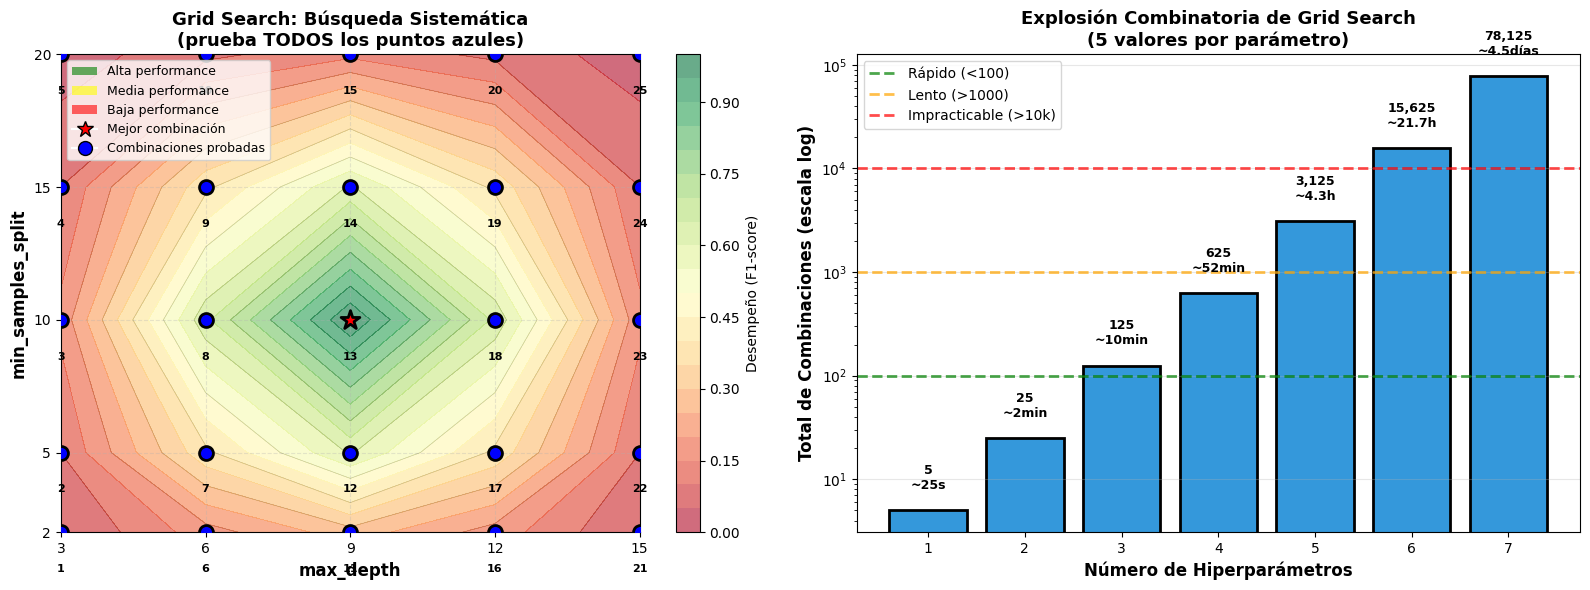


💡 INTERPRETACIÓN:

   Gráfico 1 (izquierda):
   • Cada punto azul = una combinación que Grid Search prueba
   • Los números muestran el orden de evaluación
   • El color de fondo indica el "desempeño real"
   • La estrella roja = mejor combinación encontrada
   • Grid Search es SISTEMÁTICO pero puede gastar tiempo en zonas malas

   Gráfico 2 (derecha):
   • Muestra el CRECIMIENTO EXPONENCIAL del costo
   • Con 3 parámetros: 125 combinaciones (~10 min)
   • Con 5 parámetros: 3,125 combinaciones (~4 horas)
   • Con 7 parámetros: 78,125 combinaciones (~5 días!) ← Impracticable

   ⚠️  Este es el PROBLEMA principal de Grid Search


⚙️  CONFIGURACIÓN PARA NUESTRO PROBLEMA:
   • Parámetros: 5
   • criterion: ['gini', 'entropy'] (2 valores)
   • max_depth: [6, 8, 10, 12] (4 valores)
   • min_samples_split: [2, 5, 10] (3 valores)
   • min_samples_leaf: [1, 2, 4] (3 valores)
   • ccp_alpha: [0.0, 0.001, 0.005] (3 valores)
   • Total combinaciones: 216
   • Con CV=5: 1080 entrenamientos
   • T

In [41]:
# ============================================================================
# SECCIÓN 6: GRID SEARCH - Búsqueda Exhaustiva
# ============================================================================
print("\n" + "="*80)
print("SECCIÓN 6: GRID SEARCH - Búsqueda Exhaustiva")
print("="*80)

print("""
📚 ¿QUÉ ES GRID SEARCH?

Grid Search (Búsqueda en Grilla) prueba TODAS las combinaciones posibles
de hiperparámetros en una cuadrícula predefinida.

🎯 ANALOGÍA: Buscar un tesoro en un mapa cuadriculado

   Imagina que tienes un mapa 3×4 y el tesoro está en alguna casilla:

   max_depth →  5    10   15   20
              ┌────┬────┬────┬────┐
   criterion  │ 1  │ 2  │ 3  │ 4  │  gini
   ↓          ├────┼────┼────┼────┤
              │ 5  │ 6  │ 7  │ 8  │  entropy
              ├────┼────┼────┼────┤
              │ 9  │ 10 │ 11 │ 12 │  log_loss
              └────┴────┴────┴────┘

   Grid Search prueba las 12 casillas SISTEMÁTICAMENTE
   → Garantiza encontrar el mejor en esta grilla

🔍 PROCESO:

1. Defines un espacio discreto:
   • criterion: [gini, entropy, log_loss]
   • max_depth: [5, 10, 15, 20]

2. Se crean TODAS las combinaciones:
   (gini, 5), (gini, 10), (gini, 15), (gini, 20),
   (entropy, 5), (entropy, 10), ...
   Total: 3 × 4 = 12 combinaciones

3. Para cada combinación:
   • Entrena el modelo con esos hiperparámetros
   • Evalúa con validación cruzada
   • Guarda el resultado

4. Selecciona la mejor combinación

✅ VENTAJAS:
   • EXHAUSTIVO: Prueba todo el espacio definido
   • REPRODUCIBLE: Siempre da el mismo resultado
   • SIMPLE: Fácil de entender y explicar
   • GARANTÍA: Encuentra el óptimo en la grilla

⚠️ DESVENTAJAS:
   • COSTOSO: Crece exponencialmente
     - 3 parámetros × 4 valores = 12 (manejable)
     - 5 parámetros × 5 valores = 3,125 (costoso)
     - 10 parámetros × 5 valores = 9,765,625 (imposible)
   • DISCRETO: Solo prueba valores específicos
     - Si el óptimo está en 8.5, pero pruebas [5, 10], lo pierdes
   • INEFICIENTE: Gasta tiempo en regiones malas

📌 CUÁNDO USAR:
   • Pocos hiperparámetros (2-4)
   • Espacio de búsqueda pequeño
   • Necesitas garantía de exhaustividad
   • Búsqueda final refinada (después de Random)
   • Tienes tiempo de cómputo suficiente
""")

# Visualización conceptual de Grid Search
print("\n🎨 VISUALIZACIÓN: Cómo Grid Search explora el espacio")

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Gráfico 1: Grid Search conceptual (2D)
ax1 = axes[0]

# Crear una grilla de búsqueda
max_depths = [3, 6, 9, 12, 15]
min_samples = [2, 5, 10, 15, 20]

# Crear meshgrid
X_grid, Y_grid = np.meshgrid(max_depths, min_samples)

# Simular "desempeño" (función sintética)
# Pico en max_depth=9, min_samples=10
Z = np.exp(-((X_grid - 9)**2 / 20 + (Y_grid - 10)**2 / 50))

# Contour plot del "desempeño real" (desconocido)
contour = ax1.contourf(X_grid, Y_grid, Z, levels=20, cmap='RdYlGn', alpha=0.6)
ax1.contour(X_grid, Y_grid, Z, levels=10, colors='black', alpha=0.2, linewidths=0.5)

# Marcar los puntos que Grid Search prueba
for i, md in enumerate(max_depths):
    for j, ms in enumerate(min_samples):
        perf = Z[j, i]
        color = 'red' if perf == Z.max() else 'blue'
        size = 200 if perf == Z.max() else 100
        marker = '*' if perf == Z.max() else 'o'
        ax1.scatter(md, ms, c=color, s=size, marker=marker,
                   edgecolors='black', linewidths=2, zorder=5)
        ax1.text(md, ms - 1.5, f'{i*5+j+1}', ha='center', fontsize=8,
                fontweight='bold')

ax1.set_xlabel('max_depth', fontsize=12, fontweight='bold')
ax1.set_ylabel('min_samples_split', fontsize=12, fontweight='bold')
ax1.set_title('Grid Search: Búsqueda Sistemática\n(prueba TODOS los puntos azules)',
             fontsize=13, fontweight='bold')
ax1.grid(True, alpha=0.3, linestyle='--')
ax1.set_xticks(max_depths)
ax1.set_yticks(min_samples)

# Leyenda
from matplotlib.patches import Patch
import pandas as pd
legend_elements = [
    Patch(facecolor='green', alpha=0.6, label='Alta performance'),
    Patch(facecolor='yellow', alpha=0.6, label='Media performance'),
    Patch(facecolor='red', alpha=0.6, label='Baja performance'),
    plt.Line2D([0], [0], marker='*', color='w', markerfacecolor='red',
              markersize=12, label='Mejor combinación', markeredgecolor='black'),
    plt.Line2D([0], [0], marker='o', color='w', markerfacecolor='blue',
              markersize=10, label='Combinaciones probadas', markeredgecolor='black')
]
ax1.legend(handles=legend_elements, loc='upper left', fontsize=9)

plt.colorbar(contour, ax=ax1, label='Desempeño (F1-score)')

# Gráfico 2: Número de combinaciones vs parámetros
ax2 = axes[1]

n_params = np.arange(1, 8)
values_per_param = 5
combinations = values_per_param ** n_params

bars = ax2.bar(n_params, combinations, color='#3498DB', edgecolor='black', linewidth=2)
ax2.set_yscale('log')
ax2.set_xlabel('Número de Hiperparámetros', fontsize=12, fontweight='bold')
ax2.set_ylabel('Total de Combinaciones (escala log)', fontsize=12, fontweight='bold')
ax2.set_title(f'Explosión Combinatoria de Grid Search\n(5 valores por parámetro)',
             fontsize=13, fontweight='bold')
ax2.grid(True, alpha=0.3, axis='y')

# Añadir valores y tiempo estimado
for bar, n_param, n_comb in zip(bars, n_params, combinations):
    # Estimar tiempo (asumiendo 1 seg por combinación con CV=5)
    time_seconds = n_comb * 5
    if time_seconds < 60:
        time_str = f'{int(time_seconds)}s'
    elif time_seconds < 3600:
        time_str = f'{int(time_seconds/60)}min'
    elif time_seconds < 86400:
        time_str = f'{time_seconds/3600:.1f}h'
    else:
        time_str = f'{time_seconds/86400:.1f}días'

    ax2.text(bar.get_x() + bar.get_width()/2., n_comb * 1.5,
            f'{int(n_comb):,}\n~{time_str}',
            ha='center', va='bottom', fontsize=9, fontweight='bold')

# Líneas de referencia
ax2.axhline(y=100, color='green', linestyle='--', alpha=0.7, linewidth=2, label='Rápido (<100)')
ax2.axhline(y=1000, color='orange', linestyle='--', alpha=0.7, linewidth=2, label='Lento (>1000)')
ax2.axhline(y=10000, color='red', linestyle='--', alpha=0.7, linewidth=2, label='Impracticable (>10k)')
ax2.legend(fontsize=10)

plt.tight_layout()
plt.show()

print("""
💡 INTERPRETACIÓN:

   Gráfico 1 (izquierda):
   • Cada punto azul = una combinación que Grid Search prueba
   • Los números muestran el orden de evaluación
   • El color de fondo indica el "desempeño real"
   • La estrella roja = mejor combinación encontrada
   • Grid Search es SISTEMÁTICO pero puede gastar tiempo en zonas malas

   Gráfico 2 (derecha):
   • Muestra el CRECIMIENTO EXPONENCIAL del costo
   • Con 3 parámetros: 125 combinaciones (~10 min)
   • Con 5 parámetros: 3,125 combinaciones (~4 horas)
   • Con 7 parámetros: 78,125 combinaciones (~5 días!) ← Impracticable

   ⚠️  Este es el PROBLEMA principal de Grid Search
""")

# Implementación práctica
param_grid = {
    "criterion": ["gini", "entropy"],
    "max_depth": [6, 8, 10, 12],
    "min_samples_split": [2, 5, 10],
    "min_samples_leaf": [1, 2, 4],
    "ccp_alpha": [0.0, 0.001, 0.005]
}

total_combinations = np.prod([len(v) for v in param_grid.values()])
print(f"\n⚙️  CONFIGURACIÓN PARA NUESTRO PROBLEMA:")
print(f"   • Parámetros: {len(param_grid)}")
for param, values in param_grid.items():
    print(f"   • {param}: {values} ({len(values)} valores)")
print(f"   • Total combinaciones: {total_combinations}")
print(f"   • Con CV=5: {total_combinations * 5} entrenamientos")
print(f"   • Tiempo estimado: ~{total_combinations * 5 * 2 / 60:.1f} minutos")

print("\n⏳ Ejecutando Grid Search...")
grid_search = GridSearchCV(
    DecisionTreeClassifier(random_state=42),
    param_grid=param_grid,
    scoring="f1_macro",
    cv=cv,
    n_jobs=-1,
    verbose=0
)
grid_search.fit(X_train, y_train)

print(f"\n✅ Búsqueda completada!")
print(f"\n🏆 MEJORES HIPERPARÁMETROS:")
for param, value in grid_search.best_params_.items():
    print(f"   • {param}: {value}")

print(f"\n📊 RESULTADOS:")
print(f"   • Mejor F1-macro en CV: {grid_search.best_score_:.4f}")

y_pred_grid = grid_search.best_estimator_.predict(X_test)
test_f1_grid = f1_score(y_test, y_pred_grid, average="macro")
print(f"   • F1-macro en TEST: {test_f1_grid:.4f}")

# Visualizar progreso de Grid Search
print("\n📈 Top 10 combinaciones encontradas:")
results_df = pd.DataFrame(grid_search.cv_results_)
results_df_sorted = results_df.sort_values('rank_test_score')

print("\n" + "─"*80)
print(f"{'Rank':<6} {'F1-macro':<10} {'Parámetros'}")
print("─"*80)
for idx in range(min(10, len(results_df_sorted))):
    row = results_df_sorted.iloc[idx]
    params_str = str(row['params'])[:60] + "..."
    print(f"{int(row['rank_test_score']):<6} {row['mean_test_score']:.4f}     {params_str}")
print("─"*80)




SECCIÓN 7: RANDOM SEARCH - Búsqueda Aleatoria

📚 ¿QUÉ ES RANDOM SEARCH?

Random Search muestrea aleatoriamente N combinaciones de hiperparámetros
desde distribuciones definidas (discretas o continuas).

🎯 ANALOGÍA: Buscar un tesoro lanzando dardos al azar

   En lugar de revisar TODA la grilla sistemáticamente,
   lanzas N dardos aleatoriamente:

   max_depth (continuo) →
        ↑
   min_ │     ×        ×
   sam  │  ×      ×       ×
   ples │      ×    ⭐  ×
        │   ×         ×
        │        ×
        └────────────────────→

   • Cada × = una combinación aleatoria probada
   • ⭐ = mejor encontrado
   • Cubre mejor el espacio que Grid Search con menos intentos

🔍 PROCESO:

1. Defines distribuciones (no valores fijos):
   • criterion: ['gini', 'entropy', 'log_loss'] (categórico)
   • max_depth: entero entre 4 y 25 (distribución uniforme)
   • ccp_alpha: float entre 0.0 y 0.01 (continuo)

2. Se muestrean N combinaciones AL AZAR:
   Iteración 1: (entropy, 17, 0.0034)
   Iteración 2

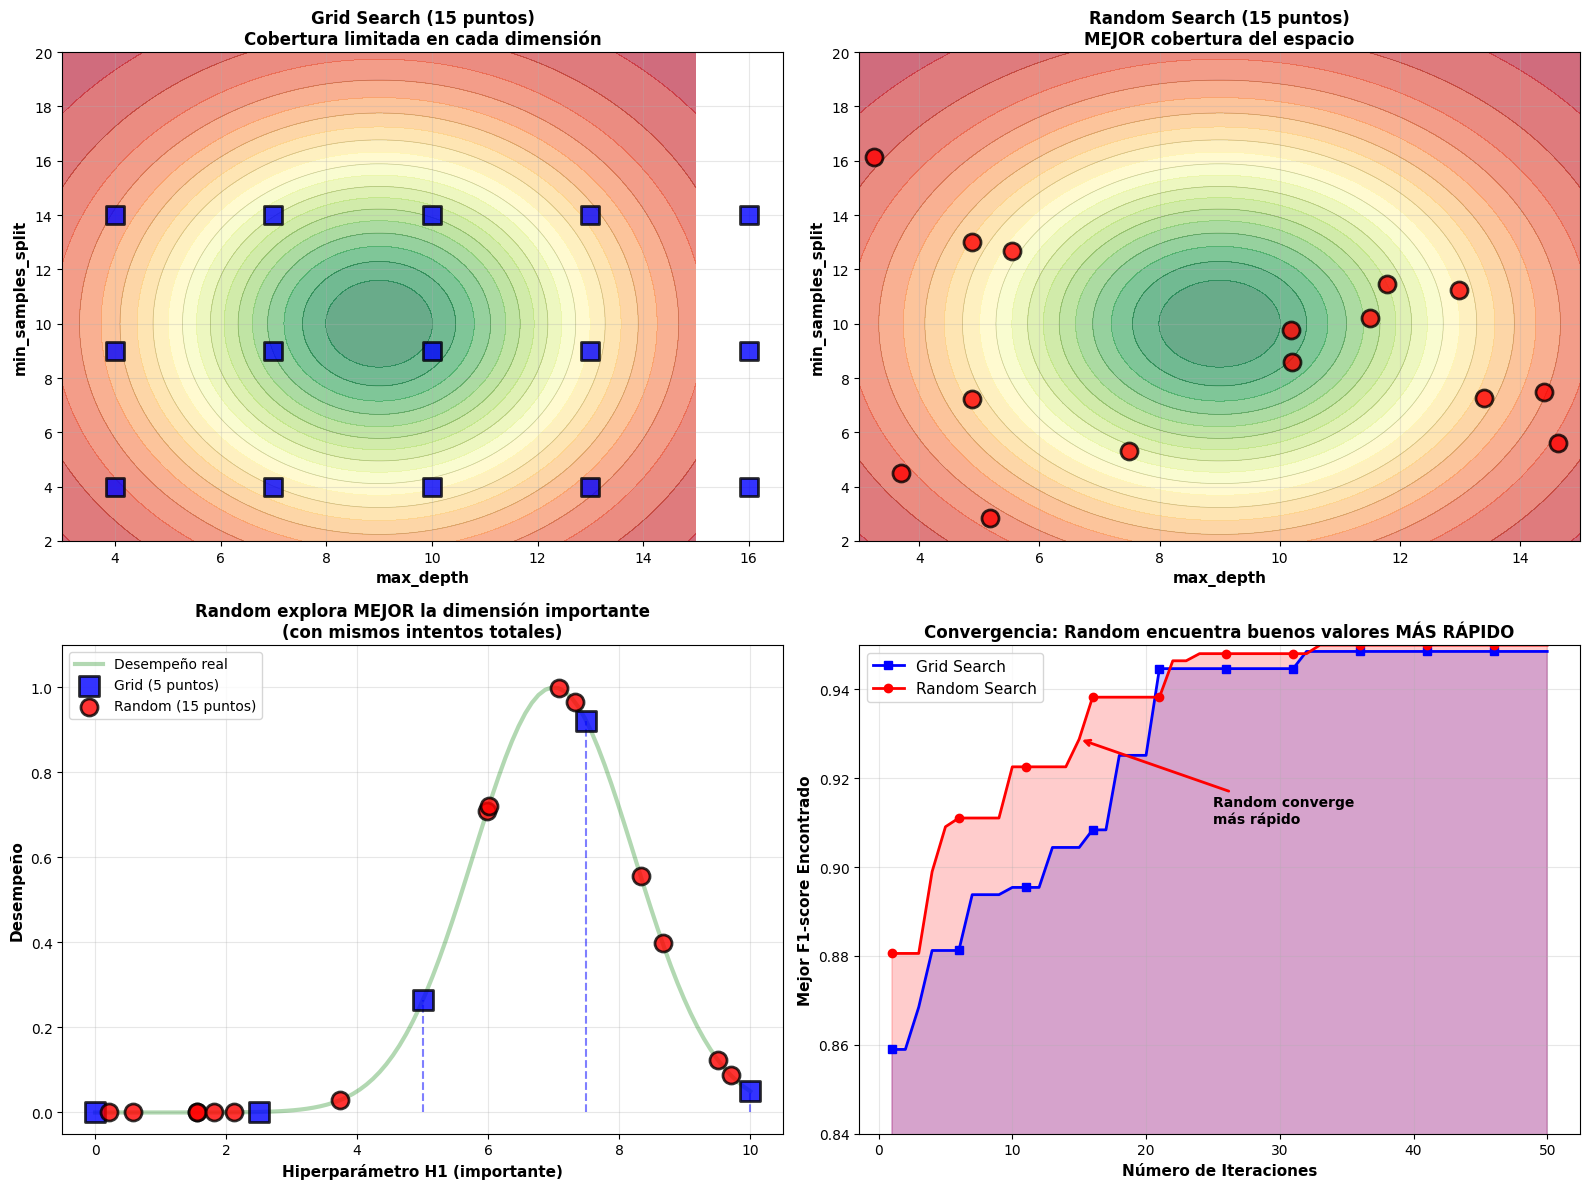


💡 INTERPRETACIÓN DE LOS 4 GRÁFICOS:

1️⃣ Top-Izquierda (Grid Search):
   • Puntos cuadrados azules = búsqueda sistemática
   • Solo 5×3 = 15 combinaciones
   • Cobertura LIMITADA: pocos valores por dimensión
   • Puede perderse regiones buenas entre los puntos

2️⃣ Top-Derecha (Random Search):
   • Puntos circulares rojos = búsqueda aleatoria
   • Mismos 15 puntos pero MEJOR distribuidos
   • Cubre MÁS ÁREA del espacio
   • Mayor probabilidad de encontrar regiones buenas

3️⃣ Bottom-Izquierda (Dimensión Importante):
   • Línea verde = desempeño real (desconocido)
   • Grid solo prueba 5 valores fijos (azul)
   • Random prueba 15 valores distribuidos (rojo)
   • ⭐ Random tiene 3x más chances de estar cerca del óptimo

4️⃣ Bottom-Derecha (Convergencia):
   • Random Search encuentra buenos valores MÁS RÁPIDO
   • Con 15 iteraciones, Random ya está cerca del óptimo
   • Grid necesita más iteraciones para converger
   • → Random es más EFICIENTE

📊 CONCLUSIÓN: Con el MISMO presupuesto de t

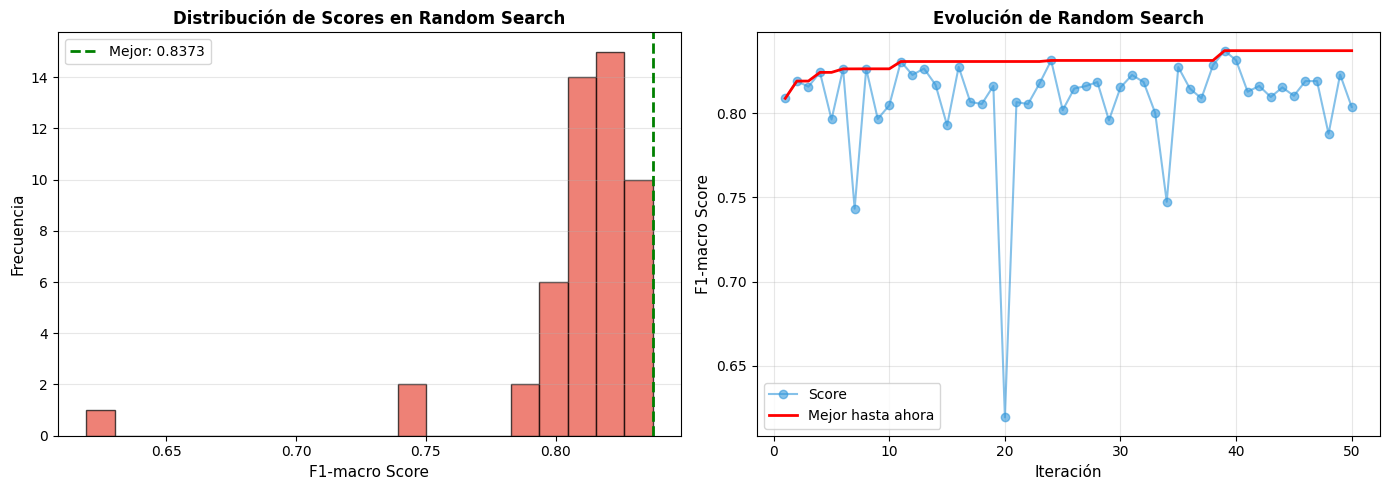

In [42]:
# ============================================================================
# SECCIÓN 7: RANDOM SEARCH - Búsqueda Aleatoria
# ============================================================================
print("\n" + "="*80)
print("SECCIÓN 7: RANDOM SEARCH - Búsqueda Aleatoria")
print("="*80)

print("""
📚 ¿QUÉ ES RANDOM SEARCH?

Random Search muestrea aleatoriamente N combinaciones de hiperparámetros
desde distribuciones definidas (discretas o continuas).

🎯 ANALOGÍA: Buscar un tesoro lanzando dardos al azar

   En lugar de revisar TODA la grilla sistemáticamente,
   lanzas N dardos aleatoriamente:

   max_depth (continuo) →
        ↑
   min_ │     ×        ×
   sam  │  ×      ×       ×
   ples │      ×    ⭐  ×
        │   ×         ×
        │        ×
        └────────────────────→

   • Cada × = una combinación aleatoria probada
   • ⭐ = mejor encontrado
   • Cubre mejor el espacio que Grid Search con menos intentos

🔍 PROCESO:

1. Defines distribuciones (no valores fijos):
   • criterion: ['gini', 'entropy', 'log_loss'] (categórico)
   • max_depth: entero entre 4 y 25 (distribución uniforme)
   • ccp_alpha: float entre 0.0 y 0.01 (continuo)

2. Se muestrean N combinaciones AL AZAR:
   Iteración 1: (entropy, 17, 0.0034)
   Iteración 2: (gini, 8, 0.0001)
   Iteración 3: (log_loss, 23, 0.0089)
   ...

3. Para cada muestra:
   • Entrena con esos hiperparámetros
   • Evalúa con CV
   • Guarda resultado

4. Selecciona la mejor

📊 TEORÍA: ¿Por qué funciona tan bien?

Teorema (Bergstra & Bengio, 2012):
"Random Search es más eficiente que Grid Search cuando algunos
hiperparámetros son más importantes que otros"

Ejemplo visual:

   Grid Search (9 puntos):          Random Search (9 puntos):

   ──┼──┼──┼──  H2 (poco importante) ──×──×────×─  H2
   ──┼──┼──┼──  ↑                    ────────×──×  ↑
   ──┼──┼──┼──  │                    ──×─────────  │
        H1 →                         ×───×──×────  H1 →
   Solo prueba 3                     Prueba 9
   valores de H1                     valores de H1!

   → Random explora MEJOR la dimensión importante

✅ VENTAJAS:
   • MÁS EFICIENTE: Mejor cobertura con menos intentos
   • FLEXIBLE: Soporta distribuciones continuas
   • ESCALABLE: No crece exponencialmente
   • ROBUSTO: Buenos resultados con pocos trials
   • PARALELIZABLE: Fácil de distribuir

⚠️ DESVENTAJAS:
   • NO EXHAUSTIVO: No garantiza encontrar el óptimo
   • ALEATORIO: Resultados pueden variar (usar seed)
   • SIN MEMORIA: No aprende de intentos previos

📌 CUÁNDO USAR:
   • Exploración inicial (antes de Grid Search fino)
   • Muchos hiperparámetros (>4)
   • Espacio de búsqueda grande
   • Tiempo de cómputo limitado
   • Hiperparámetros continuos
   • No necesitas garantía de óptimo global
""")

# Visualización conceptual de Random Search
print("\n🎨 VISUALIZACIÓN: Random Search vs Grid Search")

fig, axes = plt.subplots(2, 2, figsize=(16, 12))

# Mismo paisaje de desempeño para ambos
max_depths_fine = np.linspace(3, 15, 100)
min_samples_fine = np.linspace(2, 20, 100)
X_fine, Y_fine = np.meshgrid(max_depths_fine, min_samples_fine)
Z_fine = np.exp(-((X_fine - 9)**2 / 20 + (Y_fine - 10)**2 / 50))

# Gráfico 1: Grid Search (15 puntos)
ax1 = axes[0, 0]
grid_max_depths = [4, 7, 10, 13, 16]
grid_min_samples = [4, 9, 14]

contour1 = ax1.contourf(X_fine, Y_fine, Z_fine, levels=20, cmap='RdYlGn', alpha=0.6)
ax1.contour(X_fine, Y_fine, Z_fine, levels=10, colors='black', alpha=0.2, linewidths=0.5)

for md in grid_max_depths:
    for ms in grid_min_samples:
        ax1.scatter(md, ms, c='blue', s=150, marker='s',
                   edgecolors='black', linewidths=2, zorder=5, alpha=0.8)

ax1.set_xlabel('max_depth', fontsize=11, fontweight='bold')
ax1.set_ylabel('min_samples_split', fontsize=11, fontweight='bold')
ax1.set_title(f'Grid Search (15 puntos)\nCobertura limitada en cada dimensión',
             fontsize=12, fontweight='bold')
ax1.grid(True, alpha=0.3)

# Gráfico 2: Random Search (15 puntos)
ax2 = axes[0, 1]
np.random.seed(42)
random_max_depths = np.random.uniform(3, 15, 15)
random_min_samples = np.random.uniform(2, 20, 15)

contour2 = ax2.contourf(X_fine, Y_fine, Z_fine, levels=20, cmap='RdYlGn', alpha=0.6)
ax2.contour(X_fine, Y_fine, Z_fine, levels=10, colors='black', alpha=0.2, linewidths=0.5)

ax2.scatter(random_max_depths, random_min_samples, c='red', s=150, marker='o',
           edgecolors='black', linewidths=2, zorder=5, alpha=0.8)

ax2.set_xlabel('max_depth', fontsize=11, fontweight='bold')
ax2.set_ylabel('min_samples_split', fontsize=11, fontweight='bold')
ax2.set_title(f'Random Search (15 puntos)\nMEJOR cobertura del espacio',
             fontsize=12, fontweight='bold')
ax2.grid(True, alpha=0.3)

# Gráfico 3: Comparación de cobertura en 1D (H1 importante)
ax3 = axes[1, 0]

# Simular importancia de hiperparámetro
h1_values = np.linspace(0, 10, 100)
performance_h1 = np.exp(-((h1_values - 7)**2 / 3))  # Pico en 7

ax3.plot(h1_values, performance_h1, 'g-', linewidth=3, alpha=0.3, label='Desempeño real')

# Grid Search: solo 5 valores
grid_h1 = [0, 2.5, 5, 7.5, 10]
grid_perf = [np.exp(-((x - 7)**2 / 3)) for x in grid_h1]
ax3.scatter(grid_h1, grid_perf, c='blue', s=200, marker='s',
           edgecolors='black', linewidths=2, zorder=5, label='Grid (5 puntos)', alpha=0.8)
ax3.vlines(grid_h1, 0, grid_perf, colors='blue', linestyles='--', alpha=0.5)

# Random Search: 15 valores
np.random.seed(42)
random_h1 = np.random.uniform(0, 10, 15)
random_perf = [np.exp(-((x - 7)**2 / 3)) for x in random_h1]
ax3.scatter(random_h1, random_perf, c='red', s=150, marker='o',
           edgecolors='black', linewidths=2, zorder=5, label='Random (15 puntos)', alpha=0.8)

ax3.set_xlabel('Hiperparámetro H1 (importante)', fontsize=11, fontweight='bold')
ax3.set_ylabel('Desempeño', fontsize=11, fontweight='bold')
ax3.set_title('Random explora MEJOR la dimensión importante\n(con mismos intentos totales)',
             fontsize=12, fontweight='bold')
ax3.legend(fontsize=10)
ax3.grid(True, alpha=0.3)
ax3.set_ylim([-0.05, 1.1])

# Gráfico 4: Convergencia
ax4 = axes[1, 1]

# Simular convergencia
n_trials = 50
np.random.seed(42)

# Grid Search simulado (espaciado uniforme pero ineficiente)
grid_scores = []
grid_best = []
for i in range(1, n_trials+1):
    # Simular que Grid explora mal al principio
    score = 0.85 + 0.08 * min(i/20, 1) + np.random.normal(0, 0.01)
    grid_scores.append(score)
    grid_best.append(max(grid_scores))

# Random Search simulado (explora mejor)
random_scores = []
random_best = []
for i in range(1, n_trials+1):
    # Simular que Random encuentra buenos valores más rápido
    score = 0.87 + 0.06 * (1 - np.exp(-i/10)) + np.random.normal(0, 0.015)
    random_scores.append(score)
    random_best.append(max(random_scores))

ax4.plot(range(1, n_trials+1), grid_best, 'b-', linewidth=2, label='Grid Search', marker='s', markevery=5)
ax4.plot(range(1, n_trials+1), random_best, 'r-', linewidth=2, label='Random Search', marker='o', markevery=5)
ax4.fill_between(range(1, n_trials+1), grid_best, alpha=0.2, color='blue')
ax4.fill_between(range(1, n_trials+1), random_best, alpha=0.2, color='red')

ax4.set_xlabel('Número de Iteraciones', fontsize=11, fontweight='bold')
ax4.set_ylabel('Mejor F1-score Encontrado', fontsize=11, fontweight='bold')
ax4.set_title('Convergencia: Random encuentra buenos valores MÁS RÁPIDO',
             fontsize=12, fontweight='bold')
ax4.legend(fontsize=11)
ax4.grid(True, alpha=0.3)
ax4.set_ylim([0.84, 0.95])

# Añadir anotación
ax4.annotate('Random converge\nmás rápido', xy=(15, random_best[14]),
            xytext=(25, 0.91), fontsize=10, fontweight='bold',
            arrowprops=dict(arrowstyle='->', color='red', lw=2))

plt.tight_layout()
plt.show()

print("""
💡 INTERPRETACIÓN DE LOS 4 GRÁFICOS:

1️⃣ Top-Izquierda (Grid Search):
   • Puntos cuadrados azules = búsqueda sistemática
   • Solo 5×3 = 15 combinaciones
   • Cobertura LIMITADA: pocos valores por dimensión
   • Puede perderse regiones buenas entre los puntos

2️⃣ Top-Derecha (Random Search):
   • Puntos circulares rojos = búsqueda aleatoria
   • Mismos 15 puntos pero MEJOR distribuidos
   • Cubre MÁS ÁREA del espacio
   • Mayor probabilidad de encontrar regiones buenas

3️⃣ Bottom-Izquierda (Dimensión Importante):
   • Línea verde = desempeño real (desconocido)
   • Grid solo prueba 5 valores fijos (azul)
   • Random prueba 15 valores distribuidos (rojo)
   • ⭐ Random tiene 3x más chances de estar cerca del óptimo

4️⃣ Bottom-Derecha (Convergencia):
   • Random Search encuentra buenos valores MÁS RÁPIDO
   • Con 15 iteraciones, Random ya está cerca del óptimo
   • Grid necesita más iteraciones para converger
   • → Random es más EFICIENTE

📊 CONCLUSIÓN: Con el MISMO presupuesto de tiempo,
   Random Search explora mejor y converge más rápido
""")

# Implementación práctica
param_distributions = {
    "criterion": ["gini", "entropy", "log_loss"],
    "max_depth": randint(4, 25),  # Enteros entre 4 y 24
    "min_samples_split": randint(2, 20),
    "min_samples_leaf": randint(1, 10),
    "ccp_alpha": uniform(0.0, 0.01)  # Continuo entre 0.0 y 0.01
}

n_iter = 50
print(f"\n⚙️  CONFIGURACIÓN PARA NUESTRO PROBLEMA:")
print(f"   • Parámetros: {len(param_distributions)}")
print(f"   • criterion: categorico {param_distributions['criterion']}")
print(f"   • max_depth: entero en [4, 25)")
print(f"   • min_samples_split: entero en [2, 20)")
print(f"   • min_samples_leaf: entero en [1, 10)")
print(f"   • ccp_alpha: continuo en [0.0, 0.01]")
print(f"   • Iteraciones: {n_iter} (muestreo aleatorio)")
print(f"   • Con CV=5: {n_iter * 5} entrenamientos")
print(f"   • Tiempo estimado: ~{n_iter * 5 * 2 / 60:.1f} minutos")

print("\n⏳ Ejecutando Random Search...")
random_search = RandomizedSearchCV(
    DecisionTreeClassifier(random_state=42),
    param_distributions=param_distributions,
    n_iter=n_iter,
    scoring="f1_macro",
    cv=cv,
    random_state=42,
    n_jobs=-1,
    verbose=0
)
random_search.fit(X_train, y_train)

print(f"\n✅ Búsqueda completada!")
print(f"\n🏆 MEJORES HIPERPARÁMETROS:")
for param, value in random_search.best_params_.items():
    print(f"   • {param}: {value}")

print(f"\n📊 RESULTADOS:")
print(f"   • Mejor F1-macro en CV: {random_search.best_score_:.4f}")

y_pred_random = random_search.best_estimator_.predict(X_test)
test_f1_random = f1_score(y_test, y_pred_random, average="macro")
print(f"   • F1-macro en TEST: {test_f1_random:.4f}")

# Visualizar distribución de resultados
print("\n📈 Análisis de resultados de Random Search:")

results_random = pd.DataFrame(random_search.cv_results_)
scores = results_random['mean_test_score']

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Histograma de scores
ax1 = axes[0]
ax1.hist(scores, bins=20, edgecolor='black', alpha=0.7, color='#E74C3C')
ax1.axvline(random_search.best_score_, color='green', linestyle='--', linewidth=2,
           label=f'Mejor: {random_search.best_score_:.4f}')
ax1.set_xlabel('F1-macro Score', fontsize=11)
ax1.set_ylabel('Frecuencia', fontsize=11)
ax1.set_title('Distribución de Scores en Random Search', fontsize=12, fontweight='bold')
ax1.legend(fontsize=10)
ax1.grid(alpha=0.3, axis='y')

# Evolución temporal
ax2 = axes[1]
ax2.plot(range(1, len(scores)+1), scores, 'o-', alpha=0.6, color='#3498DB', label='Score')
best_so_far = [max(scores[:i+1]) for i in range(len(scores))]
ax2.plot(range(1, len(scores)+1), best_so_far, 'r-', linewidth=2, label='Mejor hasta ahora')
ax2.set_xlabel('Iteración', fontsize=11)
ax2.set_ylabel('F1-macro Score', fontsize=11)
ax2.set_title('Evolución de Random Search', fontsize=12, fontweight='bold')
ax2.legend(fontsize=10)
ax2.grid(alpha=0.3)

plt.tight_layout()
plt.show()

In [43]:
# ============================================================================
# SECCIÓN 10: DIAGNÓSTICO Y AJUSTE DE HIPERPARÁMETROS
# ============================================================================
print("\n" + "="*80)
print("SECCIÓN 10: DIAGNÓSTICO Y AJUSTE DE HIPERPARÁMETROS")
print("="*80)

print("""
📚 TABLA DE SÍNTOMAS Y SOLUCIONES

┌──────────────────────────┬──────────────────────┬─────────────────────────┐
│ SÍNTOMA                  │ QUÉ HACER            │ POR QUÉ                 │
├──────────────────────────┼──────────────────────┼─────────────────────────┤
│ Train alto, Test bajo    │ ↓ max_depth          │ Reduce complejidad      │
│ (SOBREAJUSTE)            │ ↑ min_samples_leaf   │ Suaviza predicciones    │
│                          │ ↑ ccp_alpha          │ Poda automática         │
├──────────────────────────┼──────────────────────┼─────────────────────────┤
│ Train y Test bajos       │ ↑ max_depth          │ Aumenta capacidad       │
│ (SUBAJUSTE)              │ ↑ max_leaf_nodes     │ Más reglas              │
│                          │ Probar otro criterion│ Mejor medida            │
├──────────────────────────┼──────────────────────┼─────────────────────────┤
│ Probabilidades extremas  │ ↑ min_samples_leaf   │ Evita hojas con 1       │
│ (100% o 0%)              │ ↑ ccp_alpha          │ ejemplo                 │
├──────────────────────────┼──────────────────────┼─────────────────────────┤
│ Mismas features          │ ↓ max_features       │ Fuerza diversidad       │
│ se repiten               │ (ej: 'sqrt')         │                         │
├──────────────────────────┼──────────────────────┼─────────────────────────┤
│ Outliers en regresión    │ criterion='absolute_ │ Menos sensible a        │
│                          │ error' (MAE)         │ valores extremos        │
└──────────────────────────┴──────────────────────┴─────────────────────────┘
""")

# Demostración: Detectar sobreajuste
print("\n🔬 DEMOSTRACIÓN: Detectando Sobreajuste/Subajuste\n")

scenarios = [
    ("SUBAJUSTE (depth=2)", {"max_depth": 2}),
    ("BALANCEADO (depth=10)", {"max_depth": 10}),
    ("SOBREAJUSTE (depth=None)", {"max_depth": None})
]

print("   Comparación de escenarios:\n")
for name, params in scenarios:
    clf_test = DecisionTreeClassifier(**params, random_state=42)
    clf_test.fit(X_train, y_train)

    train_acc = accuracy_score(y_train, clf_test.predict(X_train))
    test_acc = accuracy_score(y_test, clf_test.predict(X_test))
    gap = train_acc - test_acc

    status = "✓" if gap < 0.05 else "⚠️" if gap < 0.15 else "❌"

    print(f"   {status} {name:25} → Train: {train_acc:.3f} | Test: {test_acc:.3f} | Gap: {gap:.3f}")



SECCIÓN 10: DIAGNÓSTICO Y AJUSTE DE HIPERPARÁMETROS

📚 TABLA DE SÍNTOMAS Y SOLUCIONES

┌──────────────────────────┬──────────────────────┬─────────────────────────┐
│ SÍNTOMA                  │ QUÉ HACER            │ POR QUÉ                 │
├──────────────────────────┼──────────────────────┼─────────────────────────┤
│ Train alto, Test bajo    │ ↓ max_depth          │ Reduce complejidad      │
│ (SOBREAJUSTE)            │ ↑ min_samples_leaf   │ Suaviza predicciones    │
│                          │ ↑ ccp_alpha          │ Poda automática         │
├──────────────────────────┼──────────────────────┼─────────────────────────┤
│ Train y Test bajos       │ ↑ max_depth          │ Aumenta capacidad       │
│ (SUBAJUSTE)              │ ↑ max_leaf_nodes     │ Más reglas              │
│                          │ Probar otro criterion│ Mejor medida            │
├──────────────────────────┼──────────────────────┼─────────────────────────┤
│ Probabilidades extremas  │ ↑ min_samples_leaf   │ Ev

# Reto:  desarrollar el modelo de regresion utilizando validacioncruzada y optmizacion de hiperparametros y comparalo con el modelo base

In [ ]:
# ============================================================================
# SECCIÓN 12: RESUMEN Y MEJORES PRÁCTICAS
# ============================================================================
print("\n" + "="*80)
print("RESUMEN Y MEJORES PRÁCTICAS")
print("="*80)

print("""
🎓 LECCIONES APRENDIDAS

1️⃣ FUNDAMENTOS
   • Árboles dividen el espacio con preguntas (if-then)
   • Impureza mide qué tan "mezclado" está un nodo
   • Clasificación: Gini, Entropía
   • Regresión: MSE, MAE

2️⃣ HIPERPARÁMETROS CLAVE
   • max_depth: Controla complejidad (muy importante)
   • min_samples_leaf: Suaviza predicciones
   • ccp_alpha: Poda automática
   • criterion: Tipo de impureza (menos crítico)

3️⃣ VALIDACIÓN
   • Siempre usa Cross-Validation
   • StratifiedKFold para clasificación
   • KFold para regresión
   • K=5 o K=10 son buenos defaults

4️⃣ OPTIMIZACIÓN
   ┌─────────────────┬──────────────┬──────────────────┐
   │ Método          │ Cuándo usar  │ Ventaja          │
   ├─────────────────┼──────────────┼──────────────────┤
   │ Grid Search     │ Pocos params │ Exhaustivo       │
   │ Random Search   │ Exploración  │ Rápido y bueno   │
   │ Bayesiana       │ Costoso      │ Más eficiente    │
   └─────────────────┴──────────────┴──────────────────┘

5️⃣ DIAGNÓSTICO
   • Train >> Test → Sobreajuste → Regularizar
   • Train ≈ Test bajo → Subajuste → Más capacidad
   • Gap < 0.05 → Buen balance

📚 CHECKLIST PARA TU PROYECTO:

□ Entender el problema (clasificación/regresión)
□ Hacer EDA (exploración de datos)
□ Split estratificado
□ Modelo base simple (baseline)
□ Cross-validation para evaluar
□ Optimizar hiperparámetros (Random → Bayesiana)
□ Evaluar en test set (una sola vez al final)
□ Interpretar resultados (matriz confusión, importancia)
□ Documentar decisiones

🚀 SIGUIENTES PASOS:

1. Practica con diferentes datasets (Kaggle, UCI)
2. Prueba Random Forests (ensemble de árboles)
3. Explora XGBoost/LightGBM (árboles boosted)
4. Aprende SHAP para interpretar modelos
5. Lee sobre feature importance

📖 RECURSOS RECOMENDADOS:

• Scikit-learn: https://scikit-learn.org/stable/modules/tree.html
• Optuna: https://optuna.org/
• ISLR (libro): Capítulo 8 - Tree-Based Methods
• StatQuest (YouTube): Decision Trees explicados visualmente
""")

print("\n" + "="*80)
print("✅ ¡TALLER COMPLETADO!")
print("="*80)
print("""
🎉 Felicitaciones por completar el taller de Árboles de Decisión

Has aprendido:
✓ Fundamentos matemáticos (Gini, Entropía, MSE)
✓ Clasificación y Regresión con árboles
✓ Efecto de hiperparámetros
✓ Validación cruzada
✓ Tres métodos de optimización (Grid, Random, Bayesiana)
✓ Diagnóstico y solución de problemas
✓ Mejores prácticas

💪 Ahora estás listo para:
• Aplicar árboles a tus propios problemas
• Optimizar modelos de manera sistemática
• Diagnosticar y corregir sobreajuste/subajuste
• Comparar diferentes estrategias de búsqueda

¡Éxito en tus proyectos de Machine Learning! 🚀
""")


RESUMEN Y MEJORES PRÁCTICAS

🎓 LECCIONES APRENDIDAS

1️⃣ FUNDAMENTOS
   • Árboles dividen el espacio con preguntas (if-then)
   • Impureza mide qué tan "mezclado" está un nodo
   • Clasificación: Gini, Entropía
   • Regresión: MSE, MAE

2️⃣ HIPERPARÁMETROS CLAVE
   • max_depth: Controla complejidad (muy importante)
   • min_samples_leaf: Suaviza predicciones
   • ccp_alpha: Poda automática
   • criterion: Tipo de impureza (menos crítico)

3️⃣ VALIDACIÓN
   • Siempre usa Cross-Validation
   • StratifiedKFold para clasificación
   • KFold para regresión
   • K=5 o K=10 son buenos defaults

4️⃣ OPTIMIZACIÓN
   ┌─────────────────┬──────────────┬──────────────────┐
   │ Método          │ Cuándo usar  │ Ventaja          │
   ├─────────────────┼──────────────┼──────────────────┤
   │ Grid Search     │ Pocos params │ Exhaustivo       │
   │ Random Search   │ Exploración  │ Rápido y bueno   │
   │ Bayesiana       │ Costoso      │ Más eficiente    │
   └─────────────────┴──────────────┴────────

# ejercicio practico

In [ ]:
# ============================================================================
# SECCIÓN 11: EJERCICIO PRÁCTICO GUIADO - Dataset WINE
# ============================================================================
# 🎯 OBJETIVO: Optimiza un clasificador para el dataset Wine
# 📋 INSTRUCCIONES: Completa los espacios marcados con "TODO" y "OPCIONAL"
# ⚠️ NO ejecutes todo de una vez - lee, entiende y completa sección por sección
# ============================================================================

print("\n\n" + "="*80)
print("SECCIÓN 11: EJERCICIO PRÁCTICO - Dataset WINE")
print("="*80)
print("""
🎯 TU TURNO: Optimiza un clasificador para el dataset Wine

TAREA:
1. ✓ Cargar dataset load_wine()
2. ✓ Dividir en train/test (75/25)
3. ✓ Entrenar modelo base
4. ✓ Aplicar métodos de optimización
5. ✓ Comparar resultados

OBJETIVO: Superar 0.92 de F1-macro en test
""")

# ============================================================================
# PARTE 1: CARGA Y EXPLORACIÓN DE DATOS
# ============================================================================
print("\n" + "="*80)
print("PARTE 1: CARGA Y EXPLORACIÓN DE DATOS")
print("="*80)

"""
TODO 1.1: Importa las librerías necesarias
Necesitarás:
- from sklearn.datasets import load_wine
- from sklearn.model_selection import train_test_split, StratifiedKFold, RandomizedSearchCV
- from sklearn.tree import DecisionTreeClassifier
- from sklearn.metrics import f1_score, ConfusionMatrixDisplay
- import numpy as np
- import matplotlib.pyplot as plt
- from scipy.stats import randint, uniform

OPCIONAL: También puedes importar seaborn para visualizaciones más bonitas
"""
# AQUÍ VA TU CÓDIGO:
# from sklearn.datasets import load_wine
# ... (completa las demás importaciones)


# TODO 1.2: Carga el dataset Wine
"""
Pista: Usa load_wine() y extrae X y y
Guarda en:
  - wine: el objeto del dataset
  - X_wine: los datos (features)
  - y_wine: las etiquetas (target)
"""
# AQUÍ VA TU CÓDIGO:
# wine = ???
# X_wine, y_wine = ???, ???


# TODO 1.3: Explora el dataset
"""
Imprime:
1. Número de muestras: X_wine.shape[0]
2. Número de características: X_wine.shape[1]
3. Número de clases: len(np.unique(y_wine))
4. Nombres de características: wine.feature_names

Opcional: Imprime también el nombre del target: wine.target_names
"""
print(f"\n📊 Dataset WINE:")
# AQUÍ VA TU CÓDIGO:
# print(f"   • {???} muestras de vino")
# print(f"   • {???} características químicas")
# print(f"   • {???} clases (cultivares)")




In [ ]:
# ============================================================================
# PARTE 2: DIVISIÓN TRAIN/TEST
# ============================================================================
print("\n" + "="*80)
print("PARTE 2: DIVISIÓN TRAIN/TEST")
print("="*80)

"""
TODO 2.1: Divide los datos en train/test con ratio 75/25
Parámetros recomendados:
- test_size=0.25
- random_state=42 (para reproducibilidad)
- stratify=y_wine (para mantener proporciones de clases)

Guarda en:
- X_wine_train, X_wine_test
- y_wine_train, y_wine_test
"""
# AQUÍ VA TU CÓDIGO:
# X_wine_train, X_wine_test, y_wine_train, y_wine_test = train_test_split(
#     ???, ???, test_size=???, random_state=???, stratify=???
# )

print(f"\n🔀 División: ??? train / ??? test")
# AQUÍ: Reemplaza ??? con X_wine_train.shape[0] y X_wine_test.shape[0]




In [ ]:
# ============================================================================
# PARTE 3: MODELO BASE (SIN OPTIMIZAR)
# ============================================================================
print("\n" + "="*80)
print("PARTE 3: MODELO BASE (SIN OPTIMIZAR)")
print("="*80)

"""
TODO 3.1: Crea y entrena un modelo DecisionTreeClassifier básico
Hiperparámetros:
- max_depth=5 (árbol poco profundo para evitar overfitting)
- random_state=42

Pasos:
1. Instancia el modelo
2. Entrenalo con X_wine_train y y_wine_train
3. Haz predicciones en el test
4. Calcula F1-macro
"""
print("\n🌳 Modelo Base (sin optimizar)...")
# AQUÍ VA TU CÓDIGO:
# clf_wine_base = DecisionTreeClassifier(???, ???)
# clf_wine_base.fit(???, ???)
# y_wine_pred_base = clf_wine_base.predict(???)
# f1_wine_base = f1_score(???, ???, average='macro')

print(f"   📊 F1-macro: ???")  # Reemplaza ??? con f1_wine_base




In [ ]:
# ============================================================================
# PARTE 4: OPTIMIZACIÓN CON RANDOM SEARCH
# ============================================================================
print("\n" + "="*80)
print("PARTE 4: OPTIMIZACIÓN CON RANDOM SEARCH")
print("="*80)

"""
TODO 4.1: Define el diccionario de hiperparámetros a explorar
Opciones sugeridas:
- criterion: ["gini", "entropy"]
- max_depth: randint(3, 15)  # Profundidad del árbol: 3 a 14
- min_samples_split: randint(2, 10)  # Muestras mínimas para split: 2 a 9
- min_samples_leaf: randint(1, 5)  # Muestras mínimas en hoja: 1 a 4
- max_features: ["sqrt", "log2", None]
- ccp_alpha: uniform(0.0, 0.01)  # Regularización: 0.0 a 0.01

OPCIONAL: Puedes agregar más parámetros como:
- splitter: ["best", "random"]
- class_weight: [None, "balanced"]
"""
print("\n💡 Definiendo espacio de hiperparámetros...\n")

# AQUÍ VA TU CÓDIGO:
# param_dist_wine = {
#     "criterion": ???,
#     "max_depth": ???,
#     "min_samples_split": ???,
#     "min_samples_leaf": ???,
#     "max_features": ???,
#     "ccp_alpha": ???
# }


# TODO 4.2: Define la estrategia de validación cruzada
"""
Usa StratifiedKFold con:
- n_splits=5 (5 folds)
- shuffle=True (mezcla antes de dividir)
- random_state=42 (reproducibilidad)
"""
# AQUÍ VA TU CÓDIGO:
# cv_wine = StratifiedKFold(???, ???, ???)


# TODO 4.3: Ejecuta RandomizedSearchCV
"""
Parámetros principales:
- estimator: DecisionTreeClassifier(random_state=42)
- param_distributions: param_dist_wine
- n_iter=100 (número de combinaciones a probar)
- scoring='f1_macro' (métrica a optimizar)
- cv: cv_wine (estrategia de validación)
- random_state=42
- n_jobs=-1 (usar todos los cores)
- verbose=0 (sin salida intermedia)

Guarda en: random_wine
"""
print("⏳ Ejecutando Random Search para Wine...")
# AQUÍ VA TU CÓDIGO:
# random_wine = RandomizedSearchCV(
#     DecisionTreeClassifier(???),
#     param_distributions=???,
#     n_iter=???,
#     scoring=???,
#     cv=???,
#     random_state=???,
#     n_jobs=???,
#     verbose=???
# )
# random_wine.fit(???, ???)

print(f"\n✅ Optimización completada!")




In [ ]:
# ============================================================================
# PARTE 5: ANÁLISIS DE RESULTADOS
# ============================================================================
print("\n" + "="*80)
print("PARTE 5: ANÁLISIS DE RESULTADOS")
print("="*80)

"""
TODO 5.1: Imprime los mejores hiperparámetros encontrados
Accede a ellos con: random_wine.best_params_

Itera sobre los parámetros e imprime cada uno
Formato sugerido:
   • nombre_param: valor
"""
print(f"\n🏆 Mejores hiperparámetros:")
# AQUÍ VA TU CÓDIGO:
# for param, value in ???.items():
#     print(f"   • {param}: {value}")


# TODO 5.2: Evalúa el modelo optimizado en test
"""
Pasos:
1. Haz predicciones en X_wine_test usando random_wine.best_estimator_
2. Calcula F1-macro
3. Guarda en y_wine_pred_opt y f1_wine_opt
"""
# AQUÍ VA TU CÓDIGO:
# y_wine_pred_opt = ???.predict(???)
# f1_wine_opt = f1_score(???, ???, average='macro')


# TODO 5.3: Compara resultados
"""
Imprime:
1. F1-macro en CV (entrenamiento): random_wine.best_score_
2. F1-macro en TEST (prueba): f1_wine_opt
3. Mejora absoluta: f1_wine_opt - f1_wine_base
4. Mejora relativa en %: ((f1_wine_opt/f1_wine_base - 1)*100)

OPCIONAL: Agrega un condicional que imprima un mensaje especial si f1_wine_opt > 0.92
"""
print(f"\n📊 RESULTADOS:")
# AQUÍ VA TU CÓDIGO:
# print(f"   • F1-macro CV: {???:.4f}")
# print(f"   • F1-macro TEST: {???:.4f}")
# print(f"   • Modelo Base TEST: {???:.4f}")
# print(f"   • Mejora: {???:.4f} ({???:.1f}%)")




In [ ]:
# ============================================================================
# PARTE 6: VISUALIZACIÓN (OPCIONAL PERO RECOMENDADO)
# ============================================================================
print("\n" + "="*80)
print("PARTE 6: VISUALIZACIÓN")
print("="*80)

"""
TODO 6.1 (OPCIONAL): Crea una comparación visual con matrices de confusión
Pasos:
1. Crea una figura con 2 subplots (1 fila, 2 columnas)
2. En el primero: Matriz de confusión del modelo base
3. En el segundo: Matriz de confusión del modelo optimizado
4. Añade títulos con los F1-scores
5. Usa colormaps diferentes (ej: 'Blues' y 'Greens')

Código sugerido:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
ConfusionMatrixDisplay.from_predictions(y_real, y_pred, ax=axes[0], cmap='Blues')
axes[0].set_title(f'Modelo Base\\nF1={f1:.3f}', fontsize=12, fontweight='bold')
# ... similar para el segundo
"""
# AQUÍ VA TU CÓDIGO (OPCIONAL):
# fig, axes = plt.subplots(???, ???, figsize=(???, ???))
# ConfusionMatrixDisplay.from_predictions(
#     ???, ???, ax=axes[0], cmap='Blues'
# )
# axes[0].set_title(f'Modelo Base\nF1={???:.3f}', fontsize=12, fontweight='bold')
#
# ConfusionMatrixDisplay.from_predictions(
#     ???, ???, ax=axes[1], cmap='Greens'
# )
# axes[1].set_title(f'Modelo Optimizado\nF1={???:.3f}', fontsize=12, fontweight='bold')
# plt.suptitle('Comparación: Wine Dataset', fontsize=14, fontweight='bold')
# plt.tight_layout()
# plt.show()




In [ ]:
# ============================================================================
# PARTE 7: EXPLORACIÓN ADICIONAL (DESAFÍO EXTRA)
# ============================================================================
print("\n" + "="*80)
print("PARTE 7: DESAFÍOS ADICIONALES")
print("="*80)

print("""
🚀 DESAFÍOS OPCIONALES (después de completar todo lo anterior):

1. 📊 ANALIZA LOS TOP 5 MEJORES PARÁMETROS:
   - Accede a random_wine.cv_results_
   - Encuentra los 5 mejores modelos según mean_test_score
   - Imprime sus parámetros y scores

2. 🔄 PRUEBA OTROS MÉTODOS DE OPTIMIZACIÓN:
   - GridSearchCV en lugar de RandomizedSearchCV (más exhaustivo pero lento)
   - Optuna para optimización más avanzada
   - HalvingRandomSearchCV para exploración inteligente

3. 📈 EXPERIMENTA CON OTROS MODELOS:
   - RandomForestClassifier
   - GradientBoostingClassifier
   - SVM o LogisticRegression

4. 📉 VISUALIZA LA CURVA DE APRENDIZAJE:
   - Usa learning_curve() para ver cómo mejora con más datos
   - Identifica si el modelo sufre de bias o variance

5. 🎯 BUSCA EL MEJOR THRESHOLD:
   - Prueba diferentes umbrales de probabilidad
   - Visualiza curva ROC y PR-curve

Ejemplo de código para desafío 1:
cv_results = pd.DataFrame(random_wine.cv_results_)
top_5 = cv_results.nlargest(5, 'mean_test_score')
print(top_5[['param_max_depth', 'param_criterion', 'mean_test_score']])
""")


# ============================================================================
# RECORDATORIOS IMPORTANTES
# ============================================================================
print("\n" + "="*80)
print("⚠️ RECORDATORIOS IMPORTANTES")
print("="*80)
print("""
✓ Completa TODO en orden
✓ Lee los comentarios antes de codificar
✓ Usa las pistas proporcionadas
✓ Prueba tu código sección por sección
✓ Si algo no funciona, lee el error cuidadosamente
✓ Experimenta con los parámetros opcionales
✓ Documenta tus descubrimientos

¿Preguntas? Revisa la documentación oficial:
- sklearn.org/modules/model_selection.html
- sklearn.org/modules/generated/sklearn.tree.DecisionTreeClassifier.html
""")